# Fetch data

## AnonDB Zubair

In [2]:
import pandas as pd
meta = pd.read_csv('AnonDB_with_Rs_I0_Rsh.csv', sep=';')
df_pixel_stats = pd.read_csv('pixel_stats.csv', sep=',')
meta_zub = pd.read_csv('AnonDB_zub.csv', sep=';')




In [3]:
meta.head()

,Unnamed: 0,Mod_ID,Confidential,Make,Model,Interconnect_Tech,Module_Area_(cm2),Junction_Box_Type,Cell_Wafer_Type,Cell_Tech,...,Ref_IV_Time,IL_fit,I0,Rs,Rsh,nNsVth_fit,V_column_used,I_column_used,fit_status,fit_error
0,0,3903,NaN,35,1,NaN,16222.6,NaN,mono-Si module,NaN,...,10:45:34,8.888586,2.800000e-10,0.318379,201.683997,1.589408,V,I,ok,NaN
1,1,3887,NaN,35,1,NaN,16222.6,NaN,mono-Si module,NaN,...,08:25:17,8.840692,7.780000e-10,0.307588,371.194847,1.654887,V,I,ok,NaN
2,2,3887,NaN,35,1,NaN,16222.6,NaN,mono-Si module,NaN,...,08:25:17,8.840173,5.180000e-10,0.334627,249.445806,1.628107,V,I,ok,NaN
3,3,3899,NaN,35,1,NaN,16222.6,NaN,mono-Si module,NaN,...,10:22:46,8.837768,5.430000e-10,0.310366,535.201004,1.631432,V,I,ok,NaN
4,4,3899,NaN,35,1,NaN,16222.6,NaN,mono-Si module,NaN,...,10:22:46,8.821158,8.960000e-10,0.333767,649.152218,1.666430,V,I,ok,NaN


In [7]:
df_pixel_stats.head()

,nama_gambar,mean,median,modus
0,10084_35_1_01272020_20_wrp.tiff,89.951571,95.0,102
1,10084_35_1_01272020_80_wrp.tiff,67.735187,70.0,70
2,10084_35_1_02222021_20_wrp.tiff,88.351796,105.0,5
3,10084_35_1_02222021_80_wrp.tiff,72.874862,85.0,6
4,10085_35_1_01272020_20_wrp.tiff,82.821786,86.0,77


In [9]:
df = df_pixel_stats.copy()

df["base_id"] = (
    df["nama_gambar"]
    .str.replace("_80_wrp.tiff", "", regex=False)
    .str.replace("_20_wrp.tiff", "", regex=False)
)


In [10]:
df_80 = df[df["nama_gambar"].str.contains("_80_wrp.tiff")].copy()
df_20 = df[df["nama_gambar"].str.contains("_20_wrp.tiff")].copy()


In [11]:
df_80 = df_80.rename(columns={
    "mean": "mean_80",
    "median": "median_80",
    "modus": "modus_80"
})

df_20 = df_20.rename(columns={
    "mean": "mean_20",
    "median": "median_20",
    "modus": "modus_20"
})


In [12]:
df_final = pd.merge(
    df_80[["base_id", "mean_80", "median_80", "modus_80"]],
    df_20[["base_id", "mean_20", "median_20", "modus_20"]],
    on="base_id",
    how="inner"
)


In [13]:
df_final.head()

,base_id,mean_80,median_80,modus_80,mean_20,median_20,modus_20
0,10084_35_1_01272020,67.735187,70.0,70,89.951571,95.0,102
1,10084_35_1_02222021,72.874862,85.0,6,88.351796,105.0,5
2,10085_35_1_01272020,64.001961,65.0,63,82.821786,86.0,77
3,10085_35_1_02222021,70.857794,82.0,6,86.758040,100.0,5
4,10105_24_3_03012021,91.260262,101.0,104,103.576085,116.0,8


In [14]:
# --- Calculate Performance Ratio (PR) ---
meta['PR'] = meta['Pmp_(W)'] / meta['Nameplate_Pmp_(W)'] * 100

In [15]:
meta2 = meta.copy()

meta2["base_id"] = (
    meta2["ELHPath"]
        .str.split("/")            # pisah folder
        .str[-1]                   # ambil nama file
        .str.replace(".tiff", "", regex=False)
        .str.replace("_80", "", regex=False)
        .str.replace("_20", "", regex=False)
)

# --- Calculate Performance Ratio (PR) ---
meta2['PR'] = meta2['Pmp_(W)'] / meta2['Nameplate_Pmp_(W)'] * 100

# -- Merge Meta2 with the pixel stats ---
meta_merged = meta2.merge(
    df_final,
    on="base_id",
    how="left"
)

df_final = meta_merged.merge(
    meta_zub[["Num_Cells", "ELHPath"]],
    on="ELHPath",
    how="left"
)

df_final['Total_Exposure_days'] = (
    df_final['Total_Exposure']
    .str.extract(r'(\d+)')   # ambil angka
    .astype(int)             # convert ke integer
)

df_final["Make_Model"] = (
    df_final["Make"].astype(str) + "_" + df_final["Model"].astype(str)
)


In [33]:
df_final['Total_Exposure_days'].head()

0     640
1     640
2    1024
3     640
4    1024
Name: Total_Exposure_days, dtype: int32

In [34]:
cols = [
    "PR",
    "mean_80", "median_80", "modus_80",
    "mean_20", "median_20", "modus_20"
]

correlation_matrix = meta_merged[cols].corr()

print(correlation_matrix["PR"].sort_values(ascending=False))


PR           1.000000
median_80    0.309684
mean_80      0.302513
modus_80     0.250620
modus_20     0.234074
median_20    0.062047
mean_20      0.049778
Name: PR, dtype: float64


In [35]:
pd.set_option('display.max_columns', None)

print(df_final.columns.tolist())

['Unnamed: 0', 'Mod_ID', 'Confidential', 'Make', 'Model', 'Interconnect_Tech', 'Module_Area_(cm2)', 'Junction_Box_Type', 'Cell_Wafer_Type', 'Cell_Tech', 'Cell_Area_(cm2)', 'Total_Exposure', 'Nameplate_Isc_(A)', 'Nameplate_Voc_(V)', 'Nameplate_Imp_(A)', 'Nameplate_Vmp_(V)', 'Nameplate_Pmp_(W)', 'Isc_(A)', 'Voc_(V)', 'Imp_(A)', 'Vmp_(V)', 'Pmp_(W)', 'FF_(percent)', 'Measured_Temperature_(C)', 'Temp_Measurement_Method', 'Voltage_Temperature_Coefficient_(mV/C)', 'Simulator_Make', 'Simulator_Model', 'IV_Date', 'IV_Time', 'IV_Lab_Location', 'Camera_Make', 'Camera_Model', 'Detector_Type', 'Image_Resolution_(MP)', 'Longpass_Filter_Wavelength_(nm)', 'High_Applied_Current_(A)', 'High_Applied_Voltage_(V)', 'High_Sensor_Exposure_Time_(s)', 'Low_Applied_Current_(A)', 'Low_Applied_Voltage_(V)', 'Low_Sensor_Exposure_Time_(s)', 'ISO', 'Aperture', 'High_Temperature_(C)', 'Low_Temperature_(C)', 'Working_Distance_(m)', 'High_EL_Date', 'High_EL_Time', 'Low_EL_Date', 'Low_EL_Time', 'EL_Lab_Location', 'ELHP

# 1. Pairplot

Remaining Num_Cells values:
Num_Cells
60    472
72    101
96     65
Name: count, dtype: int64

Data used for pairplot: (638, 5)


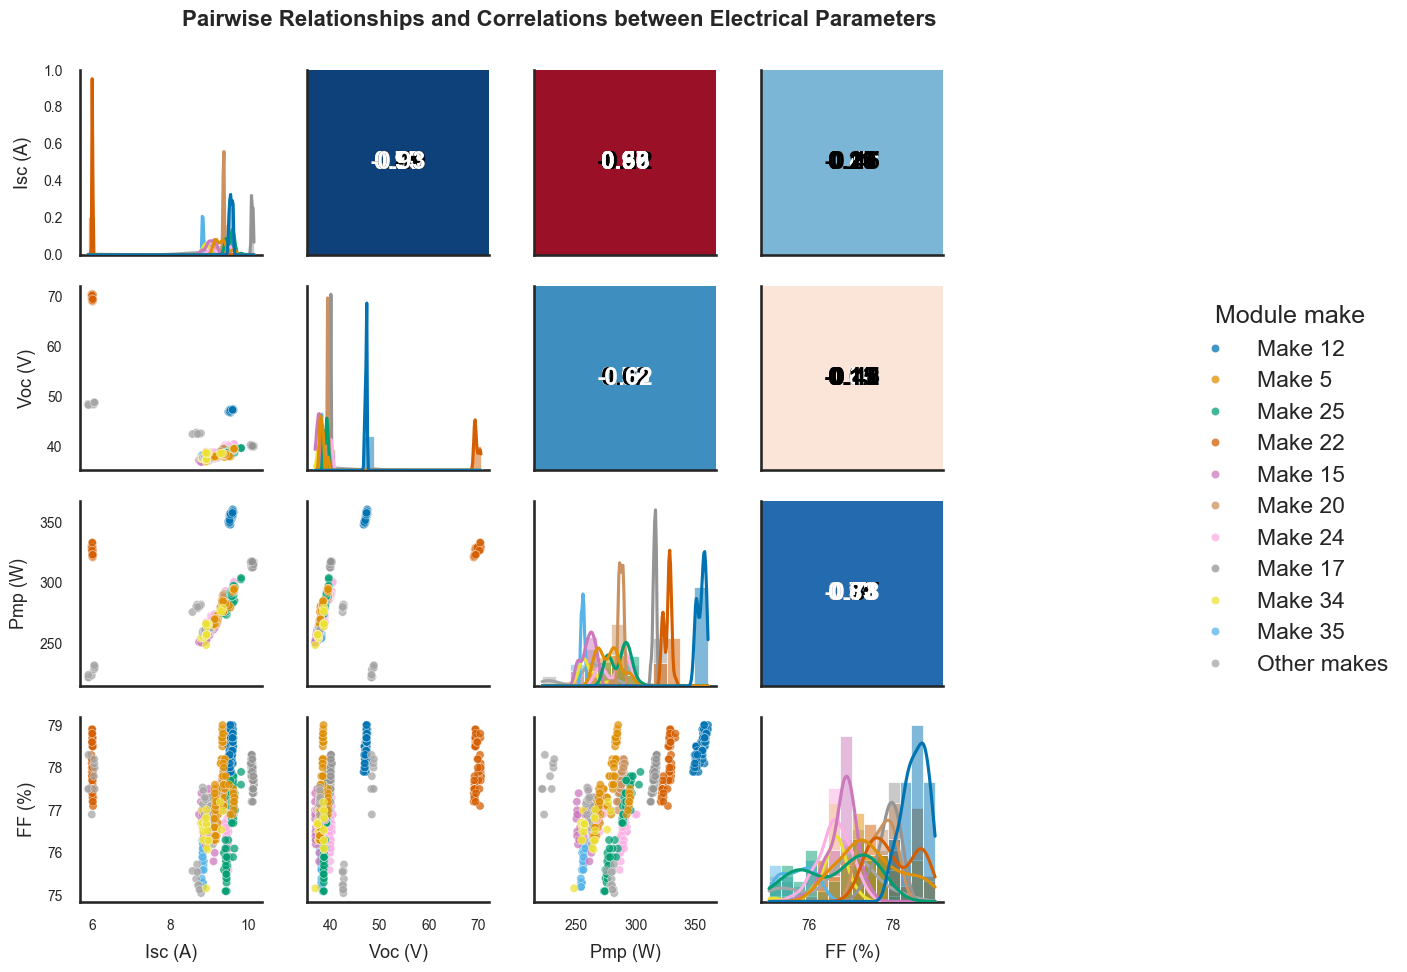

Saved to: pairplot_electrical_parameters_by_make_filtered.png


In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# 1. Choose columns
# ============================================================

cols = ['Isc_(A)', 'Voc_(V)', 'Pmp_(W)', 'FF_(percent)']

# ============================================================
# 2. Copy data
# ============================================================

df_pair = df_final.copy()
df_pair.columns = df_pair.columns.astype(str).str.strip()

# ============================================================
# 3. Remove shingle, unknown, missing, and 128-cell modules
# ============================================================

num_cells_raw = df_pair["Num_Cells"].astype("string").str.strip().str.lower()
num_cells_numeric = pd.to_numeric(num_cells_raw, errors="coerce")

remove_mask = (
    num_cells_raw.str.contains("shingle", na=False) |
    num_cells_raw.isna() |
    num_cells_raw.isin(["", "unknown", "nan", "none", "<na>"]) |
    (num_cells_numeric == 128)
)

df_pair = df_pair.loc[~remove_mask].copy()

print("Remaining Num_Cells values:")
print(df_pair["Num_Cells"].value_counts(dropna=False))

# ============================================================
# 4. Clean Make label
# ============================================================

def clean_make_label(x):
    if pd.isna(x):
        return "Make Unknown"

    s = str(x).strip()

    if s == "" or s.lower() in ["nan", "none", "<na>", "unknown"]:
        return "Make Unknown"

    try:
        v = float(s)
        if v.is_integer():
            return f"Make {int(v)}"
        else:
            return f"Make {v:g}"
    except ValueError:
        return f"Make {s}"


df_pair["Make_Label"] = df_pair["Make"].apply(clean_make_label)

# ============================================================
# 5. Keep only required columns and Make_Label
# ============================================================

plot_cols = cols + ["Make_Label"]
df_pair = df_pair[plot_cols].copy()

# Convert numeric columns safely
for col in cols:
    df_pair[col] = pd.to_numeric(df_pair[col], errors="coerce")

df_pair = df_pair.dropna(subset=cols + ["Make_Label"]).copy()

print("\nData used for pairplot:", df_pair.shape)

# ============================================================
# 6. Optional: keep only top makes, group the rest as Other
#    This avoids too many colors if there are many makes.
# ============================================================

top_n_makes = 10

top_makes = df_pair["Make_Label"].value_counts().head(top_n_makes).index

df_pair["Make_For_Plot"] = np.where(
    df_pair["Make_Label"].isin(top_makes),
    df_pair["Make_Label"],
    "Other makes"
)

# Sort legend by number of samples
make_order = (
    df_pair["Make_For_Plot"]
    .value_counts()
    .index
    .tolist()
)

# Put "Other makes" at the end
if "Other makes" in make_order:
    make_order = [m for m in make_order if m != "Other makes"] + ["Other makes"]

# ============================================================
# 7. Better color palette
# ============================================================

# Good qualitative palettes:
# "tab10", "Set2", "Dark2", "Paired", "colorblind"
palette = sns.color_palette("colorblind", n_colors=len(make_order))

palette_dict = dict(zip(make_order, palette))

# Make "Other makes" grey
if "Other makes" in palette_dict:
    palette_dict["Other makes"] = (0.65, 0.65, 0.65)

# ============================================================
# 8. Create PairGrid
# ============================================================

sns.set_theme(style="white", context="talk")

g = sns.PairGrid(
    df_pair,
    vars=cols,
    hue="Make_For_Plot",
    hue_order=make_order,
    palette=palette_dict,
    diag_sharey=False,
    corner=False
)

# ============================================================
# 9. Lower triangle: scatter by Make
# ============================================================

g.map_lower(
    sns.scatterplot,
    s=35,
    alpha=0.75,
    edgecolor="white",
    linewidth=0.3
)

# ============================================================
# 10. Upper triangle: correlation heatmap
# ============================================================

def corr_heatmap(x, y, **kwargs):
    ax = plt.gca()

    valid = np.isfinite(x) & np.isfinite(y)

    if valid.sum() < 2:
        r = np.nan
    else:
        r = np.corrcoef(x[valid], y[valid])[0, 1]

    cmap = plt.cm.RdBu_r

    if np.isnan(r):
        ax.set_facecolor("lightgrey")
        text = "NA"
        text_color = "black"
    else:
        ax.set_facecolor(cmap((r + 1) / 2))
        text = f"{r:.2f}"
        text_color = "white" if abs(r) > 0.5 else "black"

    ax.tick_params(
        left=False,
        bottom=False,
        labelleft=False,
        labelbottom=False
    )

    ax.text(
        0.5,
        0.5,
        text,
        ha="center",
        va="center",
        fontsize=18,
        fontweight="bold",
        color=text_color,
        transform=ax.transAxes
    )

g.map_upper(corr_heatmap)

# ============================================================
# 11. Diagonal: histogram
# ============================================================

g.map_diag(
    sns.histplot,
    kde=True,
    color="#A6CEE3",
    edgecolor="white",
    linewidth=0.5
)

# ============================================================
# 12. Axis labels and styling
# ============================================================

nice_labels = {
    'Isc_(A)': 'Isc (A)',
    'Voc_(V)': 'Voc (V)',
    'Pmp_(W)': 'Pmp (W)',
    'FF_(percent)': 'FF (%)'
}

for i, col in enumerate(cols):
    g.axes[-1, i].set_xlabel(nice_labels.get(col, col), fontsize=13, labelpad=8)
    g.axes[i, 0].set_ylabel(nice_labels.get(col, col), fontsize=13, labelpad=8)

for ax in g.axes.flatten():
    if ax is not None:
        ax.tick_params(axis='both', labelsize=10)
        ax.grid(False)

# ============================================================
# 13. Legend
# ============================================================

g.add_legend(
    title="Module make",
    bbox_to_anchor=(1.02, 0.5),
    loc="center left",
    borderaxespad=0
)

# ============================================================
# 14. Title and save
# ============================================================

g.fig.set_size_inches(12, 10)

plt.subplots_adjust(
    top=0.92,
    right=0.82
)

g.fig.suptitle(
    "Pairwise Relationships and Correlations between Electrical Parameters",
    fontsize=16,
    fontweight="bold"
)

save_path = "pairplot_electrical_parameters_by_make_filtered.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved to:", save_path)

Data used: (638, 4)

Correlation matrix:


,Isc_(A),Voc_(V),Pmp_(W),FF_(percent)
Isc_(A),1.000,-0.833,-0.030,-0.103
Voc_(V),-0.833,1.000,0.566,0.438
Pmp_(W),-0.030,0.566,1.000,0.715
FF_(percent),-0.103,0.438,0.715,1.000


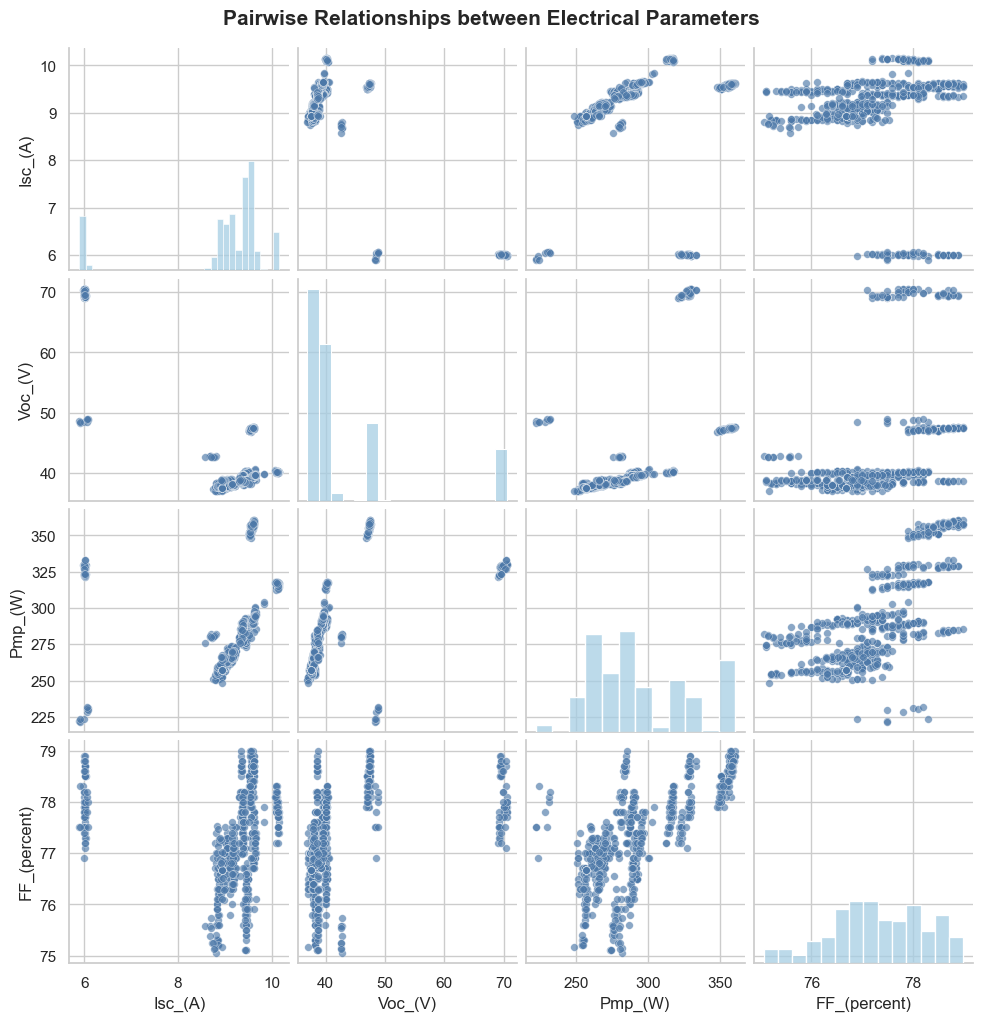

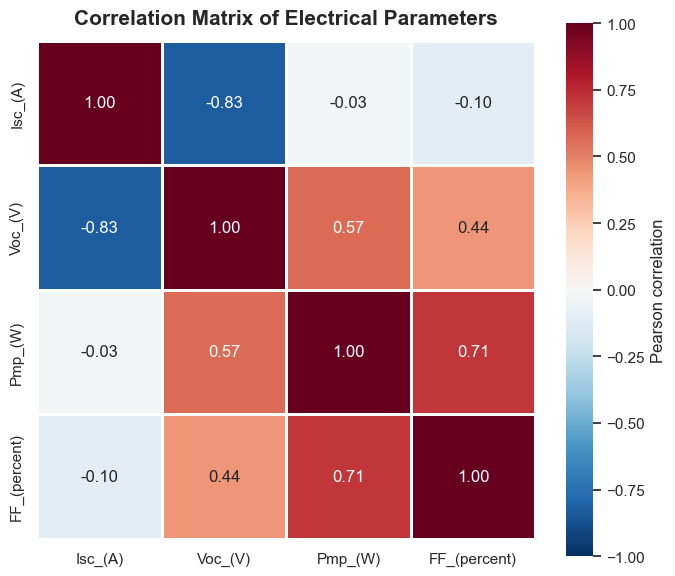

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# 1. Select columns
# ============================================================

cols = ['Isc_(A)', 'Voc_(V)', 'Pmp_(W)', 'FF_(percent)']

df_pair = df_final.copy()
df_pair.columns = df_pair.columns.astype(str).str.strip()

# ============================================================
# 2. Filter out shingle, unknown, missing, and 128-cell modules
# ============================================================

num_cells_raw = (
    df_pair["Num_Cells"]
    .astype("string")
    .str.strip()
    .str.lower()
)

num_cells_numeric = pd.to_numeric(num_cells_raw, errors="coerce")

df_pair = df_pair[
    num_cells_numeric.notna() &
    (num_cells_numeric != 128)
].copy()

# ============================================================
# 3. Keep only selected columns and convert to numeric
# ============================================================

df_pair = df_pair[cols].copy()

for col in cols:
    df_pair[col] = pd.to_numeric(df_pair[col], errors="coerce")

df_pair = df_pair.replace([np.inf, -np.inf], np.nan)
df_pair = df_pair.dropna(subset=cols)

print("Data used:", df_pair.shape)
print("\nCorrelation matrix:")
display(df_pair.corr().round(3))

# ============================================================
# 4. Normal pairplot
# ============================================================

sns.set_theme(style="whitegrid", context="notebook")

g = sns.pairplot(
    df_pair,
    vars=cols,
    diag_kind="hist",
    corner=False,
    plot_kws={
        "s": 30,
        "alpha": 0.65,
        "color": "#4C78A8",
        "edgecolor": "white",
        "linewidth": 0.3
    },
    diag_kws={
        "color": "#A6CEE3",
        "edgecolor": "white"
    }
)

g.fig.suptitle(
    "Pairwise Relationships between Electrical Parameters",
    y=1.02,
    fontsize=15,
    fontweight="bold"
)

plt.show()

# ============================================================
# 5. Separate correlation heatmap
# ============================================================

corr = df_pair.corr(method="pearson")

plt.figure(figsize=(7, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.8,
    linecolor="white",
    cbar_kws={"label": "Pearson correlation"}
)

plt.title(
    "Correlation Matrix of Electrical Parameters",
    fontsize=15,
    fontweight="bold",
    pad=12
)

plt.tight_layout()
plt.show()

# 2. Color Scatter Plot

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_scatter(df, x_axis, y_axis, different_color=None, add_regression=True):
    """
    Scatter plot dengan opsi grouping warna dan regression line
    
    Parameters:
    df : DataFrame
    x_axis : str (nama kolom untuk sumbu X)
    y_axis : str (nama kolom untuk sumbu Y)
    different_color : str (opsional, kolom untuk grouping warna)
    add_regression : bool (default True)
    """
    
    # Drop NaN biar clean
    cols = [x_axis, y_axis]
    if different_color:
        cols.append(different_color)
        
    df_clean = df[cols].dropna()

    plt.figure(figsize=(8,6))

    if different_color:
        sns.scatterplot(
            data=df_clean,
            x=x_axis,
            y=y_axis,
            hue=different_color,
            palette='tab10',
            s=70
        )
    else:
        sns.scatterplot(
            data=df_clean,
            x=x_axis,
            y=y_axis,
            s=70
        )

    # Regression line
    if add_regression:
        sns.regplot(
            data=df_clean,
            x=x_axis,
            y=y_axis,
            scatter=False,
            color='black',
            line_kws={'linewidth': 2}
        )

        # Correlation
        corr = df_clean[x_axis].corr(df_clean[y_axis])
        plt.title(f"{y_axis} vs {x_axis} (corr = {corr:.3f})")
    else:
        plt.title(f"{y_axis} vs {x_axis}")

    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [22]:
def plot_scatter(df, x_axis, y_axis, different_color=None, add_regression=True,
                 log_x=False, log_y=False):

    import matplotlib.pyplot as plt
    import seaborn as sns

    cols = [x_axis, y_axis]
    if different_color:
        cols.append(different_color)
        
    df_clean = df[cols].dropna()

    # 🔥 FILTER kalau pakai log
    if log_x:
        df_clean = df_clean[df_clean[x_axis] > 0]
    if log_y:
        df_clean = df_clean[df_clean[y_axis] > 0]

    plt.figure(figsize=(8,6))

    # 🎨 Scatter dengan atau tanpa warna
    if different_color:
        sns.scatterplot(
            data=df_clean,
            x=x_axis,
            y=y_axis,
            hue=different_color,
            palette='tab10',
            s=70
        )
    else:
        sns.scatterplot(
            data=df_clean,
            x=x_axis,
            y=y_axis,
            s=70
        )

    # 📈 Regression line (global, tidak per warna)
    if add_regression:
        sns.regplot(
            data=df_clean,
            x=x_axis,
            y=y_axis,
            scatter=False,
            color='black',
            line_kws={'linewidth': 2}
        )

        corr = df_clean[x_axis].corr(df_clean[y_axis])
        title = f"{y_axis} vs {x_axis} (corr = {corr:.3f})"
    else:
        title = f"{y_axis} vs {x_axis}"

    # ⚙️ LOG SCALE
    if log_x:
        plt.xscale('log')
    if log_y:
        plt.yscale('log')

    plt.title(title)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.grid(True, which="both", linestyle='--', linewidth=0.5)

    if different_color:
        plt.legend(title=different_color)

    plt.tight_layout()
    plt.show()

In [23]:
#df_final['Make_Model'].value_counts()
#df_final[df_final['Make_Model'] == "20_1"]

#df_final['Rsh'].describe()
df_final[(df_final['Num_Cells'] == "shingle") ].count()

Unnamed: 0             26
Mod_ID                 26
Confidential            0
Make                   26
Model                  26
                       ..
median_20              26
modus_20               26
Num_Cells              26
Total_Exposure_days    26
Make_Model             26
Length: 83, dtype: int64

In [24]:
df_final.columns.tolist()

['Unnamed: 0',
 'Mod_ID',
 'Confidential',
 'Make',
 'Model',
 'Interconnect_Tech',
 'Module_Area_(cm2)',
 'Junction_Box_Type',
 'Cell_Wafer_Type',
 'Cell_Tech',
 'Cell_Area_(cm2)',
 'Total_Exposure',
 'Nameplate_Isc_(A)',
 'Nameplate_Voc_(V)',
 'Nameplate_Imp_(A)',
 'Nameplate_Vmp_(V)',
 'Nameplate_Pmp_(W)',
 'Isc_(A)',
 'Voc_(V)',
 'Imp_(A)',
 'Vmp_(V)',
 'Pmp_(W)',
 'FF_(percent)',
 'Measured_Temperature_(C)',
 'Temp_Measurement_Method',
 'Voltage_Temperature_Coefficient_(mV/C)',
 'Simulator_Make',
 'Simulator_Model',
 'IV_Date',
 'IV_Time',
 'IV_Lab_Location',
 'Camera_Make',
 'Camera_Model',
 'Detector_Type',
 'Image_Resolution_(MP)',
 'Longpass_Filter_Wavelength_(nm)',
 'High_Applied_Current_(A)',
 'High_Applied_Voltage_(V)',
 'High_Sensor_Exposure_Time_(s)',
 'Low_Applied_Current_(A)',
 'Low_Applied_Voltage_(V)',
 'Low_Sensor_Exposure_Time_(s)',
 'ISO',
 'Aperture',
 'High_Temperature_(C)',
 'Low_Temperature_(C)',
 'Working_Distance_(m)',
 'High_EL_Date',
 'High_EL_Time',
 'Low_

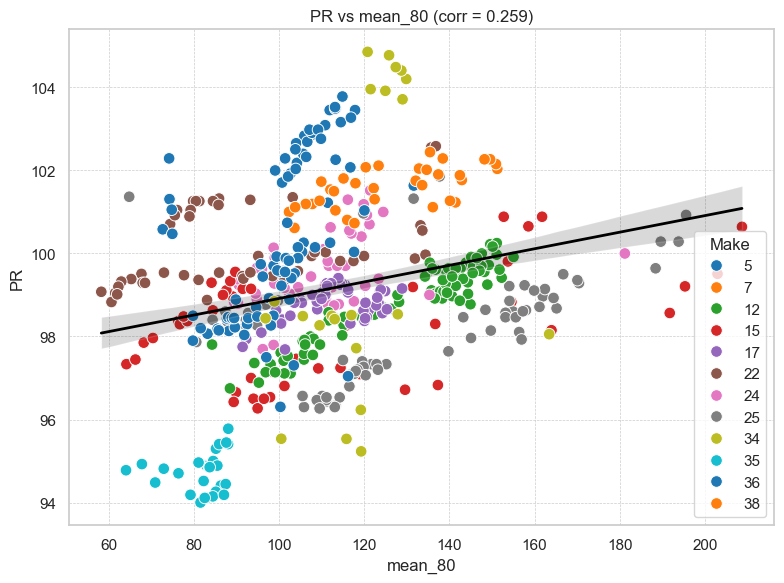

In [25]:
num_cells_raw = df_final['Num_Cells'].astype(str).str.lower().str.strip()
num_cells_numeric = pd.to_numeric(num_cells_raw, errors='coerce')

df_filtered = df_final[
    (~num_cells_raw.isin(['shingle', 'unknown', 'nan', 'none', '<na>', ''])) &
    (num_cells_numeric != 128)
].copy()

df_filtered['PR_Voc'] = df_filtered['Voc_(V)'] / df_filtered['Nameplate_Voc_(V)']

plot_scatter(
    df_filtered[df_filtered['PR'] > 0.94],  # Filter untuk menghindari nilai negatif atau nol
    x_axis='mean_80',
    y_axis='PR',
    different_color='Make',
    log_x=False,
    log_y=False
)

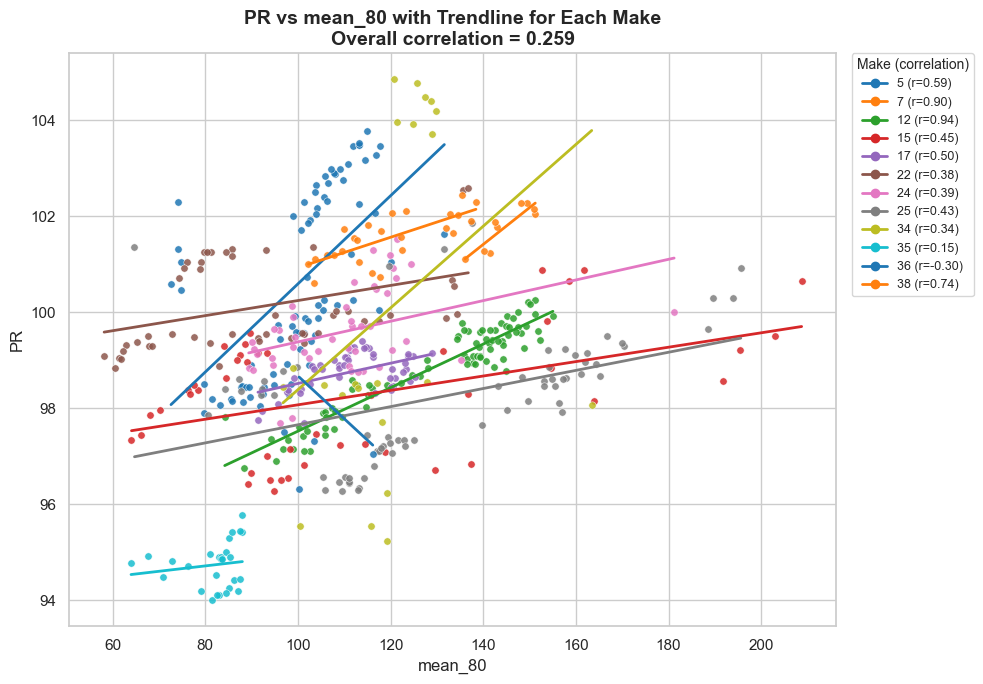

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# ============================================================
# 1. Settings
# ============================================================

x_col = "mean_80"
y_col = "PR"
group_col = "Make"

# ============================================================
# 2. Prepare data
# ============================================================

df_plot = df_filtered.copy()
df_plot.columns = df_plot.columns.astype(str).str.strip()

# Optional: remove shingle, unknown, and 128-cell modules
num_cells_raw = df_plot["Num_Cells"].astype("string").str.strip().str.lower()
num_cells_numeric = pd.to_numeric(num_cells_raw, errors="coerce")

df_plot = df_plot[
    num_cells_numeric.notna() &
    (num_cells_numeric != 128)
].copy()

# Keep only needed columns
df_plot = df_plot[[x_col, y_col, group_col]].copy()

# Convert numeric columns
df_plot[x_col] = pd.to_numeric(df_plot[x_col], errors="coerce")
df_plot[y_col] = pd.to_numeric(df_plot[y_col], errors="coerce")
df_plot[group_col] = pd.to_numeric(df_plot[group_col], errors="coerce")

df_plot = df_plot.dropna(subset=[x_col, y_col, group_col]).copy()

# Convert make into integer if possible
df_plot[group_col] = df_plot[group_col].astype(int)

# Sort makes
make_list = sorted(df_plot[group_col].unique())

# ============================================================
# 3. Color palette
# ============================================================

palette = sns.color_palette("tab10", n_colors=len(make_list))
color_map = dict(zip(make_list, palette))

# ============================================================
# 4. Plot
# ============================================================

sns.set_theme(style="whitegrid", context="notebook")

fig, ax = plt.subplots(figsize=(10, 7))

legend_handles = []

for make in make_list:
    group = df_plot[df_plot[group_col] == make].copy()
    color = color_map[make]

    # Scatter
    ax.scatter(
        group[x_col],
        group[y_col],
        s=28,
        alpha=0.85,
        color=color,
        edgecolor="white",
        linewidth=0.4
    )

    # Correlation and trendline
    if len(group) >= 2 and group[x_col].nunique() >= 2 and group[y_col].nunique() >= 2:
        r = group[x_col].corr(group[y_col])

        slope, intercept = np.polyfit(group[x_col], group[y_col], 1)
        x_line = np.linspace(group[x_col].min(), group[x_col].max(), 100)
        y_line = slope * x_line + intercept

        ax.plot(
            x_line,
            y_line,
            color=color,
            linewidth=2
        )

        legend_label = f"{make} (r={r:.2f})"
    else:
        legend_label = f"{make} (r=NA)"

    # Custom legend entry
    handle = Line2D(
        [0], [0],
        marker='o',
        color=color,
        label=legend_label,
        markerfacecolor=color,
        markersize=6,
        linewidth=2
    )
    legend_handles.append(handle)

# ============================================================
# 5. Overall correlation
# ============================================================

overall_r = df_plot[x_col].corr(df_plot[y_col])

# ============================================================
# 6. Labels and legend
# ============================================================

ax.set_xlabel(x_col, fontsize=12)
ax.set_ylabel(y_col, fontsize=12)
ax.set_title(
    f"{y_col} vs {x_col} with Trendline for Each Make\n"
    f"Overall correlation = {overall_r:.3f}",
    fontsize=14,
    fontweight="bold"
)

ax.legend(
    handles=legend_handles,
    title="Make (correlation)",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
    fontsize=9,
    title_fontsize=10
)

plt.tight_layout()
plt.show()

In [20]:
import plotly.express as px
import nbformat as nb

def plot_scatter_plotly(df, x_axis, y_axis, color=None):
    fig = px.scatter(
        df,
        x=x_axis,
        y=y_axis,
        color=color,
        hover_data=df.columns,  # semua info muncul saat hover
        title=f"{y_axis} vs {x_axis}",
        template="plotly_white"
    )

    fig.show()

In [21]:
import plotly.express as px

def plot_scatter_plotly(df, x_axis, y_axis, color=None, hover_name=None, save_html=None):
    cols = [x_axis, y_axis]
    if color:
        cols.append(color)
    if hover_name and hover_name not in cols:
        cols.append(hover_name)

    df_clean = df[cols].dropna().copy()

    fig = px.scatter(
        df_clean,
        x=x_axis,
        y=y_axis,
        color=color,
        hover_name=hover_name,
        hover_data=df_clean.columns,
        trendline="ols",
        template="plotly_white",
        title=f"{y_axis} vs {x_axis}"
    )

    if save_html:
        fig.write_html(save_html, auto_open=True)
    else:
        from plotly.offline import plot
        plot(fig, auto_open=True)

In [22]:
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.offline import plot

def plot_scatter_quadratic(df, x_axis, y_axis, color=None, hover_name=None):
    
    cols = [x_axis, y_axis]
    if color:
        cols.append(color)
    if hover_name and hover_name not in cols:
        cols.append(hover_name)

    df_clean = df[cols].dropna().copy()

    # Scatter plot
    fig = px.scatter(
        df_clean,
        x=x_axis,
        y=y_axis,
        color=color,
        hover_name=hover_name,
        hover_data=df_clean.columns,
        template="plotly_white",
        title=f"{y_axis} vs {x_axis} (Quadratic Fit)"
    )

    # Quadratic fit
    x = df_clean[x_axis].astype(float).values
    y = df_clean[y_axis].astype(float).values

    if len(x) >= 3:
        coeffs = np.polyfit(x, y, 2)  # 🔥 degree 2
        x_line = np.linspace(x.min(), x.max(), 200)
        y_line = coeffs[0]*x_line**2 + coeffs[1]*x_line + coeffs[2]

        fig.add_trace(
            go.Scatter(
                x=x_line,
                y=y_line,
                mode="lines",
                name="Quadratic Fit",
                line=dict(color="black", width=3)
            )
        )

    plot(fig, auto_open=True)

In [23]:
plot_scatter_quadratic(
    df=meta_merged,
    x_axis="mean_80",
    y_axis="PR",
    color="Make_Model",
    hover_name="Model"
)

KeyError: "['Make_Model'] not in index"

In [24]:
import pandas as pd

df_num = meta_merged.select_dtypes(include=["number"])
corr = df_num.corr(method="spearman")

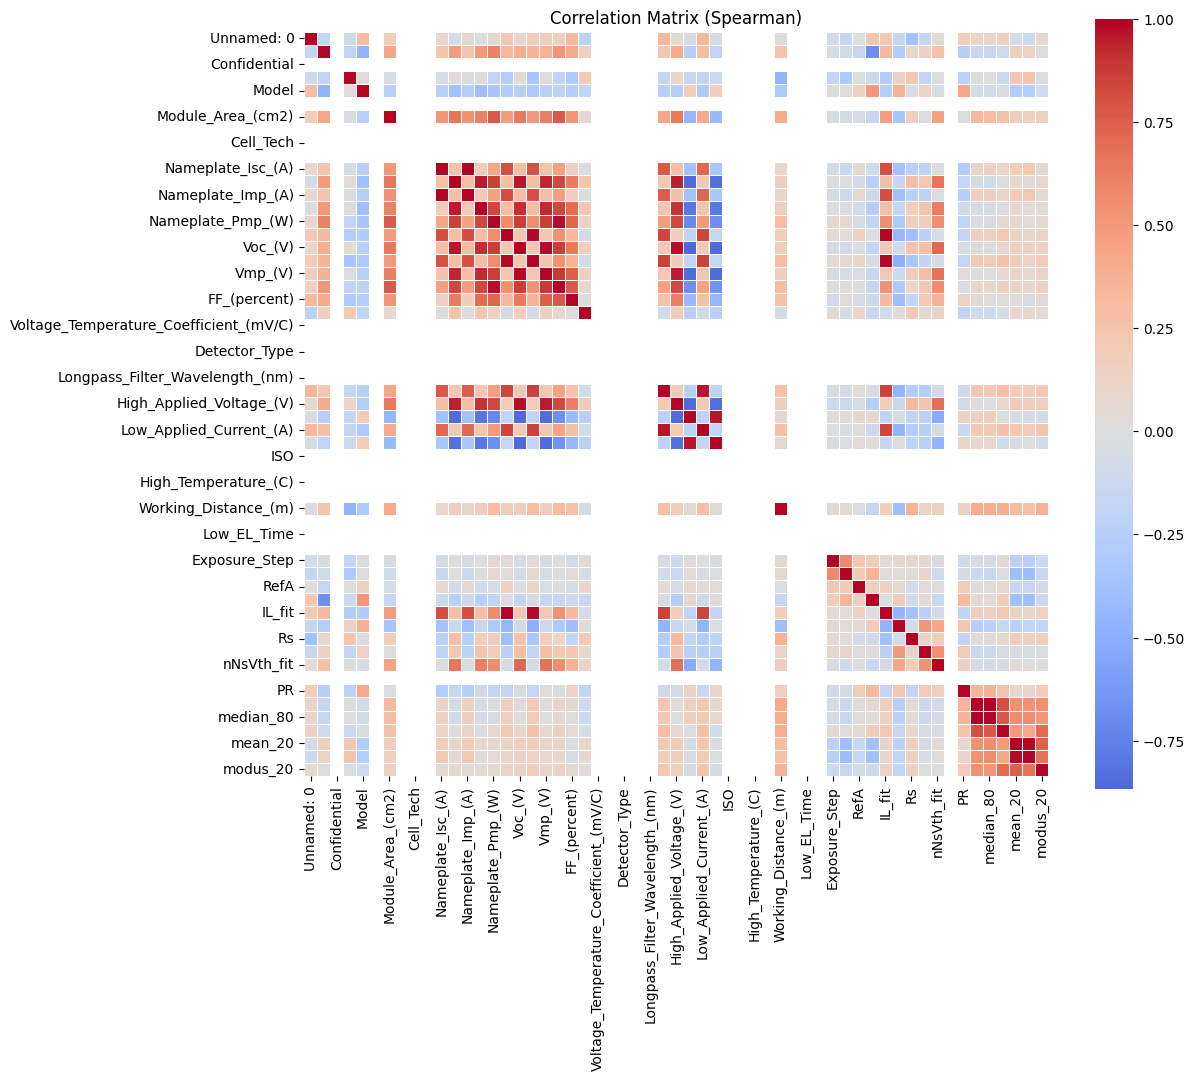

In [25]:
plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Correlation Matrix (Spearman)")
plt.show()

In [26]:
meta_merged[["mean_80", "mean_80_norm", "PR"]].corr(method="spearman")

#print(corr_target)

KeyError: "['mean_80_norm'] not in index"

In [27]:
meta_merged["mean_80_norm"] = meta_merged["mean_80"] * (meta_merged["Working_Distance_(m)"])

In [28]:
meta_merged[["mean_80", "Rs"]].corr(method="spearman")

,mean_80,Rs
mean_80,1.000000,0.038138
Rs,0.038138,1.000000


In [29]:
corr["Pmp_(W)"].sort_values(ascending=False)

Pmp_(W)                                   1.000000
Nameplate_Pmp_(W)                         0.975277
Vmp_(V)                                   0.878702
Voc_(V)                                   0.867568
Nameplate_Vmp_(V)                         0.833656
Nameplate_Voc_(V)                         0.833065
High_Applied_Voltage_(V)                  0.830794
Module_Area_(cm2)                         0.772153
FF_(percent)                              0.769517
nNsVth_fit                                0.556657
Imp_(A)                                   0.538985
Isc_(A)                                   0.531276
IL_fit                                    0.527141
Mod_ID                                    0.515851
Nameplate_Imp_(A)                         0.479774
Nameplate_Isc_(A)                         0.461267
Low_Applied_Current_(A)                   0.453556
High_Applied_Current_(A)                  0.450621
Working_Distance_(m)                      0.299234
Rsh                            

In [30]:
import sys
import plotly
import plotly.io as pio
import nbformat
import IPython

print("Python:", sys.executable)
print("Plotly:", plotly.__version__)
print("nbformat:", nbformat.__version__)
print("IPython:", IPython.__version__)
print("Default renderer:", pio.renderers.default)
print(pio.renderers)

Python: c:\Users\Ghozy Abror\anaconda3\envs\UNSWThesis\python.exe
Plotly: 6.6.0
nbformat: 5.10.4
IPython: 8.30.0
Default renderer: vscode
Renderers configuration
-----------------------
    Default renderer: 'vscode'
    Available renderers:
        ['plotly_mimetype', 'jupyterlab', 'nteract', 'vscode',
         'notebook', 'notebook_connected', 'kaggle', 'azure', 'colab',
         'cocalc', 'databricks', 'json', 'png', 'jpeg', 'jpg', 'svg',
         'pdf', 'browser', 'firefox', 'chrome', 'chromium', 'iframe',
         'iframe_connected', 'sphinx_gallery', 'sphinx_gallery_png']



In [31]:
import plotly.io as pio

pio.renderers.default = "browser"
print("Renderer aktif:", pio.renderers.default)

Renderer aktif: browser


In [32]:
import plotly.express as px

fig = px.scatter(
    meta_merged.dropna(subset=["mean_80", "PR"]),
    x="mean_80",
    y="PR",
    color="Make_Model",
    template="plotly"
)

fig.show(renderer="browser")

ValueError: Value of 'color' is not the name of a column in 'data_frame'. Expected one of ['Unnamed: 0', 'Mod_ID', 'Confidential', 'Make', 'Model', 'Interconnect_Tech', 'Module_Area_(cm2)', 'Junction_Box_Type', 'Cell_Wafer_Type', 'Cell_Tech', 'Cell_Area_(cm2)', 'Total_Exposure', 'Nameplate_Isc_(A)', 'Nameplate_Voc_(V)', 'Nameplate_Imp_(A)', 'Nameplate_Vmp_(V)', 'Nameplate_Pmp_(W)', 'Isc_(A)', 'Voc_(V)', 'Imp_(A)', 'Vmp_(V)', 'Pmp_(W)', 'FF_(percent)', 'Measured_Temperature_(C)', 'Temp_Measurement_Method', 'Voltage_Temperature_Coefficient_(mV/C)', 'Simulator_Make', 'Simulator_Model', 'IV_Date', 'IV_Time', 'IV_Lab_Location', 'Camera_Make', 'Camera_Model', 'Detector_Type', 'Image_Resolution_(MP)', 'Longpass_Filter_Wavelength_(nm)', 'High_Applied_Current_(A)', 'High_Applied_Voltage_(V)', 'High_Sensor_Exposure_Time_(s)', 'Low_Applied_Current_(A)', 'Low_Applied_Voltage_(V)', 'Low_Sensor_Exposure_Time_(s)', 'ISO', 'Aperture', 'High_Temperature_(C)', 'Low_Temperature_(C)', 'Working_Distance_(m

In [33]:
import plotly.express as px

def plot_scatter_plotly_browser(df, x_axis, y_axis, color=None, hover_name=None, filename="scatter_plot.html"):
    cols = [x_axis, y_axis]
    if color:
        cols.append(color)
    if hover_name and hover_name not in cols:
        cols.append(hover_name)

    df_clean = df[cols].dropna().copy()

    fig = px.scatter(
        df_clean,
        x=x_axis,
        y=y_axis,
        color=color,
        hover_name=hover_name,
        hover_data=df_clean.columns,
        template="plotly_white",
        title=f"{y_axis} vs {x_axis}"
    )

    fig.write_html(filename, auto_open=True)

In [34]:
import plotly.express as px

fig = px.scatter(
    meta_merged.dropna(subset=["mean_80", "PR"]),
    x="mean_80",
    y="PR",
    color="Make_Model",
    template="plotly",
    color_discrete_sequence=px.colors.qualitative.Alphabet  # 🔥 lebih banyak warna
)

fig.show(renderer="browser")

ValueError: Value of 'color' is not the name of a column in 'data_frame'. Expected one of ['Unnamed: 0', 'Mod_ID', 'Confidential', 'Make', 'Model', 'Interconnect_Tech', 'Module_Area_(cm2)', 'Junction_Box_Type', 'Cell_Wafer_Type', 'Cell_Tech', 'Cell_Area_(cm2)', 'Total_Exposure', 'Nameplate_Isc_(A)', 'Nameplate_Voc_(V)', 'Nameplate_Imp_(A)', 'Nameplate_Vmp_(V)', 'Nameplate_Pmp_(W)', 'Isc_(A)', 'Voc_(V)', 'Imp_(A)', 'Vmp_(V)', 'Pmp_(W)', 'FF_(percent)', 'Measured_Temperature_(C)', 'Temp_Measurement_Method', 'Voltage_Temperature_Coefficient_(mV/C)', 'Simulator_Make', 'Simulator_Model', 'IV_Date', 'IV_Time', 'IV_Lab_Location', 'Camera_Make', 'Camera_Model', 'Detector_Type', 'Image_Resolution_(MP)', 'Longpass_Filter_Wavelength_(nm)', 'High_Applied_Current_(A)', 'High_Applied_Voltage_(V)', 'High_Sensor_Exposure_Time_(s)', 'Low_Applied_Current_(A)', 'Low_Applied_Voltage_(V)', 'Low_Sensor_Exposure_Time_(s)', 'ISO', 'Aperture', 'High_Temperature_(C)', 'Low_Temperature_(C)', 'Working_Distance_(m

Saved chart: corrected_comparison_charts\Rs_module_total_per60_vs_Rs.png


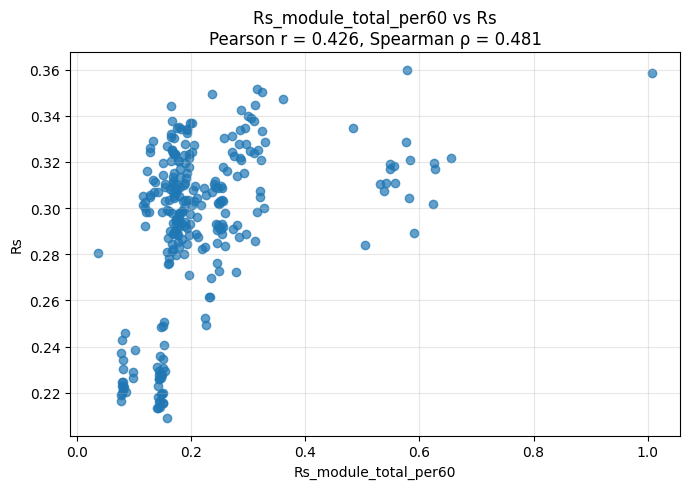

Saved chart: corrected_comparison_charts\Rs_module_mean_per60_vs_Rs.png


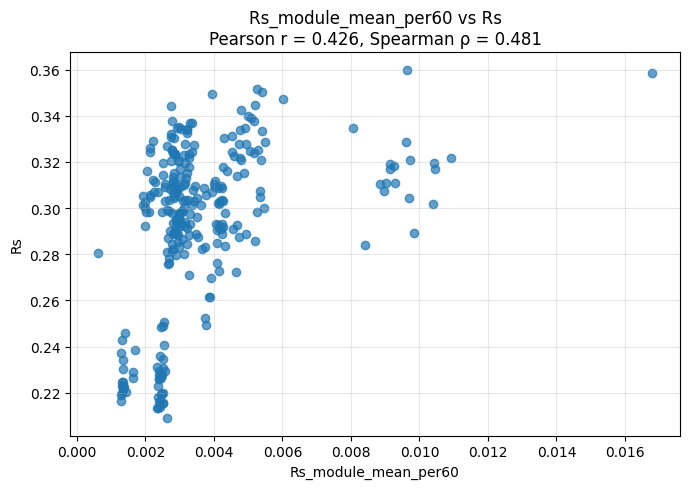

Skipped: kolom Rs_module_median_per60 tidak ditemukan
Saved chart: corrected_comparison_charts\J0_module_avg_per60_vs_I0.png


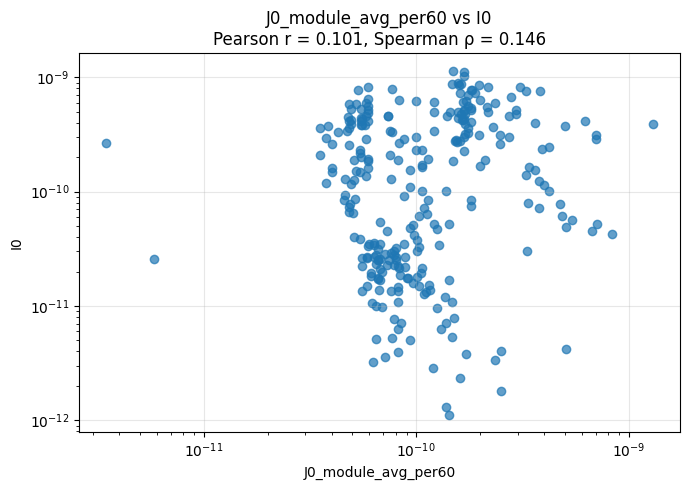

Saved chart: corrected_comparison_charts\J0_module_median_per60_vs_I0.png


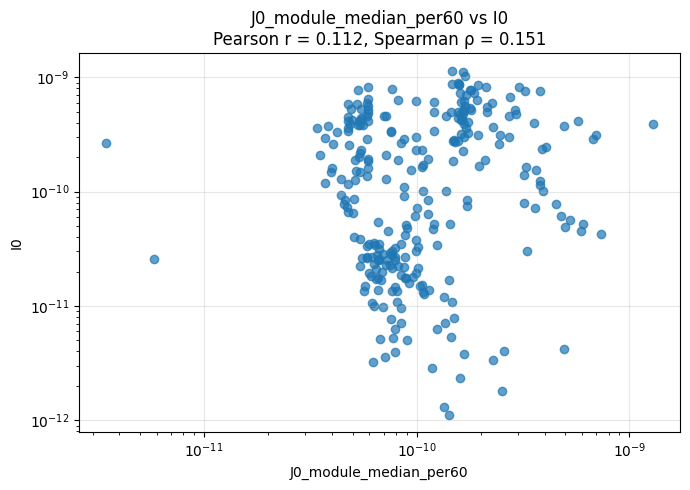


Correlation summary:
                    x_col y_col    n  pearson_r     pearson_p  spearman_rho  \
0   Rs_module_total_per60    Rs  274   0.425983  1.664524e-13      0.481099   
1    Rs_module_mean_per60    Rs  274   0.425983  1.664524e-13      0.481099   
2     J0_module_avg_per60    I0  274   0.101070  9.499293e-02      0.146174   
3  J0_module_median_per60    I0  274   0.112102  6.388588e-02      0.150622   

     spearman_p  
0  2.804221e-17  
1  2.804221e-17  
2  1.545398e-02  
3  1.255708e-02  


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from pathlib import Path

# =========================
# 1. Load data
# =========================
df = pd.read_csv("merged_sdm.csv")  # ganti sesuai nama file kamu

# =========================
# 2. Kolom yang dipakai
# =========================
rs_cols = [
    "Rs_module_total",
    "Rs_module_mean",
    "Rs_module_median"
]

j0_cols = [
    "J0_module_avg",
    "J0_module_median"
]

base_cols = [
    "vals_size",
    "Rs",
    "I0"
]

all_cols = rs_cols + j0_cols + base_cols

# =========================
# 3. Convert ke numeric
# =========================
for col in all_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# =========================
# 4. Buat kolom hasil koreksi
# =========================
# Rs: dibagi vals_size lalu dikali 60
for col in rs_cols:
    if col in df.columns:
        new_col = f"{col}_per60"
        df[new_col] = df[col] / df["vals_size"] * 60

# J0: dikali vals_size lalu dibagi 60
for col in j0_cols:
    if col in df.columns:
        new_col = f"{col}_per60"
        df[new_col] = df[col] * df["vals_size"] / 60

# =========================
# 5. Fungsi visualisasi + korelasi
# =========================
def plot_comparison(df, x_col, y_col, log_x=False, log_y=False, save=True):
    if x_col not in df.columns:
        print(f"Skipped: kolom {x_col} tidak ditemukan")
        return None
    
    if y_col not in df.columns:
        print(f"Skipped: kolom {y_col} tidak ditemukan")
        return None

    data = df[[x_col, y_col]].dropna()

    if log_x:
        data = data[data[x_col] > 0]
    if log_y:
        data = data[data[y_col] > 0]

    if len(data) < 3:
        print(f"Skipped: data valid terlalu sedikit untuk {x_col} vs {y_col}")
        return None

    x = data[x_col]
    y = data[y_col]

    pearson_r, pearson_p = pearsonr(x, y)
    spearman_rho, spearman_p = spearmanr(x, y)

    plt.figure(figsize=(7, 5))
    plt.scatter(x, y, alpha=0.7)

    plt.xlabel(x_col)
    plt.ylabel(y_col)

    plt.title(
        f"{x_col} vs {y_col}\n"
        f"Pearson r = {pearson_r:.3f}, Spearman ρ = {spearman_rho:.3f}"
    )

    if log_x:
        plt.xscale("log")
    if log_y:
        plt.yscale("log")

    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    if save:
        output_dir = Path("corrected_comparison_charts")
        output_dir.mkdir(exist_ok=True)

        filename = f"{x_col}_vs_{y_col}.png".replace("/", "_")
        save_path = output_dir / filename
        plt.savefig(save_path, dpi=300)
        print(f"Saved chart: {save_path}")

    plt.show()

    return {
        "x_col": x_col,
        "y_col": y_col,
        "n": len(data),
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "spearman_rho": spearman_rho,
        "spearman_p": spearman_p
    }

# =========================
# 6. Plot Rs corrected vs Rs
# =========================
results = []

for col in rs_cols:
    corrected_col = f"{col}_per60"
    result = plot_comparison(
        df,
        x_col=corrected_col,
        y_col="Rs",
        log_x=False,
        log_y=False
    )
    if result is not None:
        results.append(result)

# =========================
# 7. Plot J0 corrected vs I0
# Pakai log scale karena J0 dan I0 biasanya sangat kecil
# =========================
for col in j0_cols:
    corrected_col = f"{col}_per60"
    result = plot_comparison(
        df,
        x_col=corrected_col,
        y_col="I0",
        log_x=True,
        log_y=True
    )
    if result is not None:
        results.append(result)

# =========================
# 8. Simpan ringkasan korelasi
# =========================
corr_summary = pd.DataFrame(results)
corr_summary.to_csv("corrected_correlation_summary.csv", index=False)

print("\nCorrelation summary:")
print(corr_summary)

Saved chart: colored_comparison_charts\Rs_module_total_per60_vs_Rs_by_make_code.png


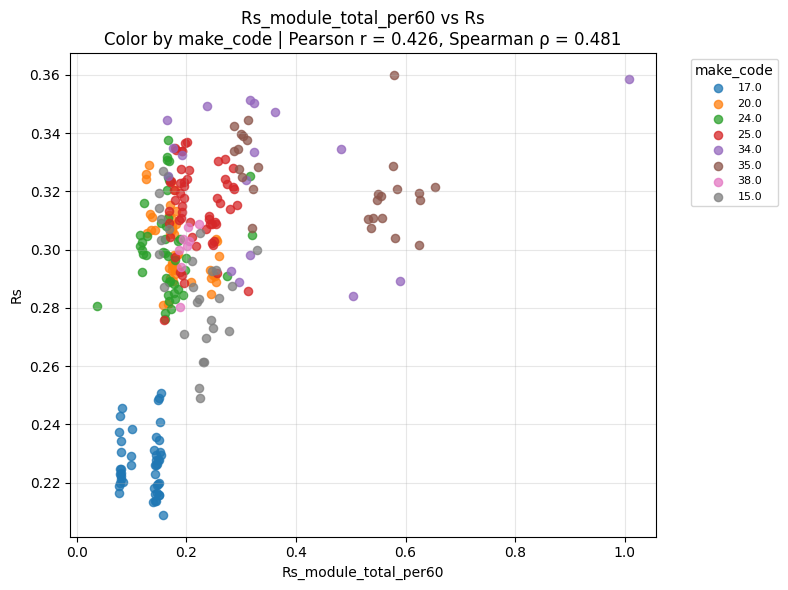

Saved chart: colored_comparison_charts\Rs_module_mean_per60_vs_Rs_by_make_code.png


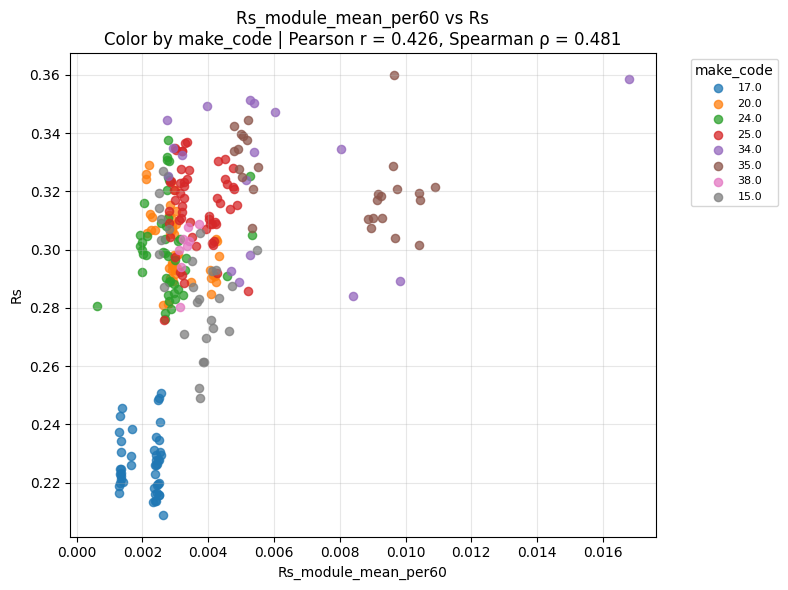

Skipped: Rs_module_median_per60 tidak ditemukan
Saved chart: colored_comparison_charts\Rs_module_total_per60_vs_Rs_by_model_code.png


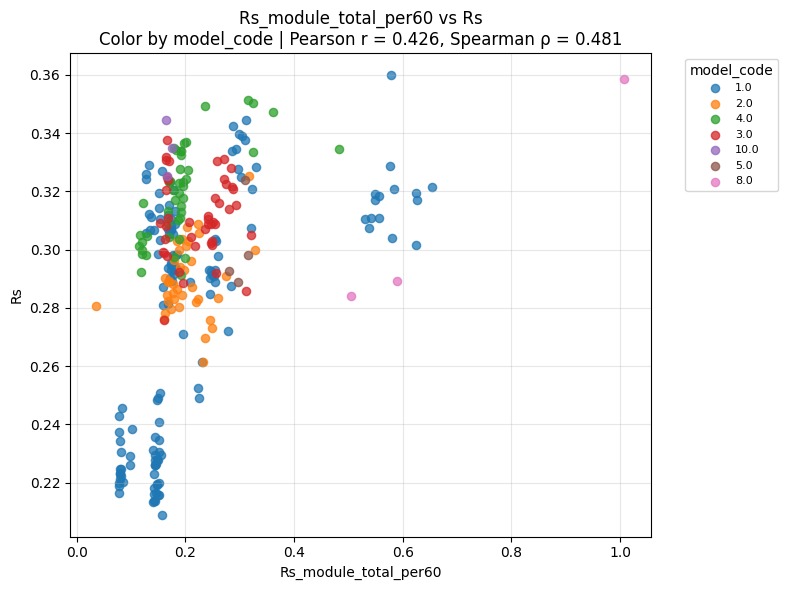

Saved chart: colored_comparison_charts\Rs_module_mean_per60_vs_Rs_by_model_code.png


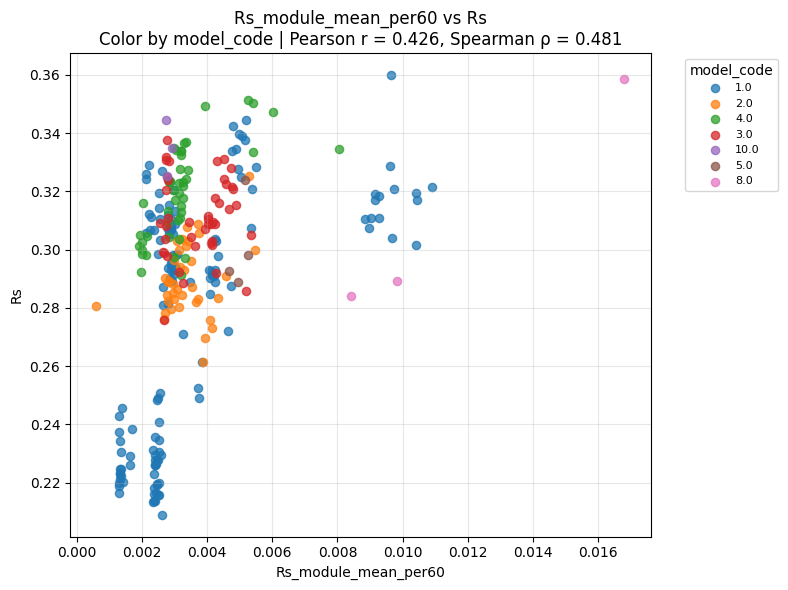

Skipped: Rs_module_median_per60 tidak ditemukan
Saved chart: colored_comparison_charts\Rs_module_total_per60_vs_Rs_by_make_model.png


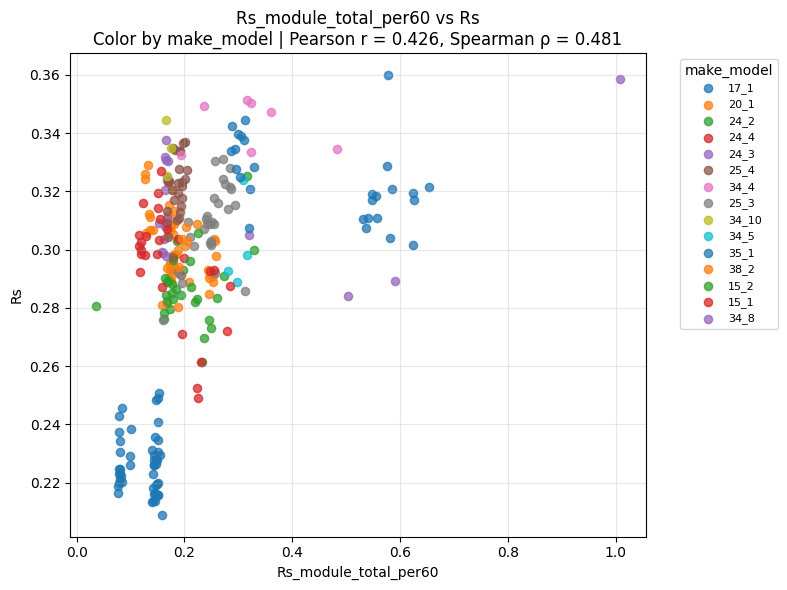

Saved chart: colored_comparison_charts\Rs_module_mean_per60_vs_Rs_by_make_model.png


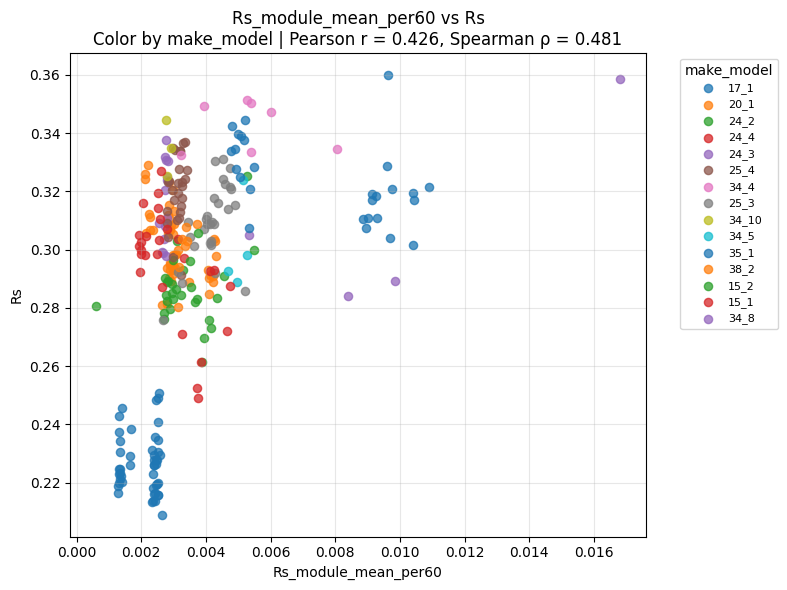

Skipped: Rs_module_median_per60 tidak ditemukan
Saved chart: colored_comparison_charts\J0_module_avg_per60_vs_I0_by_make_code.png


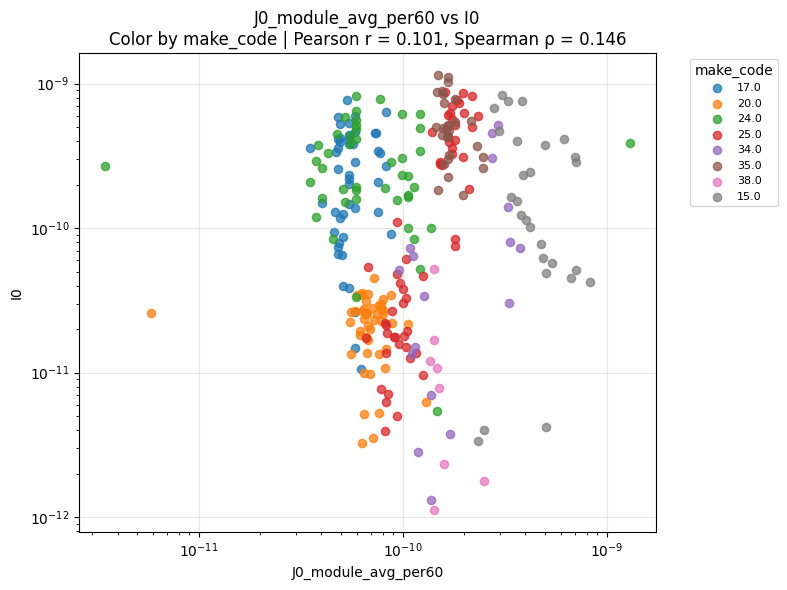

Saved chart: colored_comparison_charts\J0_module_median_per60_vs_I0_by_make_code.png


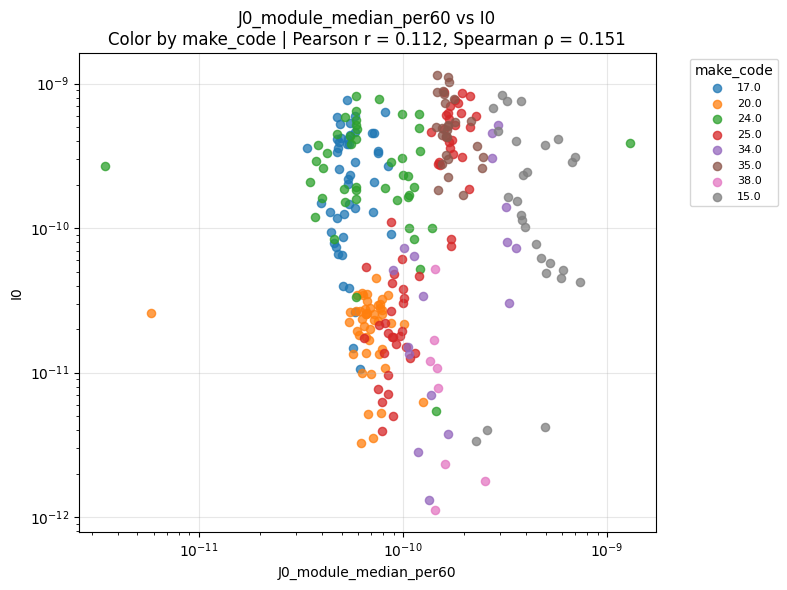

Saved chart: colored_comparison_charts\J0_module_avg_per60_vs_I0_by_model_code.png


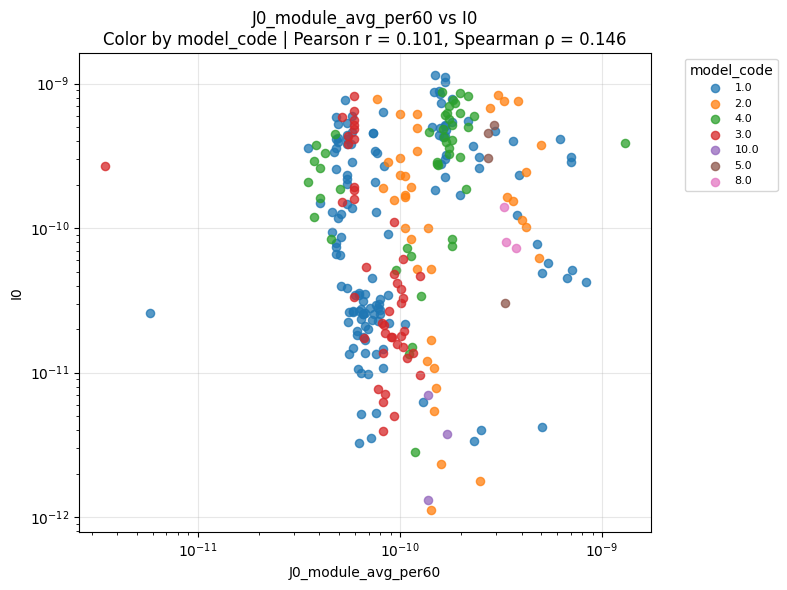

Saved chart: colored_comparison_charts\J0_module_median_per60_vs_I0_by_model_code.png


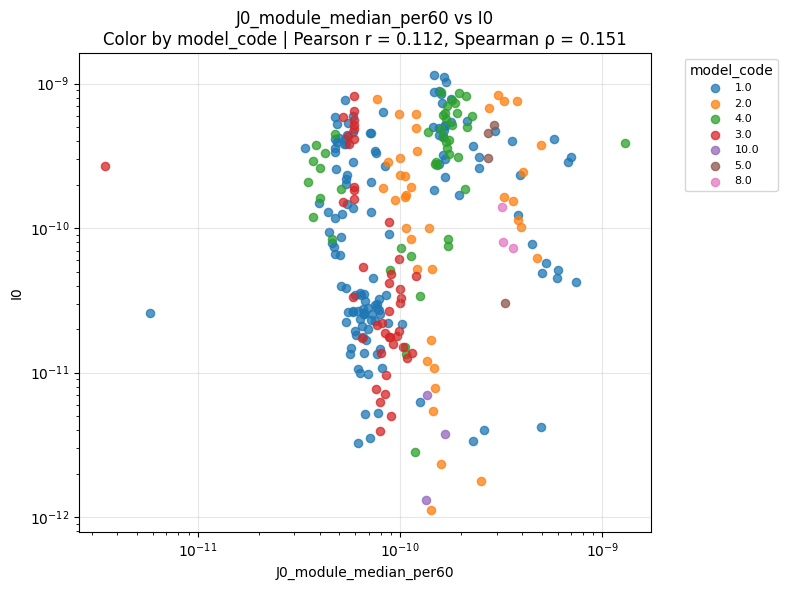

Saved chart: colored_comparison_charts\J0_module_avg_per60_vs_I0_by_make_model.png


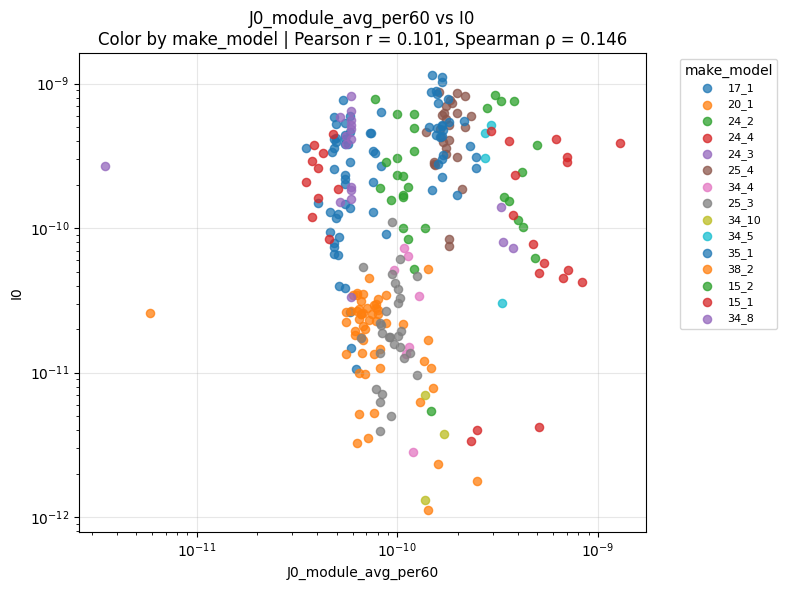

Saved chart: colored_comparison_charts\J0_module_median_per60_vs_I0_by_make_model.png


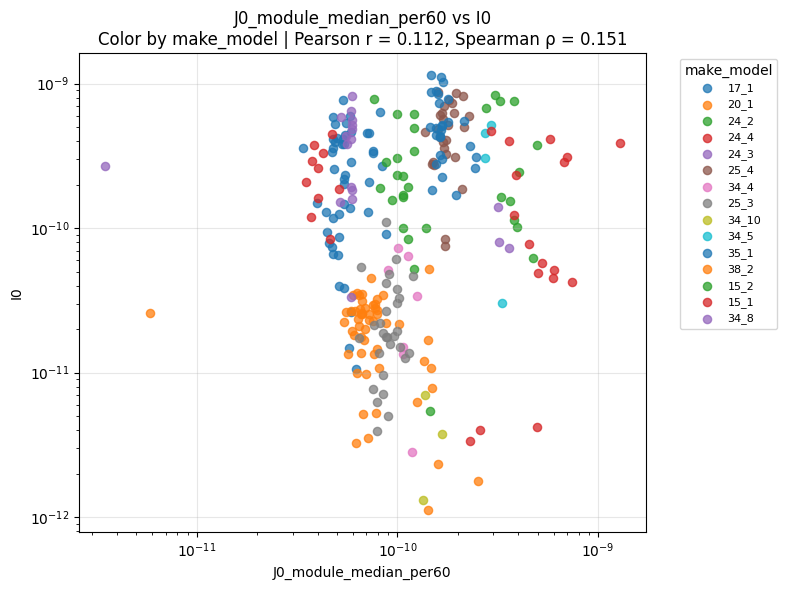

Saved dataset: merged_inner_split_corrected.csv
Saved correlation summary: colored_correlation_summary.csv
                     x_col y_col   color_col    n  pearson_r     pearson_p  \
0    Rs_module_total_per60    Rs   make_code  274   0.425983  1.664524e-13   
1     Rs_module_mean_per60    Rs   make_code  274   0.425983  1.664524e-13   
2    Rs_module_total_per60    Rs  model_code  274   0.425983  1.664524e-13   
3     Rs_module_mean_per60    Rs  model_code  274   0.425983  1.664524e-13   
4    Rs_module_total_per60    Rs  make_model  274   0.425983  1.664524e-13   
5     Rs_module_mean_per60    Rs  make_model  274   0.425983  1.664524e-13   
6      J0_module_avg_per60    I0   make_code  274   0.101070  9.499293e-02   
7   J0_module_median_per60    I0   make_code  274   0.112102  6.388588e-02   
8      J0_module_avg_per60    I0  model_code  274   0.101070  9.499293e-02   
9   J0_module_median_per60    I0  model_code  274   0.112102  6.388588e-02   
10     J0_module_avg_per60    I0  m

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from pathlib import Path

# =========================
# 1. Load data
# =========================
df = pd.read_csv("merged_sdm.csv")  # ganti sesuai nama file kamu

# =========================
# 2. Pecah kolom module
# contoh: 3395_30_1_03182016
# =========================
module_split = df["module"].astype(str).str.extract(
    r"(?P<module_id>[^_]+)_(?P<make_code>[^_]+)_(?P<model_code>[^_]+)_(?P<date_raw>\d+)"
)

df = pd.concat([df, module_split], axis=1)

# ubah date_raw ke datetime
df["date"] = pd.to_datetime(df["date_raw"], format="%m%d%Y", errors="coerce")

# gabungan make dan model
df["make_model"] = df["make_code"].astype(str) + "_" + df["model_code"].astype(str)

# optional: kalau mau module_id/make/model jadi numeric
df["module_id"] = pd.to_numeric(df["module_id"], errors="coerce")
df["make_code"] = pd.to_numeric(df["make_code"], errors="coerce")
df["model_code"] = pd.to_numeric(df["model_code"], errors="coerce")

# =========================
# 3. Convert kolom penting ke numeric
# =========================
cols_to_numeric = [
    "vals_size",
    "Rs",
    "I0",
    "Rs_module_total",
    "Rs_module_mean",
    "Rs_module_median",
    "J0_module_avg",
    "J0_module_median"
]

for col in cols_to_numeric:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# =========================
# 4. Buat kolom corrected
# =========================
rs_cols = [
    "Rs_module_total",
    "Rs_module_mean",
    "Rs_module_median"
]

j0_cols = [
    "J0_module_avg",
    "J0_module_median"
]

for col in rs_cols:
    if col in df.columns:
        df[f"{col}_per60"] = df[col] / df["vals_size"] * 60

for col in j0_cols:
    if col in df.columns:
        df[f"{col}_per60"] = df[col] * df["vals_size"] / 60

# =========================
# 5. Fungsi scatter plot dengan warna kategori
# =========================
def plot_colored_scatter(
    df,
    x_col,
    y_col,
    color_col,
    log_x=False,
    log_y=False,
    min_group_count=1,
    save=True
):
    if x_col not in df.columns:
        print(f"Skipped: {x_col} tidak ditemukan")
        return None

    if y_col not in df.columns:
        print(f"Skipped: {y_col} tidak ditemukan")
        return None

    if color_col not in df.columns:
        print(f"Skipped: {color_col} tidak ditemukan")
        return None

    data = df[[x_col, y_col, color_col]].dropna()

    if log_x:
        data = data[data[x_col] > 0]
    if log_y:
        data = data[data[y_col] > 0]

    # optional filter: buang kategori yang datanya terlalu sedikit
    group_counts = data[color_col].value_counts()
    valid_groups = group_counts[group_counts >= min_group_count].index
    data = data[data[color_col].isin(valid_groups)]

    if len(data) < 3:
        print(f"Skipped: data valid terlalu sedikit untuk {x_col} vs {y_col}")
        return None

    x = data[x_col]
    y = data[y_col]

    pearson_r, pearson_p = pearsonr(x, y)
    spearman_rho, spearman_p = spearmanr(x, y)

    plt.figure(figsize=(8, 6))

    categories = data[color_col].astype(str).unique()

    for cat in categories:
        subset = data[data[color_col].astype(str) == cat]
        plt.scatter(
            subset[x_col],
            subset[y_col],
            alpha=0.75,
            label=str(cat),
            s=35
        )

    plt.xlabel(x_col)
    plt.ylabel(y_col)

    plt.title(
        f"{x_col} vs {y_col}\n"
        f"Color by {color_col} | Pearson r = {pearson_r:.3f}, Spearman ρ = {spearman_rho:.3f}"
    )

    if log_x:
        plt.xscale("log")
    if log_y:
        plt.yscale("log")

    plt.grid(True, alpha=0.3)

    # Legend dibuat di luar plot supaya tidak nutup data
    plt.legend(
        title=color_col,
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        fontsize=8
    )

    plt.tight_layout()

    if save:
        output_dir = Path("colored_comparison_charts")
        output_dir.mkdir(exist_ok=True)

        filename = f"{x_col}_vs_{y_col}_by_{color_col}.png"
        filename = filename.replace("/", "_")
        save_path = output_dir / filename

        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved chart: {save_path}")

    plt.show()

    return {
        "x_col": x_col,
        "y_col": y_col,
        "color_col": color_col,
        "n": len(data),
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "spearman_rho": spearman_rho,
        "spearman_p": spearman_p
    }

# =========================
# 6. Buat semua plot:
#    warna berdasarkan make_code, model_code, make_model
# =========================
results = []

color_cols = [
    "make_code",
    "model_code",
    "make_model"
]

rs_corrected_cols = [
    "Rs_module_total_per60",
    "Rs_module_mean_per60",
    "Rs_module_median_per60"
]

j0_corrected_cols = [
    "J0_module_avg_per60",
    "J0_module_median_per60"
]

# Rs plots
for color_col in color_cols:
    for x_col in rs_corrected_cols:
        result = plot_colored_scatter(
            df,
            x_col=x_col,
            y_col="Rs",
            color_col=color_col,
            log_x=False,
            log_y=False,
            min_group_count=1
        )
        if result is not None:
            results.append(result)

# J0 plots
for color_col in color_cols:
    for x_col in j0_corrected_cols:
        result = plot_colored_scatter(
            df,
            x_col=x_col,
            y_col="I0",
            color_col=color_col,
            log_x=True,
            log_y=True,
            min_group_count=1
        )
        if result is not None:
            results.append(result)

# =========================
# 7. Simpan dataset dan ringkasan korelasi
# =========================
df.to_csv("merged_inner_split_corrected.csv", index=False)

corr_summary = pd.DataFrame(results)
corr_summary.to_csv("colored_correlation_summary.csv", index=False)

print("Saved dataset: merged_inner_split_corrected.csv")
print("Saved correlation summary: colored_correlation_summary.csv")
print(corr_summary)

Dataset loaded successfully.
Dataset shape: (621, 66)

Columns:
['Mod_ID', 'Confidential', 'Make', 'Model', 'Interconnect_Tech', 'Module_Area_(cm2)', 'Junction_Box_Type', 'Cell_Wafer_Type', 'Cell_Tech', 'Cell_Area_(cm2)', 'Num_Cells', 'Total_Exposure', 'Nameplate_Isc_(A)', 'Nameplate_Voc_(V)', 'Nameplate_Imp_(A)', 'Nameplate_Vmp_(V)', 'Nameplate_Pmp_(W)', 'Isc_(A)', 'Voc_(V)', 'Imp_(A)', 'Vmp_(V)', 'Pmp_(W)', 'FF_(percent)', 'Measured_Temperature_(C)', 'Temp_Measurement_Method', 'Voltage_Temperature_Coefficient_(mV/C)', 'Simulator_Make', 'Simulator_Model', 'IV_Date', 'IV_Time', 'IV_Lab_Location', 'Camera_Make', 'Camera_Model', 'Detector_Type', 'Image_Resolution_(MP)', 'Longpass_Filter_Wavelength_(nm)', 'High_Applied_Current_(A)', 'High_Applied_Voltage_(V)', 'High_Sensor_Exposure_Time_(s)', 'Low_Applied_Current_(A)', 'Applied_Current_Diff', 'Low_Applied_Voltage_(V)', 'Applied_Voltage_Diff', 'Low_Sensor_Exposure_Time_(s)', 'Sensor_Exp_Diff', 'ISO', 'Aperture', 'High_Temperature_(C)', 'Lo

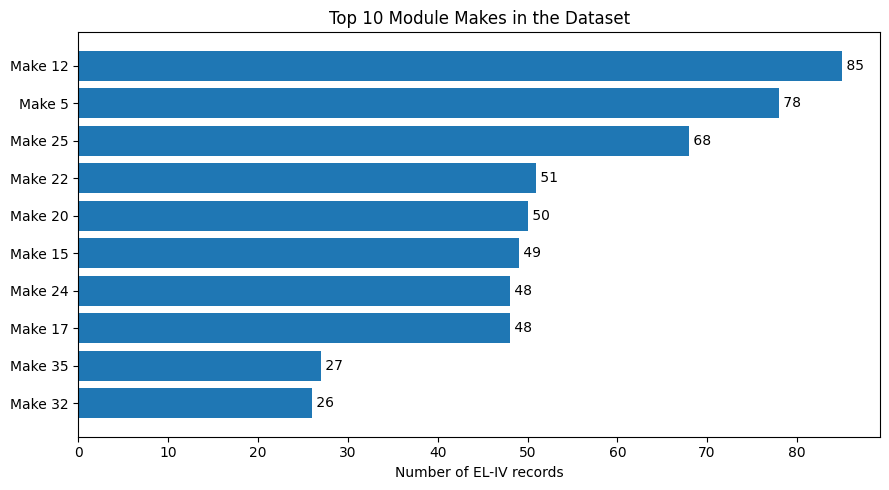

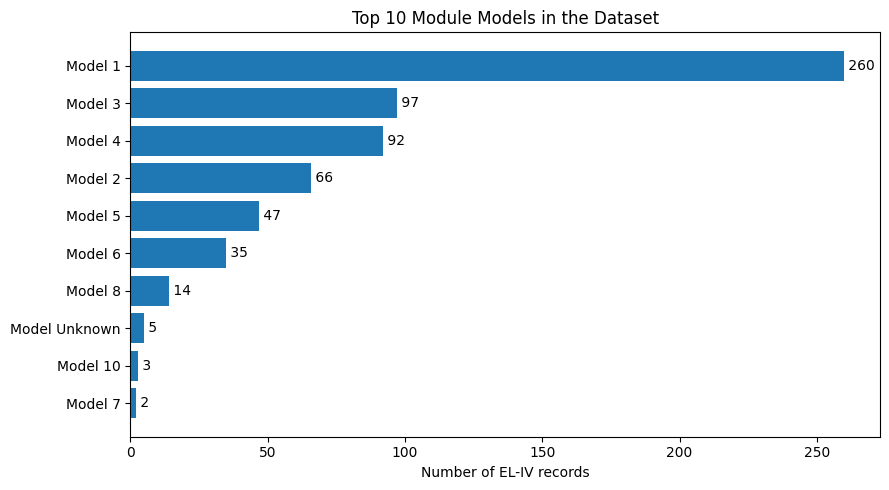

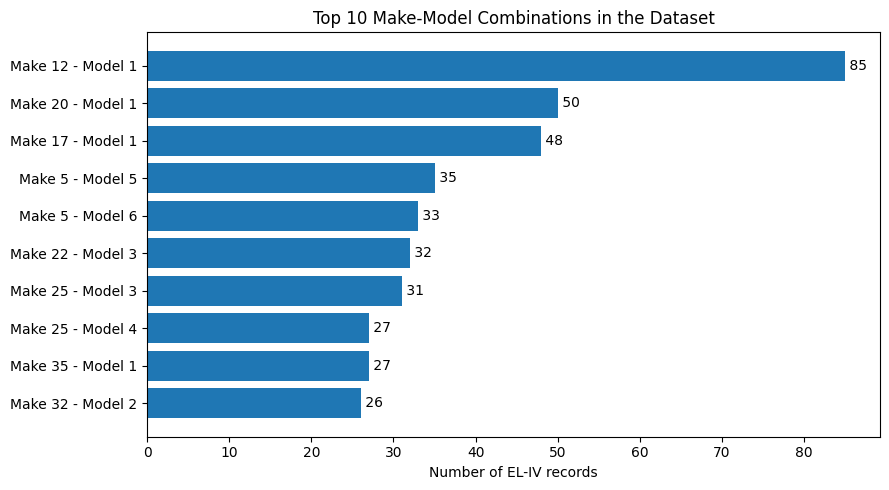

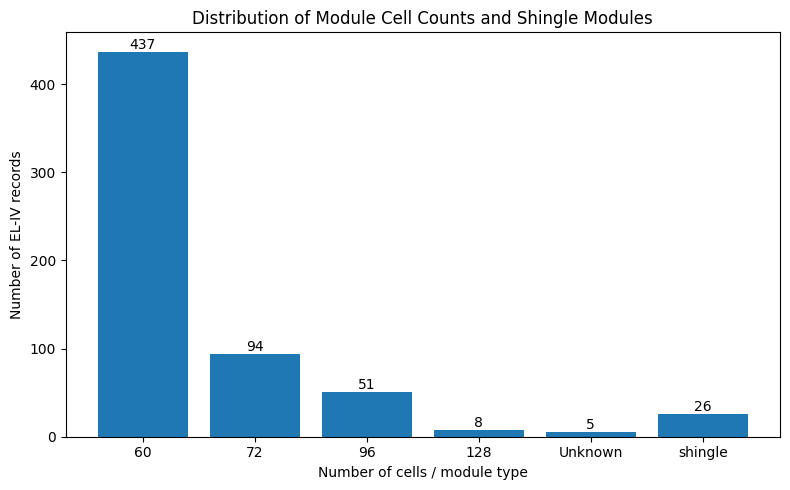

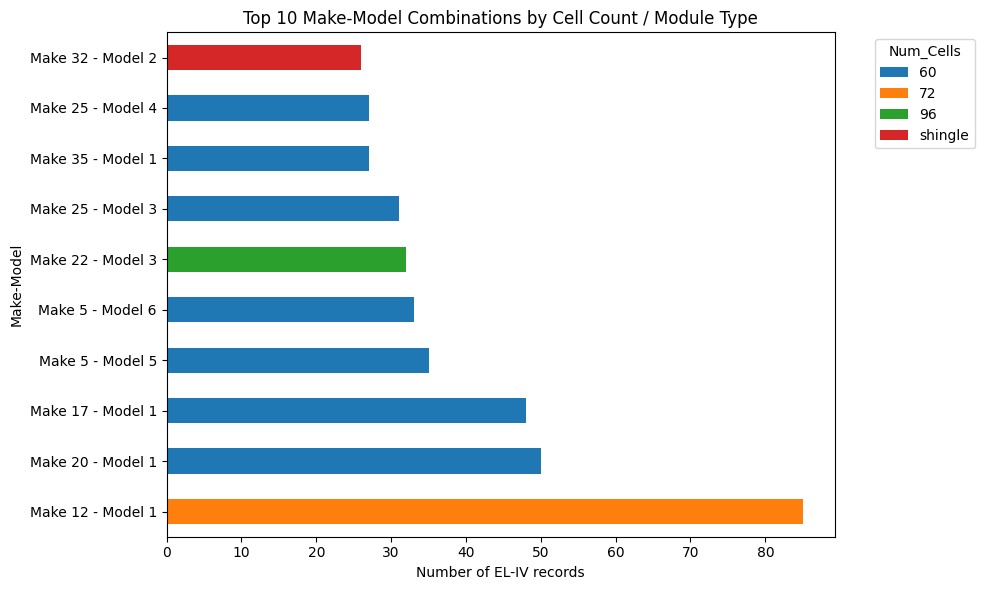

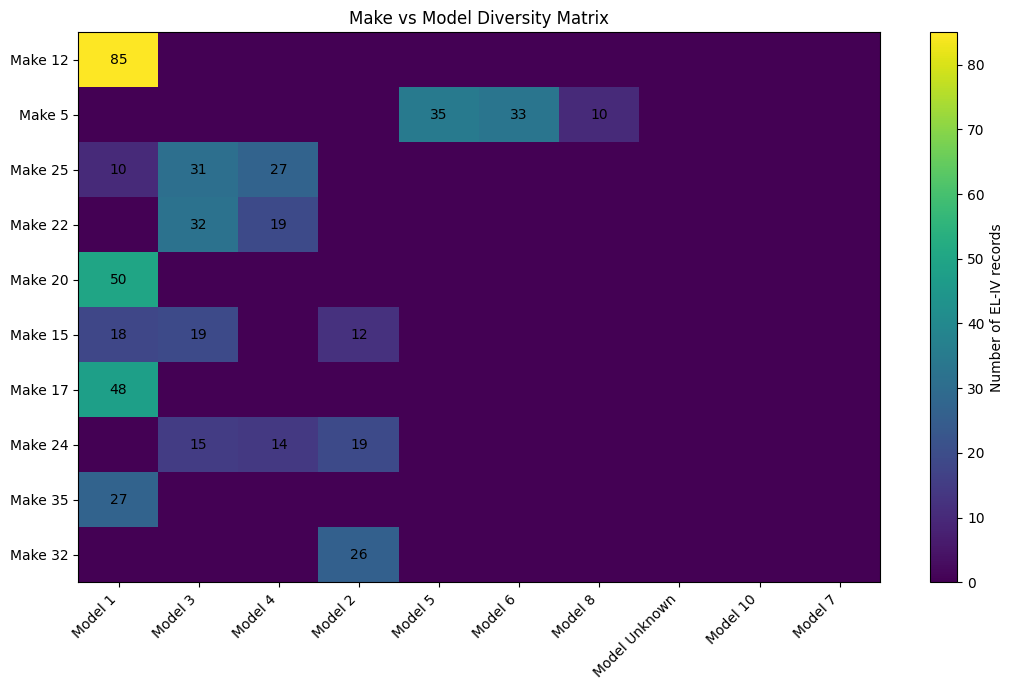

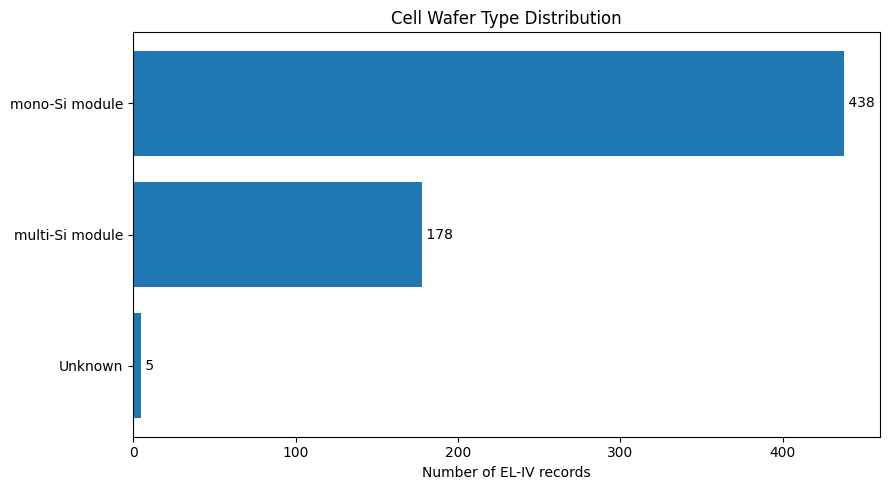

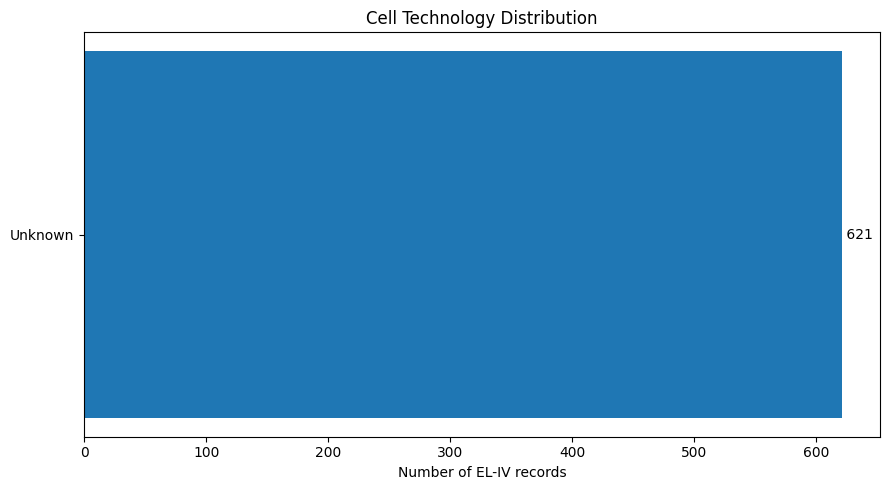

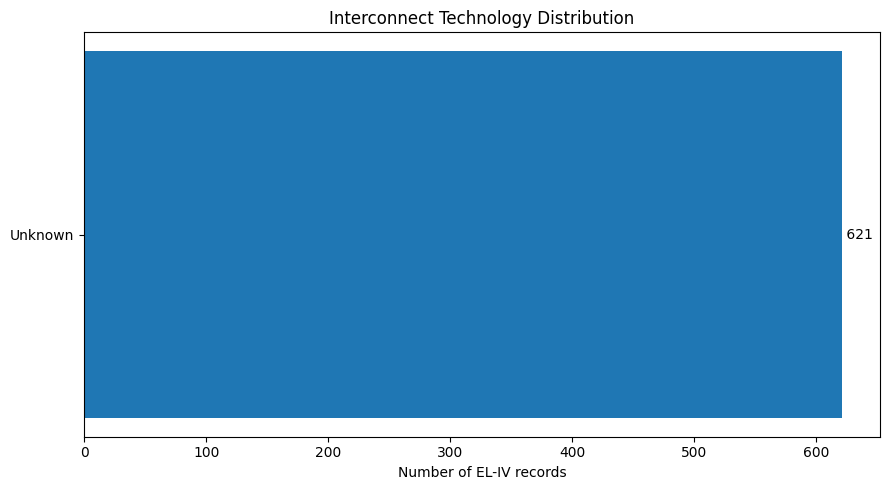

C:\Users\Ghozy Abror\AppData\Local\Temp\ipykernel_36036\1447427539.py:423: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=top_make_models_perf, vert=False)


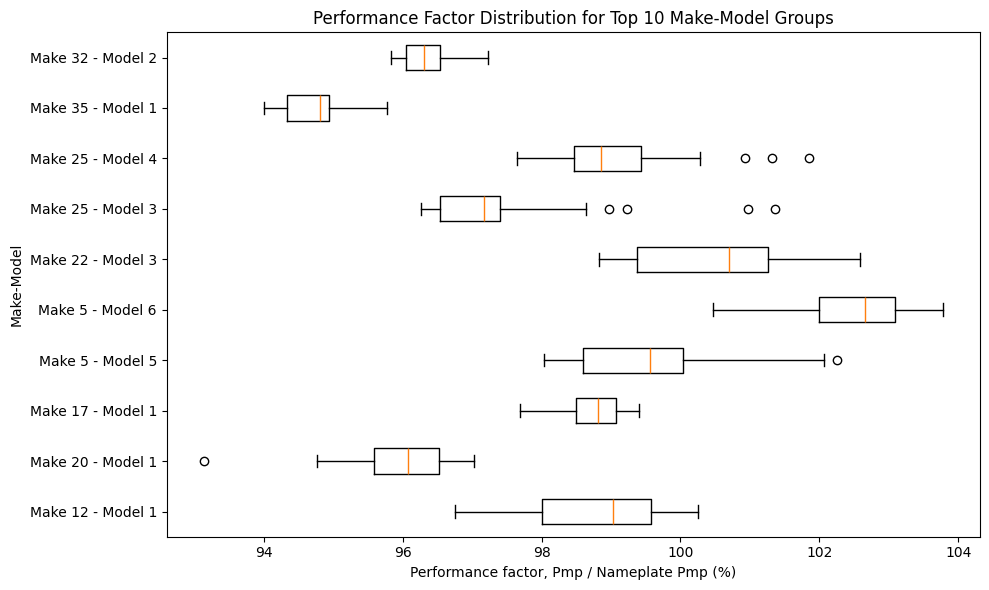

C:\Users\Ghozy Abror\AppData\Local\Temp\ipykernel_36036\1447427539.py:455: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=top_make_models_isc, vert=False)


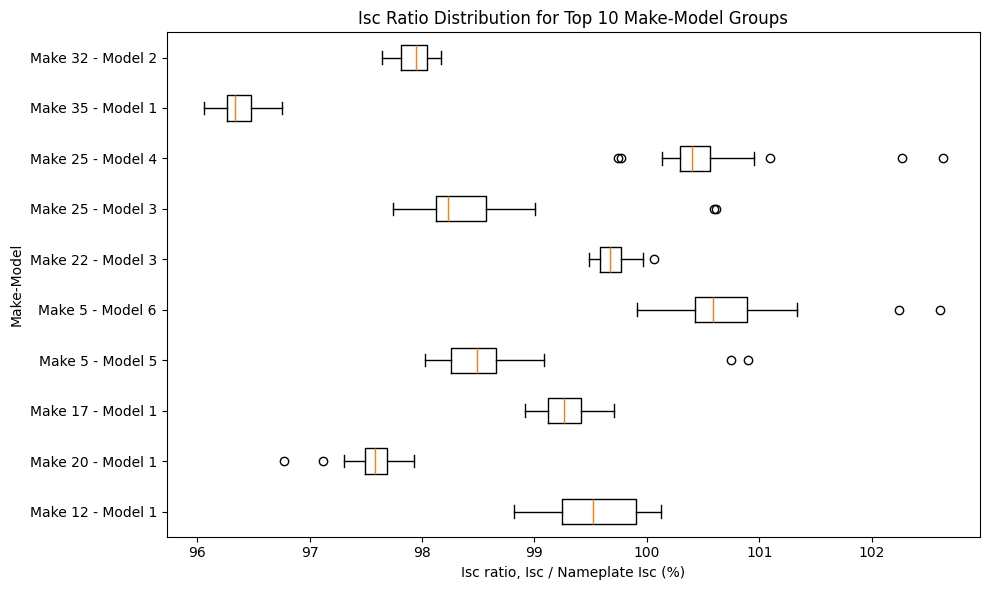

C:\Users\Ghozy Abror\AppData\Local\Temp\ipykernel_36036\1447427539.py:487: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=top_make_models_voc, vert=False)


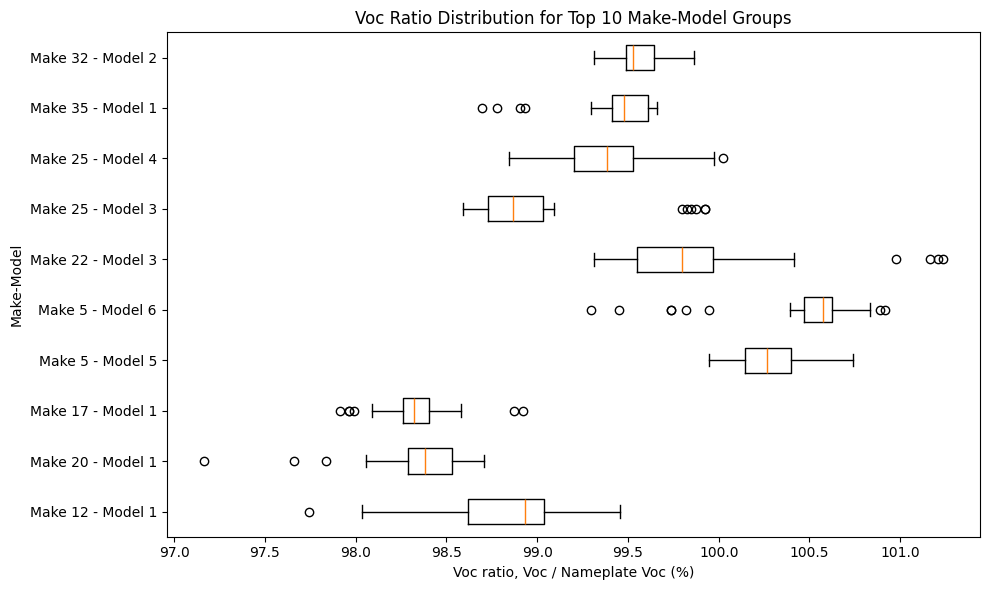

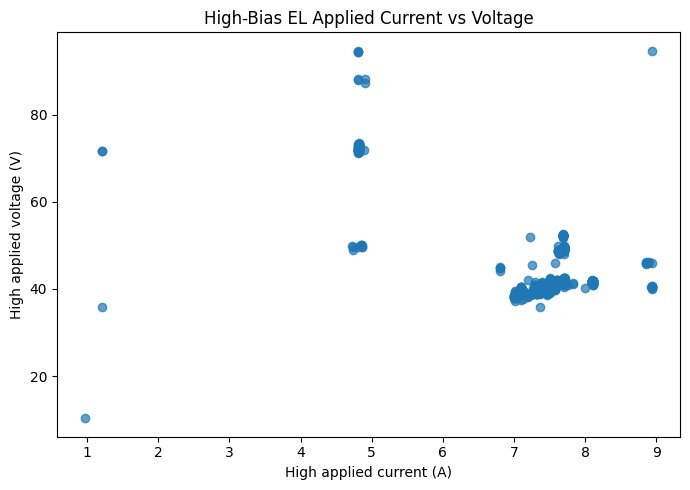


Done.
All plots saved in: C:\Users\Ghozy Abror\OneDrive - Institut Teknologi Bandung\Karirku\UNSW\Thesis\Coding\dataset_diversity_plots
Cleaned dataset saved as: C:\Users\Ghozy Abror\OneDrive - Institut Teknologi Bandung\Karirku\UNSW\Thesis\Coding\dataset_diversity_plots\cleaned_metadata_with_labels.csv


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# 0. User settings
# ============================================================

csv_path = "AnonDB_zub.csv"   # Change this to your CSV file name
out_dir = Path("dataset_diversity_plots")
out_dir.mkdir(exist_ok=True)


# ============================================================
# 1. Load dataset
# ============================================================

df = pd.read_csv(csv_path, sep=";", engine="python")

# Clean column names
df.columns = df.columns.astype(str).str.strip()

# Drop empty / unnamed first column if it exists
df = df.loc[:, ~df.columns.str.match(r"^Unnamed|^$", na=False)]

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


# ============================================================
# 2. Helper functions
# ============================================================

def clean_label(series, prefix):
    """
    Convert Make/Model values into readable labels.

    Examples:
    36.0 -> Make 36
    4.0  -> Model 4
    NaN  -> Make Unknown
    """
    def format_value(x):
        if pd.isna(x):
            return f"{prefix}Unknown"

        s = str(x).strip()

        if s == "" or s.lower() in ["nan", "none", "<na>"]:
            return f"{prefix}Unknown"

        try:
            value = float(s)
            if value.is_integer():
                return f"{prefix}{int(value)}"
            else:
                return f"{prefix}{value:g}"
        except ValueError:
            return f"{prefix}{s}"

    return series.apply(format_value)


def convert_numeric(col):
    """
    Safely convert column to numeric if it exists.
    """
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")


def save_plot(filename):
    """
    Save and show plot.
    """
    plt.tight_layout()
    plt.savefig(out_dir / filename, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


def plot_barh_counts(series, title, xlabel, filename, top_n=10):
    """
    Horizontal bar chart for top categories.
    """
    counts = series.fillna("Unknown").value_counts().head(top_n)
    counts = counts.sort_values(ascending=True)

    plt.figure(figsize=(9, 5))
    plt.barh(counts.index.astype(str), counts.values)
    plt.xlabel(xlabel)
    plt.title(title)

    for i, v in enumerate(counts.values):
        plt.text(v, i, f" {v}", va="center")

    save_plot(filename)


def plot_category_counts(column, title, filename, top_n=10):
    """
    Plot top categories if the column exists.
    """
    if column not in df.columns:
        print(f"Skipped {column}: column not found.")
        return

    plot_barh_counts(
        df[column].astype("string").fillna("Unknown"),
        title=title,
        xlabel="Number of EL-IV records",
        filename=filename,
        top_n=top_n
    )


# ============================================================
# 3. Clean Make, Model, Make-Model
# ============================================================

df["Make_Label"] = clean_label(df["Make"], "Make ")
df["Model_Label"] = clean_label(df["Model"], "Model ")
df["Make_Model"] = df["Make_Label"] + " - " + df["Model_Label"]


# ============================================================
# 4. Clean Num_Cells safely
#    Important: Num_Cells can contain values like 60, 72, 128,
#    but also text such as "shingle".
# ============================================================

raw_num_cells = df["Num_Cells"].astype("string").str.strip()

# Numeric version: 60, 72, 128 become numbers; "shingle" becomes NaN
df["Num_Cells_Numeric"] = pd.to_numeric(raw_num_cells, errors="coerce")

# Label version: keeps both numeric and text categories
df["Num_Cells_Label"] = raw_num_cells.fillna("Unknown")

# Convert labels like 60.0 into 60
numeric_mask = df["Num_Cells_Numeric"].notna()
df.loc[numeric_mask, "Num_Cells_Label"] = (
    df.loc[numeric_mask, "Num_Cells_Numeric"]
    .astype("Int64")
    .astype(str)
)

df["Num_Cells_Label"] = df["Num_Cells_Label"].replace({
    "": "Unknown",
    "<NA>": "Unknown",
    "nan": "Unknown",
    "None": "Unknown"
})


# ============================================================
# 5. Convert useful numeric columns
#    Do NOT include Num_Cells here because it can contain "shingle".
# ============================================================

numeric_cols = [
    "Module_Area_(cm2)",
    "Cell_Area_(cm2)",
    "Nameplate_Isc_(A)",
    "Nameplate_Voc_(V)",
    "Nameplate_Imp_(A)",
    "Nameplate_Vmp_(V)",
    "Nameplate_Pmp_(W)",
    "Isc_(A)",
    "Voc_(V)",
    "Imp_(A)",
    "Vmp_(V)",
    "Pmp_(W)",
    "FF_(percent)",
    "Measured_Temperature_(C)",
    "High_Applied_Current_(A)",
    "High_Applied_Voltage_(V)",
    "High_Sensor_Exposure_Time_(s)",
    "Low_Applied_Current_(A)",
    "Low_Applied_Voltage_(V)",
    "Low_Sensor_Exposure_Time_(s)",
    "High_Temperature_(C)",
    "Low_Temperature_(C)",
    "Working_Distance_(m)"
]

for col in numeric_cols:
    convert_numeric(col)


# ============================================================
# 6. Create useful derived columns
# ============================================================

if "Pmp_(W)" in df.columns and "Nameplate_Pmp_(W)" in df.columns:
    df["Performance_Factor_Percent"] = np.where(
        df["Nameplate_Pmp_(W)"] > 0,
        df["Pmp_(W)"] / df["Nameplate_Pmp_(W)"] * 100,
        np.nan
    )

if "Isc_(A)" in df.columns and "Nameplate_Isc_(A)" in df.columns:
    df["Isc_Ratio_Percent"] = np.where(
        df["Nameplate_Isc_(A)"] > 0,
        df["Isc_(A)"] / df["Nameplate_Isc_(A)"] * 100,
        np.nan
    )

if "Voc_(V)" in df.columns and "Nameplate_Voc_(V)" in df.columns:
    df["Voc_Ratio_Percent"] = np.where(
        df["Nameplate_Voc_(V)"] > 0,
        df["Voc_(V)"] / df["Nameplate_Voc_(V)"] * 100,
        np.nan
    )


# ============================================================
# 7. Dataset summary
# ============================================================

summary = {
    "Number of rows / EL-IV records": len(df),
    "Unique modules": df["Mod_ID"].nunique() if "Mod_ID" in df.columns else np.nan,
    "Unique makes": df["Make_Label"].nunique(),
    "Unique models": df["Model_Label"].nunique(),
    "Unique make-model combinations": df["Make_Model"].nunique(),
    "Unique Num_Cells categories": df["Num_Cells_Label"].nunique(),
}

summary_df = pd.DataFrame(summary.items(), columns=["Metric", "Value"])

print("\nDataset diversity summary:")
print(summary_df)

summary_df.to_csv(out_dir / "dataset_diversity_summary.csv", index=False)


# ============================================================
# 8. Plot 1: Top 10 Make
# ============================================================

plot_barh_counts(
    df["Make_Label"],
    title="Top 10 Module Makes in the Dataset",
    xlabel="Number of EL-IV records",
    filename="01_top_10_make.png",
    top_n=10
)


# ============================================================
# 9. Plot 2: Top 10 Model
# ============================================================

plot_barh_counts(
    df["Model_Label"],
    title="Top 10 Module Models in the Dataset",
    xlabel="Number of EL-IV records",
    filename="02_top_10_model.png",
    top_n=10
)


# ============================================================
# 10. Plot 3: Top 10 Make-Model combinations
# ============================================================

plot_barh_counts(
    df["Make_Model"],
    title="Top 10 Make-Model Combinations in the Dataset",
    xlabel="Number of EL-IV records",
    filename="03_top_10_make_model.png",
    top_n=10
)


# ============================================================
# 11. Plot 4: Num_Cells distribution
# ============================================================

counts = df["Num_Cells_Label"].value_counts()

plot_df = counts.reset_index()
plot_df.columns = ["Num_Cells_Label", "Count"]

# Sort numeric categories first, then text categories such as shingle
plot_df["Sort_Value"] = pd.to_numeric(plot_df["Num_Cells_Label"], errors="coerce")
plot_df = plot_df.sort_values(
    by=["Sort_Value", "Num_Cells_Label"],
    na_position="last"
)

plt.figure(figsize=(8, 5))
plt.bar(plot_df["Num_Cells_Label"], plot_df["Count"])
plt.xlabel("Number of cells / module type")
plt.ylabel("Number of EL-IV records")
plt.title("Distribution of Module Cell Counts and Shingle Modules")

for i, v in enumerate(plot_df["Count"]):
    plt.text(i, v, str(v), ha="center", va="bottom")

save_plot("04_num_cells_distribution.png")


# ============================================================
# 12. Plot 5: Top Make-Model stacked by Num_Cells
# ============================================================

top_make_models = df["Make_Model"].value_counts().head(10).index
df_top = df[df["Make_Model"].isin(top_make_models)].copy()

cell_table = pd.crosstab(
    df_top["Make_Model"],
    df_top["Num_Cells_Label"]
)

cell_table = cell_table.reindex(top_make_models, fill_value=0)

ax = cell_table.plot(
    kind="barh",
    stacked=True,
    figsize=(10, 6)
)

ax.set_xlabel("Number of EL-IV records")
ax.set_ylabel("Make-Model")
ax.set_title("Top 10 Make-Model Combinations by Cell Count / Module Type")
ax.legend(title="Num_Cells", bbox_to_anchor=(1.05, 1), loc="upper left")

save_plot("05_top_make_model_by_num_cells.png")


# ============================================================
# 13. Plot 6: Make vs Model count matrix
# ============================================================

top_makes = df["Make_Label"].value_counts().head(10).index
top_models = df["Model_Label"].value_counts().head(10).index

df_matrix = df[
    df["Make_Label"].isin(top_makes) &
    df["Model_Label"].isin(top_models)
].copy()

matrix = pd.crosstab(df_matrix["Make_Label"], df_matrix["Model_Label"])
matrix = matrix.reindex(index=top_makes, columns=top_models, fill_value=0)

plt.figure(figsize=(11, 7))
plt.imshow(matrix.values, aspect="auto")
plt.xticks(range(len(matrix.columns)), matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(matrix.index)), matrix.index)
plt.colorbar(label="Number of EL-IV records")
plt.title("Make vs Model Diversity Matrix")

for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        value = matrix.values[i, j]
        if value > 0:
            plt.text(j, i, str(value), ha="center", va="center")

save_plot("06_make_vs_model_matrix.png")


# ============================================================
# 14. Plot 7: Cell wafer type distribution
# ============================================================

plot_category_counts(
    column="Cell_Wafer_Type",
    title="Cell Wafer Type Distribution",
    filename="07_cell_wafer_type_distribution.png",
    top_n=10
)


# ============================================================
# 15. Plot 8: Cell technology distribution
# ============================================================

plot_category_counts(
    column="Cell_Tech",
    title="Cell Technology Distribution",
    filename="08_cell_technology_distribution.png",
    top_n=10
)


# ============================================================
# 16. Plot 9: Interconnect technology distribution
# ============================================================

plot_category_counts(
    column="Interconnect_Tech",
    title="Interconnect Technology Distribution",
    filename="09_interconnect_technology_distribution.png",
    top_n=10
)


# ============================================================
# 17. Plot 10: Performance factor by top Make-Model
# ============================================================

if "Performance_Factor_Percent" in df.columns:
    df_perf = df.replace([np.inf, -np.inf], np.nan)
    df_perf = df_perf.dropna(subset=["Performance_Factor_Percent"])

    if len(df_perf) > 0:
        top_make_models_perf = df_perf["Make_Model"].value_counts().head(10).index

        data_to_plot = [
            df_perf.loc[
                df_perf["Make_Model"] == make_model,
                "Performance_Factor_Percent"
            ].values
            for make_model in top_make_models_perf
        ]

        plt.figure(figsize=(10, 6))
        plt.boxplot(data_to_plot, labels=top_make_models_perf, vert=False)
        plt.xlabel("Performance factor, Pmp / Nameplate Pmp (%)")
        plt.ylabel("Make-Model")
        plt.title("Performance Factor Distribution for Top 10 Make-Model Groups")

        save_plot("10_performance_factor_by_make_model.png")
    else:
        print("Skipped performance factor plot: no valid performance factor values.")
else:
    print("Skipped performance factor plot: required columns are missing.")


# ============================================================
# 18. Plot 11: Isc ratio by top Make-Model
# ============================================================

if "Isc_Ratio_Percent" in df.columns:
    df_isc = df.replace([np.inf, -np.inf], np.nan)
    df_isc = df_isc.dropna(subset=["Isc_Ratio_Percent"])

    if len(df_isc) > 0:
        top_make_models_isc = df_isc["Make_Model"].value_counts().head(10).index

        data_to_plot = [
            df_isc.loc[
                df_isc["Make_Model"] == make_model,
                "Isc_Ratio_Percent"
            ].values
            for make_model in top_make_models_isc
        ]

        plt.figure(figsize=(10, 6))
        plt.boxplot(data_to_plot, labels=top_make_models_isc, vert=False)
        plt.xlabel("Isc ratio, Isc / Nameplate Isc (%)")
        plt.ylabel("Make-Model")
        plt.title("Isc Ratio Distribution for Top 10 Make-Model Groups")

        save_plot("11_isc_ratio_by_make_model.png")
    else:
        print("Skipped Isc ratio plot: no valid values.")
else:
    print("Skipped Isc ratio plot: required columns are missing.")


# ============================================================
# 19. Plot 12: Voc ratio by top Make-Model
# ============================================================

if "Voc_Ratio_Percent" in df.columns:
    df_voc = df.replace([np.inf, -np.inf], np.nan)
    df_voc = df_voc.dropna(subset=["Voc_Ratio_Percent"])

    if len(df_voc) > 0:
        top_make_models_voc = df_voc["Make_Model"].value_counts().head(10).index

        data_to_plot = [
            df_voc.loc[
                df_voc["Make_Model"] == make_model,
                "Voc_Ratio_Percent"
            ].values
            for make_model in top_make_models_voc
        ]

        plt.figure(figsize=(10, 6))
        plt.boxplot(data_to_plot, labels=top_make_models_voc, vert=False)
        plt.xlabel("Voc ratio, Voc / Nameplate Voc (%)")
        plt.ylabel("Make-Model")
        plt.title("Voc Ratio Distribution for Top 10 Make-Model Groups")

        save_plot("12_voc_ratio_by_make_model.png")
    else:
        print("Skipped Voc ratio plot: no valid values.")
else:
    print("Skipped Voc ratio plot: required columns are missing.")


# ============================================================
# 20. Plot 13: High applied current vs high applied voltage
# ============================================================

if (
    "High_Applied_Current_(A)" in df.columns and
    "High_Applied_Voltage_(V)" in df.columns
):
    df_hv = df.dropna(
        subset=["High_Applied_Current_(A)", "High_Applied_Voltage_(V)"]
    )

    if len(df_hv) > 0:
        plt.figure(figsize=(7, 5))
        plt.scatter(
            df_hv["High_Applied_Current_(A)"],
            df_hv["High_Applied_Voltage_(V)"],
            alpha=0.7
        )
        plt.xlabel("High applied current (A)")
        plt.ylabel("High applied voltage (V)")
        plt.title("High-Bias EL Applied Current vs Voltage")

        save_plot("13_high_bias_current_vs_voltage.png")
    else:
        print("Skipped high-bias current-voltage plot: no valid values.")
else:
    print("Skipped high-bias current-voltage plot: required columns are missing.")


# ============================================================
# 21. Save cleaned dataset
# ============================================================

cleaned_path = out_dir / "cleaned_metadata_with_labels.csv"
df.to_csv(cleaned_path, index=False)

print("\nDone.")
print(f"All plots saved in: {out_dir.resolve()}")
print(f"Cleaned dataset saved as: {cleaned_path.resolve()}")

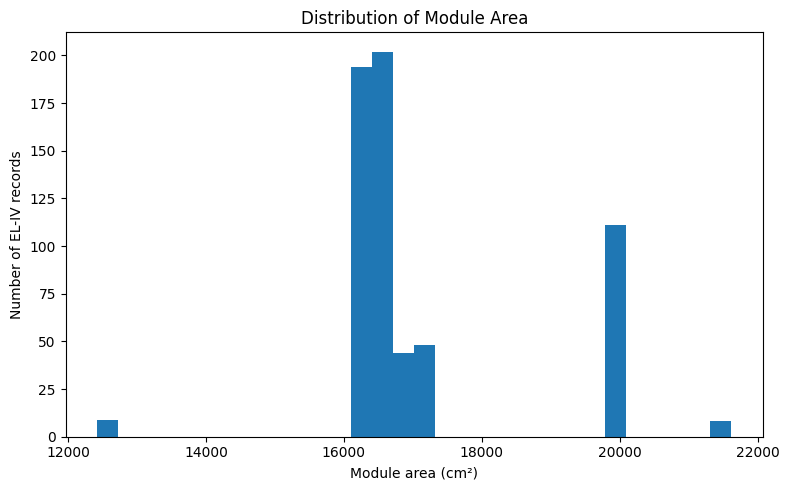

Skipped Distribution of Cell Area: no valid numeric data.


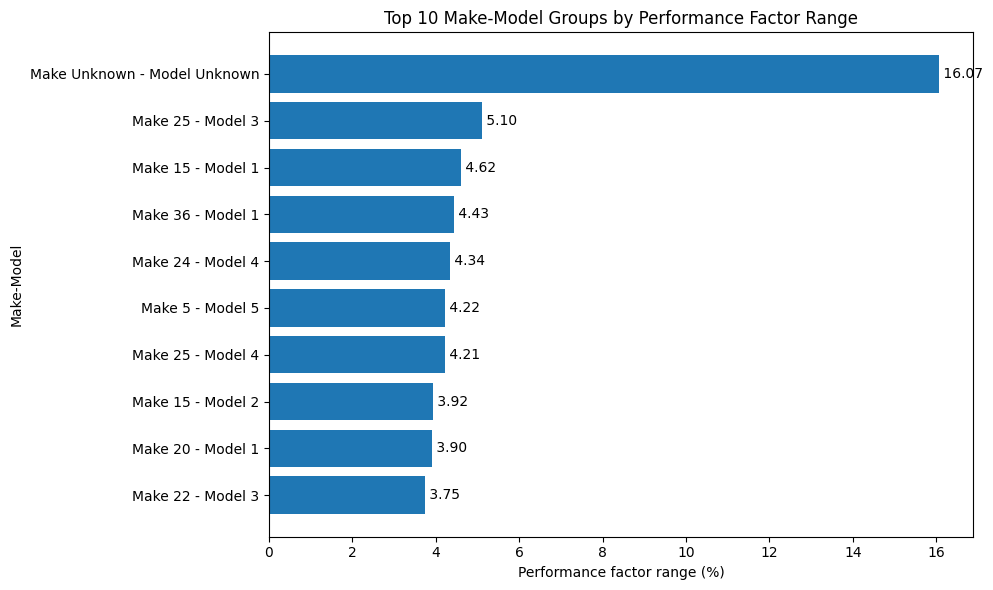

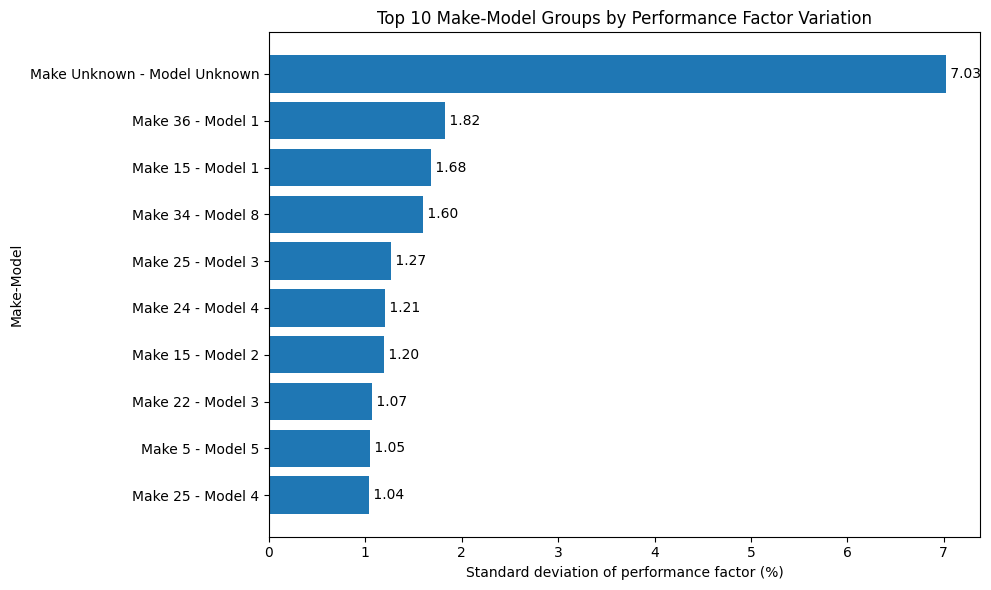

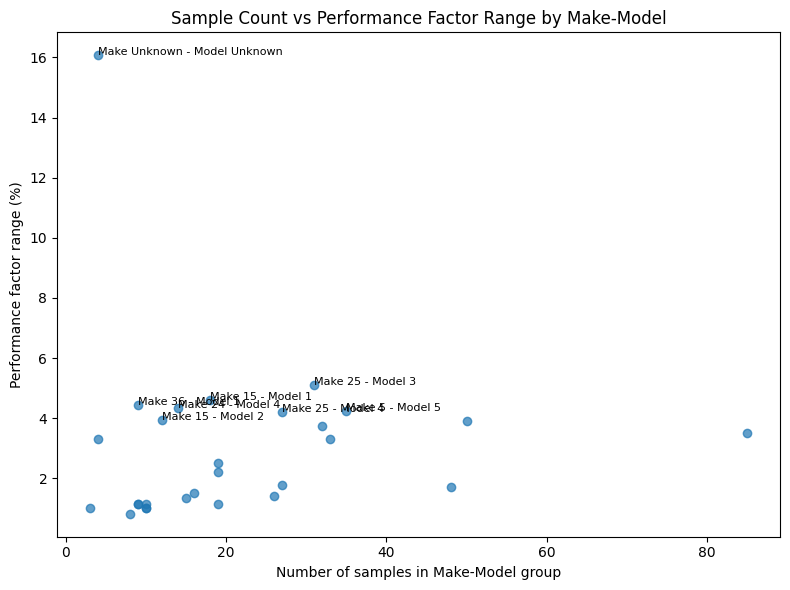

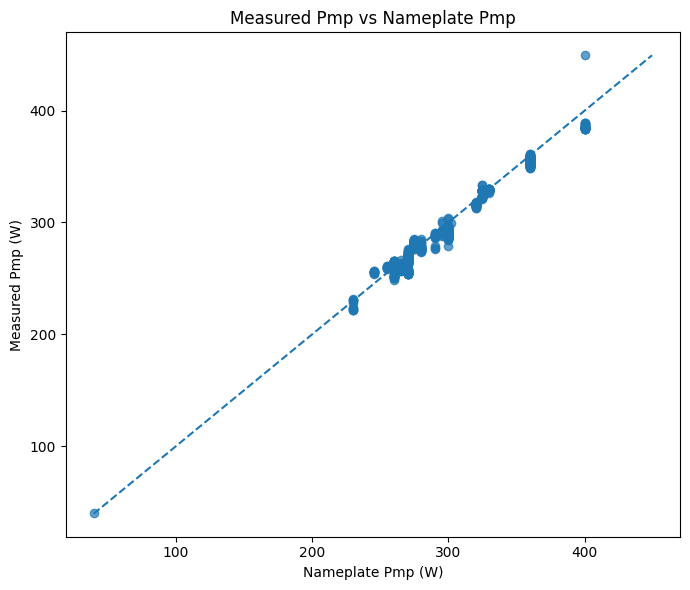

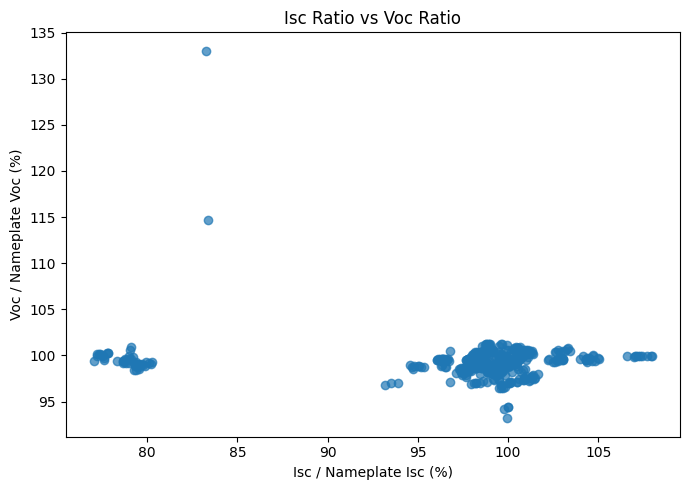

C:\Users\Ghozy Abror\AppData\Local\Temp\ipykernel_36036\503567436.py:82: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=labels, vert=False)


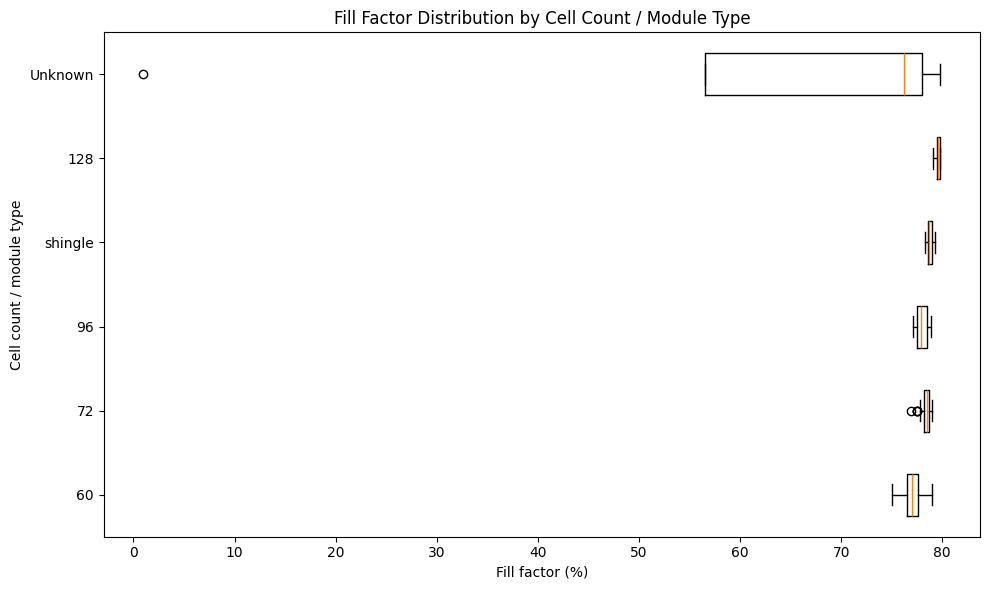

C:\Users\Ghozy Abror\AppData\Local\Temp\ipykernel_36036\503567436.py:82: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=labels, vert=False)


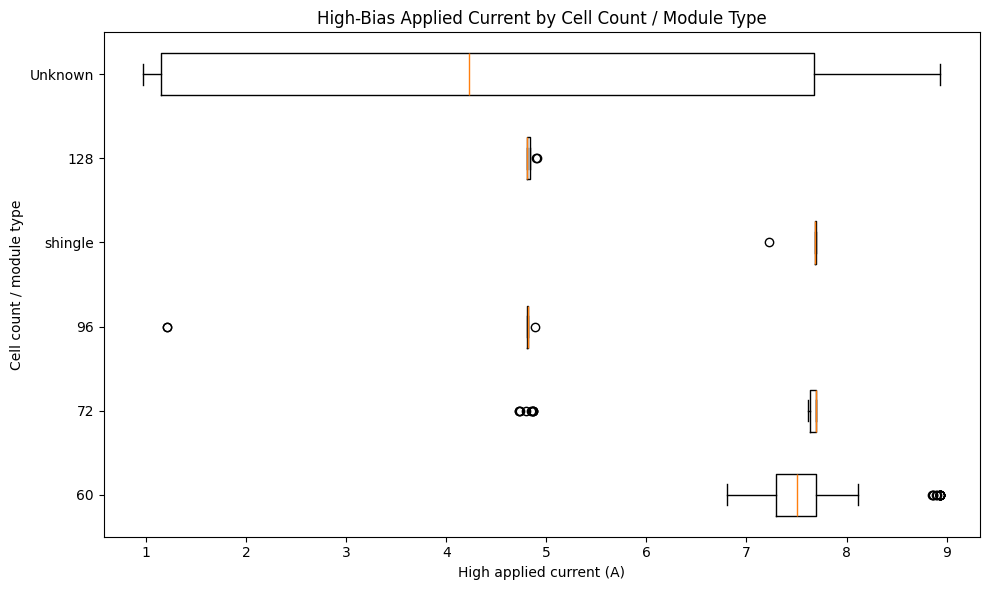

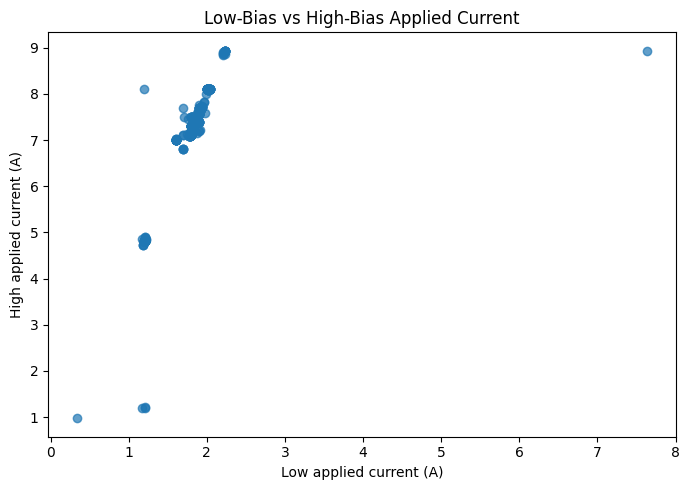

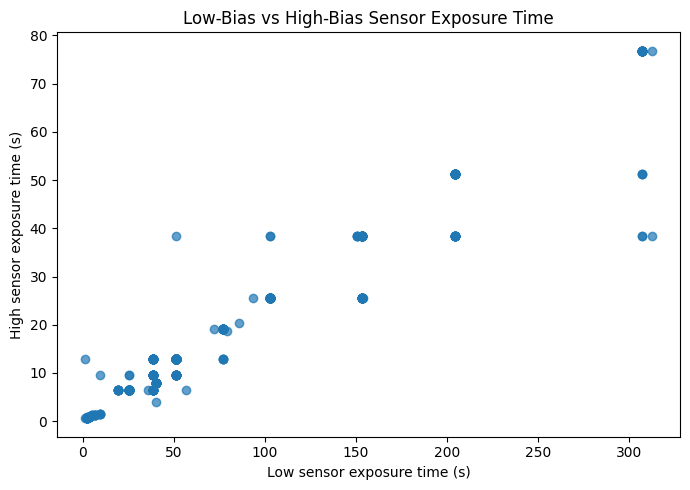


Additional 10 visualizations completed.
Saved in: C:\Users\Ghozy Abror\OneDrive - Institut Teknologi Bandung\Karirku\UNSW\Thesis\Coding\dataset_diversity_plots


In [39]:
# ============================================================
# ADDITIONAL 10 VISUALIZATIONS
# Run this after the previous full code
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

out_dir = Path("dataset_diversity_plots")
out_dir.mkdir(exist_ok=True)


# ============================================================
# Helper functions
# ============================================================

def save_plot(filename):
    plt.tight_layout()
    plt.savefig(out_dir / filename, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


def check_columns(required_cols):
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        print(f"Skipped because missing columns: {missing}")
        return False
    return True


def plot_histogram(column, title, xlabel, filename, bins=30):
    if column not in df.columns:
        print(f"Skipped {title}: column {column} not found.")
        return

    data = pd.to_numeric(df[column], errors="coerce").dropna()

    if len(data) == 0:
        print(f"Skipped {title}: no valid numeric data.")
        return

    plt.figure(figsize=(8, 5))
    plt.hist(data, bins=bins)
    plt.xlabel(xlabel)
    plt.ylabel("Number of EL-IV records")
    plt.title(title)

    save_plot(filename)


def plot_boxplot_by_category(category_col, value_col, title, xlabel, ylabel, filename, top_n=10):
    if not check_columns([category_col, value_col]):
        return

    temp = df[[category_col, value_col]].copy()
    temp[value_col] = pd.to_numeric(temp[value_col], errors="coerce")
    temp = temp.dropna(subset=[category_col, value_col])

    if len(temp) == 0:
        print(f"Skipped {title}: no valid data.")
        return

    top_categories = temp[category_col].value_counts().head(top_n).index

    data_to_plot = []
    labels = []

    for cat in top_categories:
        values = temp.loc[temp[category_col] == cat, value_col].dropna().values
        if len(values) > 0:
            data_to_plot.append(values)
            labels.append(cat)

    if len(data_to_plot) == 0:
        print(f"Skipped {title}: no valid groups.")
        return

    plt.figure(figsize=(10, 6))
    plt.boxplot(data_to_plot, labels=labels, vert=False)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)

    save_plot(filename)


def plot_scatter(x_col, y_col, title, xlabel, ylabel, filename):
    if not check_columns([x_col, y_col]):
        return

    temp = df[[x_col, y_col]].copy()
    temp[x_col] = pd.to_numeric(temp[x_col], errors="coerce")
    temp[y_col] = pd.to_numeric(temp[y_col], errors="coerce")
    temp = temp.dropna(subset=[x_col, y_col])

    if len(temp) == 0:
        print(f"Skipped {title}: no valid data.")
        return

    plt.figure(figsize=(7, 5))
    plt.scatter(temp[x_col], temp[y_col], alpha=0.7)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)

    save_plot(filename)


# ============================================================
# Make sure important derived columns exist
# ============================================================

if "Performance_Factor_Percent" not in df.columns:
    if "Pmp_(W)" in df.columns and "Nameplate_Pmp_(W)" in df.columns:
        df["Performance_Factor_Percent"] = np.where(
            pd.to_numeric(df["Nameplate_Pmp_(W)"], errors="coerce") > 0,
            pd.to_numeric(df["Pmp_(W)"], errors="coerce") /
            pd.to_numeric(df["Nameplate_Pmp_(W)"], errors="coerce") * 100,
            np.nan
        )

if "Isc_Ratio_Percent" not in df.columns:
    if "Isc_(A)" in df.columns and "Nameplate_Isc_(A)" in df.columns:
        df["Isc_Ratio_Percent"] = np.where(
            pd.to_numeric(df["Nameplate_Isc_(A)"], errors="coerce") > 0,
            pd.to_numeric(df["Isc_(A)"], errors="coerce") /
            pd.to_numeric(df["Nameplate_Isc_(A)"], errors="coerce") * 100,
            np.nan
        )

if "Voc_Ratio_Percent" not in df.columns:
    if "Voc_(V)" in df.columns and "Nameplate_Voc_(V)" in df.columns:
        df["Voc_Ratio_Percent"] = np.where(
            pd.to_numeric(df["Nameplate_Voc_(V)"], errors="coerce") > 0,
            pd.to_numeric(df["Voc_(V)"], errors="coerce") /
            pd.to_numeric(df["Nameplate_Voc_(V)"], errors="coerce") * 100,
            np.nan
        )


# ============================================================
# 14. Module area distribution
# ============================================================

plot_histogram(
    column="Module_Area_(cm2)",
    title="Distribution of Module Area",
    xlabel="Module area (cm²)",
    filename="14_module_area_distribution.png",
    bins=30
)


# ============================================================
# 15. Cell area distribution
# ============================================================

plot_histogram(
    column="Cell_Area_(cm2)",
    title="Distribution of Cell Area",
    xlabel="Cell area (cm²)",
    filename="15_cell_area_distribution.png",
    bins=30
)


# ============================================================
# 16. Performance factor range by Make-Model
#     Very useful for checking manufacturer memorisation risk
# ============================================================

if check_columns(["Make_Model", "Performance_Factor_Percent"]):
    temp = df[["Make_Model", "Performance_Factor_Percent"]].copy()
    temp["Performance_Factor_Percent"] = pd.to_numeric(
        temp["Performance_Factor_Percent"],
        errors="coerce"
    )
    temp = temp.dropna()

    if len(temp) > 0:
        spread = temp.groupby("Make_Model")["Performance_Factor_Percent"].agg(
            count="count",
            minimum="min",
            maximum="max",
            mean="mean",
            std="std"
        )

        spread["range"] = spread["maximum"] - spread["minimum"]

        # Use groups with at least 3 samples
        spread = spread[spread["count"] >= 3]

        if len(spread) > 0:
            top_spread = spread.sort_values("range", ascending=False).head(10)
            top_spread = top_spread.sort_values("range", ascending=True)

            plt.figure(figsize=(10, 6))
            plt.barh(top_spread.index, top_spread["range"])
            plt.xlabel("Performance factor range (%)")
            plt.ylabel("Make-Model")
            plt.title("Top 10 Make-Model Groups by Performance Factor Range")

            for i, v in enumerate(top_spread["range"]):
                plt.text(v, i, f" {v:.2f}", va="center")

            save_plot("16_performance_factor_range_by_make_model.png")
        else:
            print("Skipped performance factor range plot: no group has at least 3 samples.")
    else:
        print("Skipped performance factor range plot: no valid performance factor data.")


# ============================================================
# 17. Performance factor standard deviation by Make-Model
# ============================================================

if check_columns(["Make_Model", "Performance_Factor_Percent"]):
    temp = df[["Make_Model", "Performance_Factor_Percent"]].copy()
    temp["Performance_Factor_Percent"] = pd.to_numeric(
        temp["Performance_Factor_Percent"],
        errors="coerce"
    )
    temp = temp.dropna()

    if len(temp) > 0:
        std_table = temp.groupby("Make_Model")["Performance_Factor_Percent"].agg(
            count="count",
            std="std"
        )

        std_table = std_table[std_table["count"] >= 3]
        std_table = std_table.dropna(subset=["std"])

        if len(std_table) > 0:
            top_std = std_table.sort_values("std", ascending=False).head(10)
            top_std = top_std.sort_values("std", ascending=True)

            plt.figure(figsize=(10, 6))
            plt.barh(top_std.index, top_std["std"])
            plt.xlabel("Standard deviation of performance factor (%)")
            plt.ylabel("Make-Model")
            plt.title("Top 10 Make-Model Groups by Performance Factor Variation")

            for i, v in enumerate(top_std["std"]):
                plt.text(v, i, f" {v:.2f}", va="center")

            save_plot("17_performance_factor_std_by_make_model.png")
        else:
            print("Skipped performance factor std plot: not enough grouped data.")
    else:
        print("Skipped performance factor std plot: no valid performance factor data.")


# ============================================================
# 18. Sample count vs performance factor range
#     Useful to choose a make/model for generalisation test
# ============================================================

if check_columns(["Make_Model", "Performance_Factor_Percent"]):
    temp = df[["Make_Model", "Performance_Factor_Percent"]].copy()
    temp["Performance_Factor_Percent"] = pd.to_numeric(
        temp["Performance_Factor_Percent"],
        errors="coerce"
    )
    temp = temp.dropna()

    if len(temp) > 0:
        group_table = temp.groupby("Make_Model")["Performance_Factor_Percent"].agg(
            count="count",
            minimum="min",
            maximum="max"
        )

        group_table["range"] = group_table["maximum"] - group_table["minimum"]
        group_table = group_table[group_table["count"] >= 3]

        if len(group_table) > 0:
            plt.figure(figsize=(8, 6))
            plt.scatter(group_table["count"], group_table["range"], alpha=0.7)
            plt.xlabel("Number of samples in Make-Model group")
            plt.ylabel("Performance factor range (%)")
            plt.title("Sample Count vs Performance Factor Range by Make-Model")

            # Annotate top 8 groups by range
            annotate_table = group_table.sort_values("range", ascending=False).head(8)

            for label, row in annotate_table.iterrows():
                plt.text(row["count"], row["range"], label, fontsize=8)

            save_plot("18_sample_count_vs_performance_factor_range.png")
        else:
            print("Skipped sample count vs range plot: not enough grouped data.")


# ============================================================
# 19. Measured Pmp vs Nameplate Pmp
#     Useful to show module degradation/performance relative to rating
# ============================================================

if check_columns(["Nameplate_Pmp_(W)", "Pmp_(W)"]):
    temp = df[["Nameplate_Pmp_(W)", "Pmp_(W)"]].copy()
    temp["Nameplate_Pmp_(W)"] = pd.to_numeric(temp["Nameplate_Pmp_(W)"], errors="coerce")
    temp["Pmp_(W)"] = pd.to_numeric(temp["Pmp_(W)"], errors="coerce")
    temp = temp.dropna()

    if len(temp) > 0:
        plt.figure(figsize=(7, 6))
        plt.scatter(temp["Nameplate_Pmp_(W)"], temp["Pmp_(W)"], alpha=0.7)

        min_val = min(temp["Nameplate_Pmp_(W)"].min(), temp["Pmp_(W)"].min())
        max_val = max(temp["Nameplate_Pmp_(W)"].max(), temp["Pmp_(W)"].max())
        plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

        plt.xlabel("Nameplate Pmp (W)")
        plt.ylabel("Measured Pmp (W)")
        plt.title("Measured Pmp vs Nameplate Pmp")

        save_plot("19_measured_pmp_vs_nameplate_pmp.png")
    else:
        print("Skipped Pmp scatter plot: no valid data.")


# ============================================================
# 20. Isc ratio vs Voc ratio
#     Useful to see whether degradation is more current-related or voltage-related
# ============================================================

plot_scatter(
    x_col="Isc_Ratio_Percent",
    y_col="Voc_Ratio_Percent",
    title="Isc Ratio vs Voc Ratio",
    xlabel="Isc / Nameplate Isc (%)",
    ylabel="Voc / Nameplate Voc (%)",
    filename="20_isc_ratio_vs_voc_ratio.png"
)


# ============================================================
# 21. FF distribution by Num_Cells / shingle type
# ============================================================

plot_boxplot_by_category(
    category_col="Num_Cells_Label",
    value_col="FF_(percent)",
    title="Fill Factor Distribution by Cell Count / Module Type",
    xlabel="Fill factor (%)",
    ylabel="Cell count / module type",
    filename="21_ff_distribution_by_num_cells.png",
    top_n=10
)


# ============================================================
# 22. High applied current distribution by Num_Cells / shingle type
# ============================================================

plot_boxplot_by_category(
    category_col="Num_Cells_Label",
    value_col="High_Applied_Current_(A)",
    title="High-Bias Applied Current by Cell Count / Module Type",
    xlabel="High applied current (A)",
    ylabel="Cell count / module type",
    filename="22_high_current_by_num_cells.png",
    top_n=10
)


# ============================================================
# 23. High applied current vs low applied current
# ============================================================

plot_scatter(
    x_col="Low_Applied_Current_(A)",
    y_col="High_Applied_Current_(A)",
    title="Low-Bias vs High-Bias Applied Current",
    xlabel="Low applied current (A)",
    ylabel="High applied current (A)",
    filename="23_low_vs_high_applied_current.png"
)


# ============================================================
# 24. High sensor exposure time vs low sensor exposure time
# ============================================================

plot_scatter(
    x_col="Low_Sensor_Exposure_Time_(s)",
    y_col="High_Sensor_Exposure_Time_(s)",
    title="Low-Bias vs High-Bias Sensor Exposure Time",
    xlabel="Low sensor exposure time (s)",
    ylabel="High sensor exposure time (s)",
    filename="24_low_vs_high_sensor_exposure_time.png"
)


print("\nAdditional 10 visualizations completed.")
print(f"Saved in: {out_dir.resolve()}")

Full statistics saved to: dataset_diversity_plots\voc_ratio_make_model_full_statistics.csv
Selected statistics saved to: dataset_diversity_plots\voc_ratio_make_model_selected_statistics.csv

Selected statistics:


,count,mean,median,min,max,std,q1,q3,range,iqr
Make_Model,,,,,,,,,,
Make 12 - Model 1,85,98.8225,98.9346,97.7439,99.4569,0.3439,98.6213,99.0391,1.7130,0.4178
Make 20 - Model 1,50,98.3664,98.3823,97.1628,98.7058,0.2670,98.2889,98.5316,1.5431,0.2427
Make 17 - Model 1,48,98.3277,98.3211,97.9167,98.9216,0.1930,98.2598,98.4069,1.0049,0.1471
Make 5 - Model 5,35,100.2797,100.2639,99.9472,100.7388,0.1991,100.1451,100.3958,0.7916,0.2507
Make 5 - Model 6,33,100.4447,100.5744,99.2950,100.9138,0.4061,100.4700,100.6266,1.6188,0.1567
Make 22 - Model 3,32,99.8999,99.7989,99.3103,101.2356,0.5390,99.5510,99.9713,1.9253,0.4203
Make 25 - Model 3,31,99.0199,98.8682,98.5915,99.9245,0.4417,98.7299,99.0317,1.3330,0.3018
Make 35 - Model 1,27,99.4213,99.4792,98.6979,99.6615,0.2713,99.4141,99.6094,0.9635,0.1953
Make 25 - Model 4,27,99.3879,99.3841,98.8453,100.0257,0.2824,99.2045,99.5253,1.1804,0.3208


C:\Users\Ghozy Abror\AppData\Local\Temp\ipykernel_36036\491252898.py:166: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


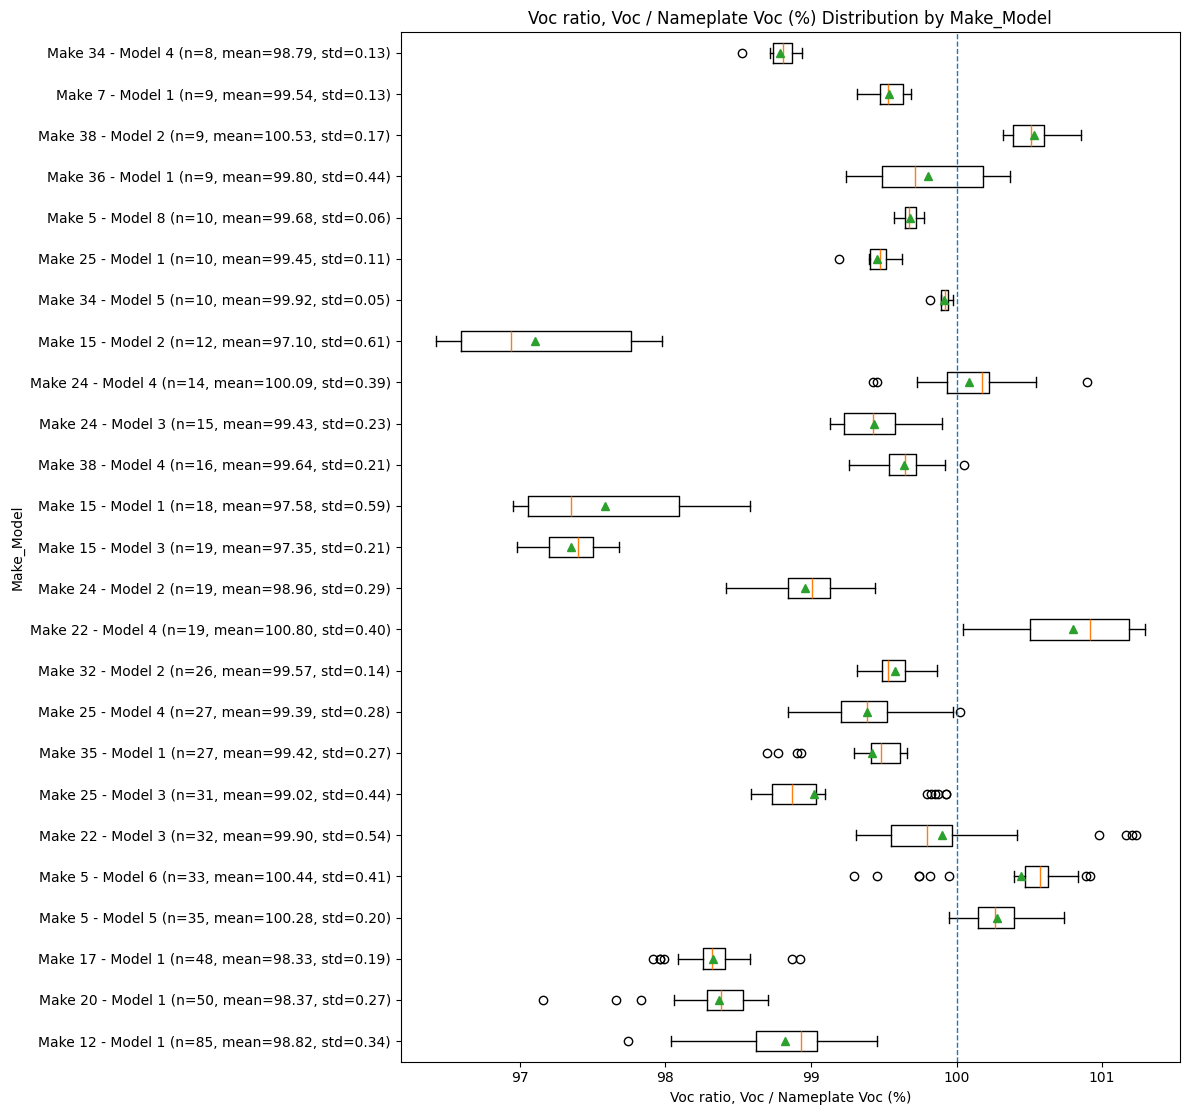

Extended boxplot saved to: dataset_diversity_plots\voc_ratio_make_model_extended_boxplot.png


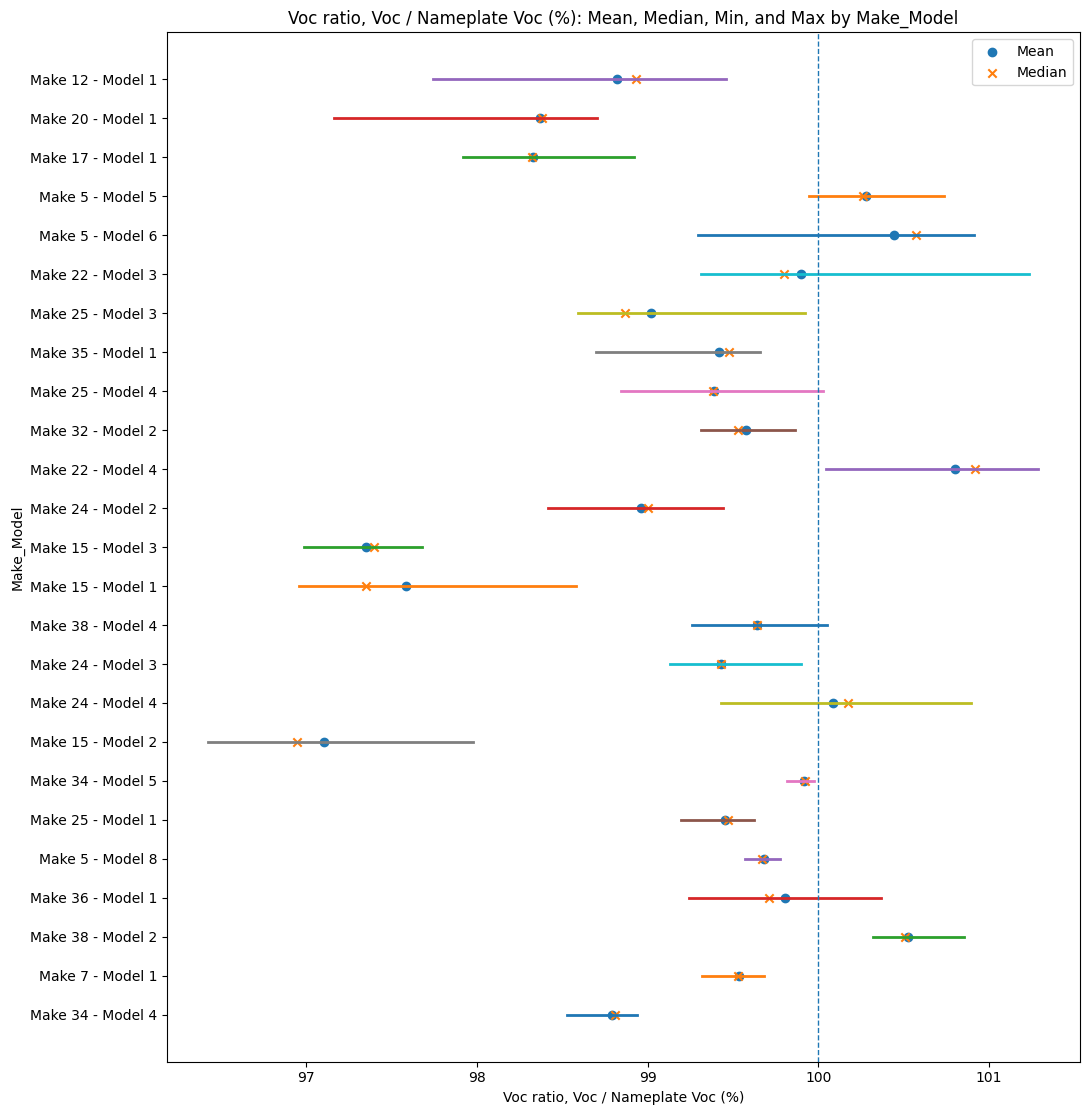

Mean/median/min/max plot saved to: dataset_diversity_plots\voc_ratio_make_model_mean_median_min_max.png


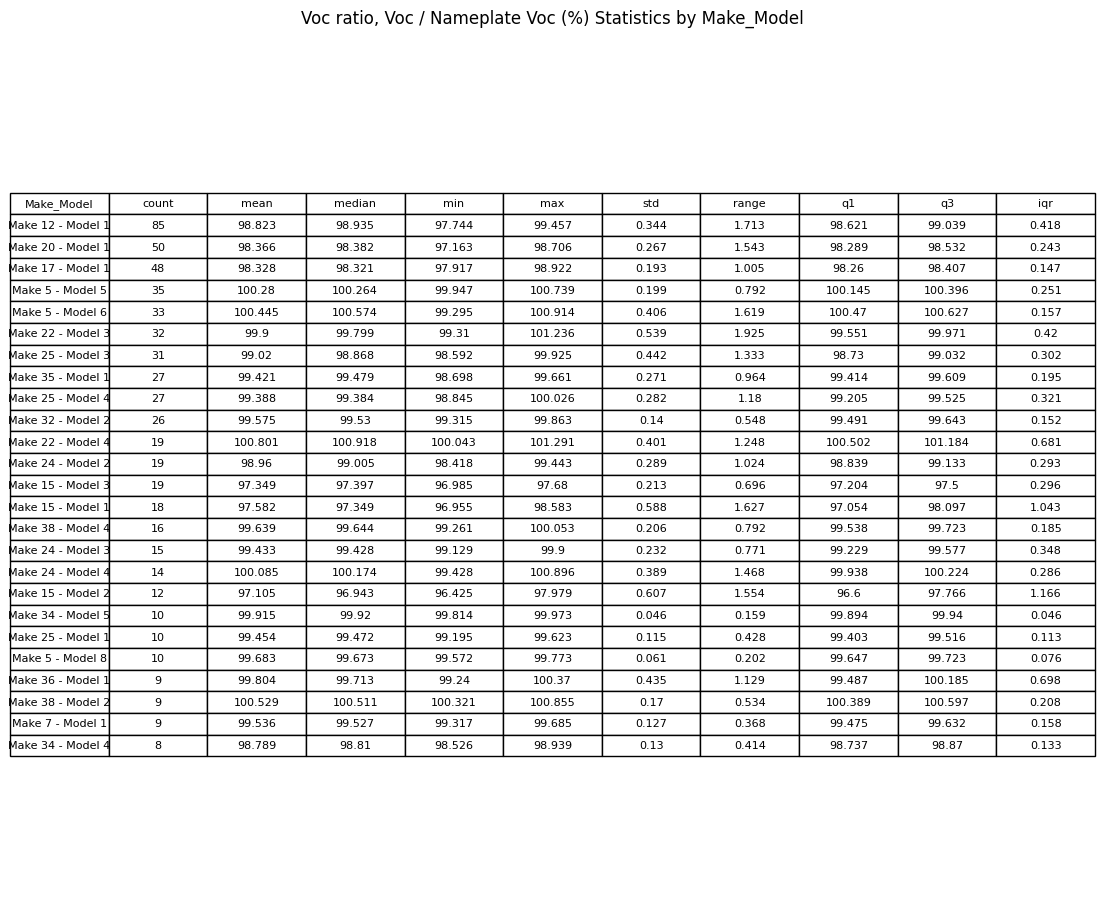

Statistics table image saved to: dataset_diversity_plots\voc_ratio_make_model_statistics_table.png


In [40]:
# ============================================================
# EXTENDED METRIC DISTRIBUTION REPORT
# Example: Voc Ratio by Make-Model
# Run this after the previous full code
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

out_dir = Path("dataset_diversity_plots")
out_dir.mkdir(exist_ok=True)


# ============================================================
# 1. Make sure Voc ratio exists
# ============================================================

if "Voc_Ratio_Percent" not in df.columns:
    if "Voc_(V)" in df.columns and "Nameplate_Voc_(V)" in df.columns:
        df["Voc_(V)"] = pd.to_numeric(df["Voc_(V)"], errors="coerce")
        df["Nameplate_Voc_(V)"] = pd.to_numeric(df["Nameplate_Voc_(V)"], errors="coerce")

        df["Voc_Ratio_Percent"] = np.where(
            df["Nameplate_Voc_(V)"] > 0,
            df["Voc_(V)"] / df["Nameplate_Voc_(V)"] * 100,
            np.nan
        )
    else:
        raise ValueError("Voc_(V) or Nameplate_Voc_(V) column is missing.")


# ============================================================
# 2. General function for metric report
# ============================================================

def make_metric_distribution_report(
    df,
    metric_col,
    metric_name,
    group_col="Make_Model",
    top_n=25,
    min_samples=3,
    sort_by="count",
    ascending=False,
    filename_prefix="metric"
):
    """
    Creates:
    1. Metric statistics CSV
    2. Extended boxplot
    3. Metric table as PNG
    4. Mean/median/min/max summary plot

    Parameters
    ----------
    metric_col : str
        Column name, e.g. "Voc_Ratio_Percent"
    metric_name : str
        Display name, e.g. "Voc ratio, Voc / Nameplate Voc (%)"
    group_col : str
        Usually "Make_Model"
    top_n : int or None
        Number of groups to plot. Use None to plot all groups.
    min_samples : int
        Minimum samples required for a group to be included.
    sort_by : str
        Options: "count", "mean", "median", "min", "max", "std", "range", "iqr"
    ascending : bool
        Sort direction.
    filename_prefix : str
        Prefix for saved files.
    """

    if group_col not in df.columns:
        raise ValueError(f"{group_col} column is missing.")

    if metric_col not in df.columns:
        raise ValueError(f"{metric_col} column is missing.")

    temp = df[[group_col, metric_col]].copy()
    temp[metric_col] = pd.to_numeric(temp[metric_col], errors="coerce")
    temp = temp.replace([np.inf, -np.inf], np.nan)
    temp = temp.dropna(subset=[group_col, metric_col])

    if len(temp) == 0:
        raise ValueError(f"No valid data found for {metric_col}.")

    # ------------------------------------------------------------
    # Calculate statistics
    # ------------------------------------------------------------

    stats = temp.groupby(group_col)[metric_col].agg(
        count="count",
        mean="mean",
        median="median",
        min="min",
        max="max",
        std="std",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75)
    )

    stats["range"] = stats["max"] - stats["min"]
    stats["iqr"] = stats["q3"] - stats["q1"]

    # Filter groups with enough samples
    stats = stats[stats["count"] >= min_samples].copy()

    if len(stats) == 0:
        raise ValueError(f"No groups have at least {min_samples} samples.")

    # Sort table
    if sort_by not in stats.columns:
        raise ValueError(f"sort_by must be one of: {stats.columns.tolist()}")

    stats = stats.sort_values(sort_by, ascending=ascending)

    # Select top N groups
    if top_n is not None:
        selected_stats = stats.head(top_n).copy()
    else:
        selected_stats = stats.copy()

    selected_groups = selected_stats.index.tolist()

    # Save full and selected statistics
    full_stats_path = out_dir / f"{filename_prefix}_full_statistics.csv"
    selected_stats_path = out_dir / f"{filename_prefix}_selected_statistics.csv"

    stats.to_csv(full_stats_path)
    selected_stats.to_csv(selected_stats_path)

    print(f"Full statistics saved to: {full_stats_path}")
    print(f"Selected statistics saved to: {selected_stats_path}")

    print("\nSelected statistics:")
    display(selected_stats.round(4))

    # ------------------------------------------------------------
    # Plot 1: Extended boxplot
    # ------------------------------------------------------------

    boxplot_data = []
    boxplot_labels = []

    for group in selected_groups:
        values = temp.loc[temp[group_col] == group, metric_col].dropna().values

        if len(values) > 0:
            boxplot_data.append(values)

            row = selected_stats.loc[group]
            label = (
                f"{group} "
                f"(n={int(row['count'])}, "
                f"mean={row['mean']:.2f}, "
                f"std={row['std']:.2f})"
            )
            boxplot_labels.append(label)

    fig_height = max(6, 0.45 * len(boxplot_labels))

    plt.figure(figsize=(12, fig_height))
    plt.boxplot(
        boxplot_data,
        labels=boxplot_labels,
        vert=False,
        showmeans=True
    )

    plt.axvline(100, linestyle="--", linewidth=1)
    plt.xlabel(metric_name)
    plt.ylabel(group_col)
    plt.title(f"{metric_name} Distribution by {group_col}")

    plt.tight_layout()
    boxplot_path = out_dir / f"{filename_prefix}_extended_boxplot.png"
    plt.savefig(boxplot_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Extended boxplot saved to: {boxplot_path}")

    # ------------------------------------------------------------
    # Plot 2: Mean, median, min, max summary plot
    # ------------------------------------------------------------

    plot_stats = selected_stats.iloc[::-1].copy()

    y_pos = np.arange(len(plot_stats))

    plt.figure(figsize=(11, max(6, 0.45 * len(plot_stats))))

    # Min-max line
    for i, (_, row) in enumerate(plot_stats.iterrows()):
        plt.plot([row["min"], row["max"]], [i, i], linewidth=2)

    # Mean points
    plt.scatter(plot_stats["mean"], y_pos, label="Mean", marker="o")

    # Median points
    plt.scatter(plot_stats["median"], y_pos, label="Median", marker="x")

    plt.axvline(100, linestyle="--", linewidth=1)
    plt.yticks(y_pos, plot_stats.index)
    plt.xlabel(metric_name)
    plt.ylabel(group_col)
    plt.title(f"{metric_name}: Mean, Median, Min, and Max by {group_col}")
    plt.legend()

    plt.tight_layout()
    summary_plot_path = out_dir / f"{filename_prefix}_mean_median_min_max.png"
    plt.savefig(summary_plot_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Mean/median/min/max plot saved to: {summary_plot_path}")

    # ------------------------------------------------------------
    # Plot 3: Statistics table as image
    # ------------------------------------------------------------

    table_df = selected_stats.copy()
    table_df = table_df.reset_index()

    # Round values for display
    numeric_cols = table_df.select_dtypes(include=[np.number]).columns
    table_df[numeric_cols] = table_df[numeric_cols].round(3)

    # Reorder columns
    preferred_cols = [
        group_col,
        "count",
        "mean",
        "median",
        "min",
        "max",
        "std",
        "range",
        "q1",
        "q3",
        "iqr"
    ]

    preferred_cols = [col for col in preferred_cols if col in table_df.columns]
    table_df = table_df[preferred_cols]

    fig_height = max(3, 0.38 * len(table_df) + 1.5)
    fig_width = 14

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis("off")

    table = ax.table(
        cellText=table_df.values,
        colLabels=table_df.columns,
        loc="center",
        cellLoc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1, 1.3)

    plt.title(f"{metric_name} Statistics by {group_col}", pad=20)

    table_path = out_dir / f"{filename_prefix}_statistics_table.png"
    plt.savefig(table_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Statistics table image saved to: {table_path}")

    return stats, selected_stats


# ============================================================
# 3. Create extended Voc ratio report
# ============================================================

voc_stats, selected_voc_stats = make_metric_distribution_report(
    df=df,
    metric_col="Voc_Ratio_Percent",
    metric_name="Voc ratio, Voc / Nameplate Voc (%)",
    group_col="Make_Model",
    top_n=25,          # change to 30 or None if you want more/all groups
    min_samples=3,     # only include groups with at least 3 records
    sort_by="count",   # options: count, mean, median, min, max, std, range, iqr
    ascending=False,
    filename_prefix="voc_ratio_make_model"
)

Full statistics saved to: dataset_diversity_plots\performance_factor_make_model_full_statistics.csv
Selected statistics saved to: dataset_diversity_plots\performance_factor_make_model_selected_statistics.csv

Selected statistics:


,count,mean,median,min,max,std,q1,q3,range,iqr
Make,,,,,,,,,,
12.0,85,98.8098,99.0278,96.7500,100.2500,0.9228,98.0000,99.5833,3.5000,1.5833
5.0,78,100.6026,100.2037,97.5000,103.7818,1.8993,98.7500,102.3182,6.2818,3.5682
25.0,68,98.2374,98.3833,96.2667,101.8571,1.3382,97.2000,98.8821,5.5905,1.6821
22.0,51,100.1106,99.8182,98.8308,102.5846,0.9312,99.4200,100.9538,3.7538,1.5338
20.0,50,95.9913,96.0833,93.1333,97.0333,0.6971,95.5833,96.5250,3.9000,0.9417
15.0,49,98.2140,98.2963,96.2692,100.8846,1.2782,97.1538,99.1481,4.6154,1.9943
17.0,48,98.7637,98.8125,97.6875,99.4062,0.4059,98.4922,99.0703,1.7188,0.5781
24.0,48,99.6745,99.4171,97.6949,102.0339,0.9494,99.0364,100.2053,4.3390,1.1689
35.0,27,94.7311,94.8148,94.0000,95.7778,0.4753,94.3333,94.9444,1.7778,0.6111


C:\Users\Ghozy Abror\AppData\Local\Temp\ipykernel_36036\491252898.py:166: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


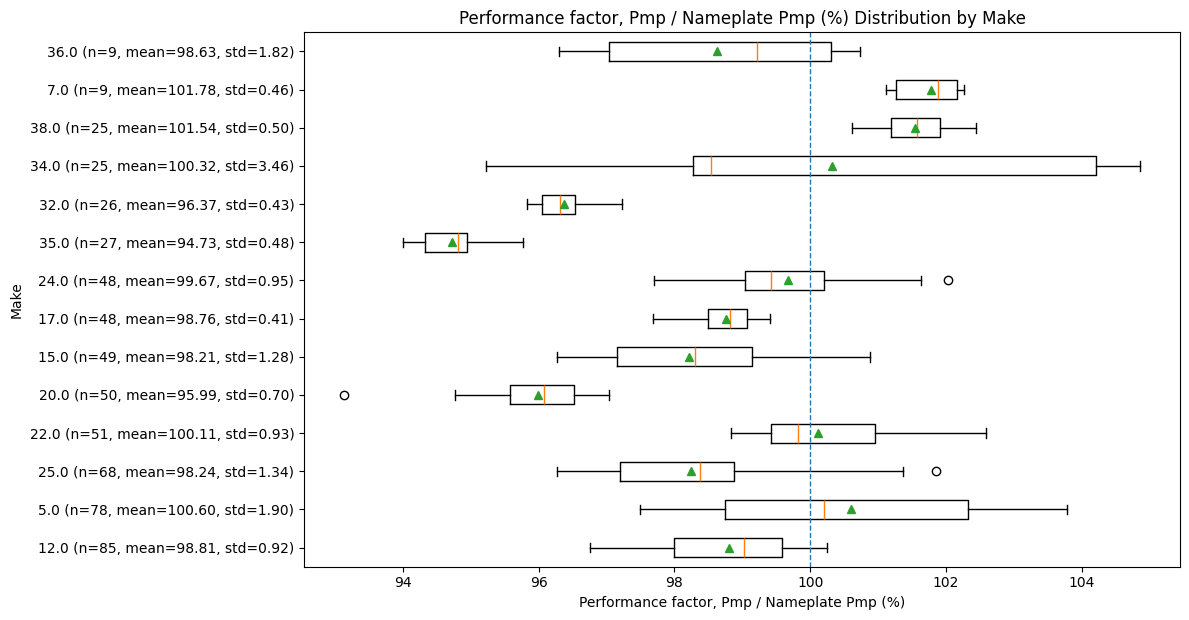

Extended boxplot saved to: dataset_diversity_plots\performance_factor_make_model_extended_boxplot.png


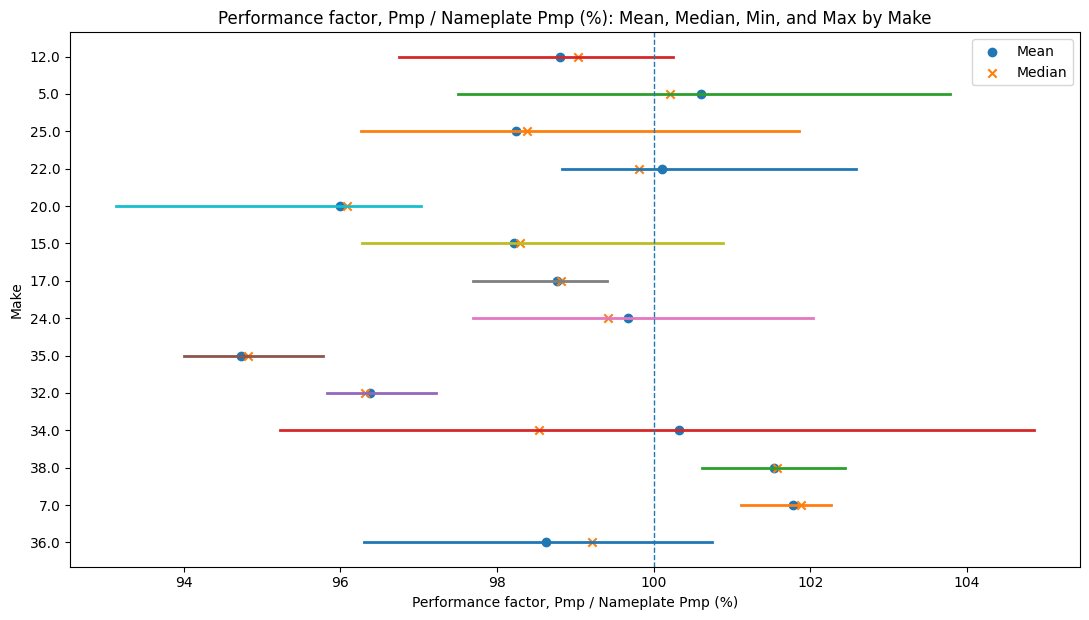

Mean/median/min/max plot saved to: dataset_diversity_plots\performance_factor_make_model_mean_median_min_max.png


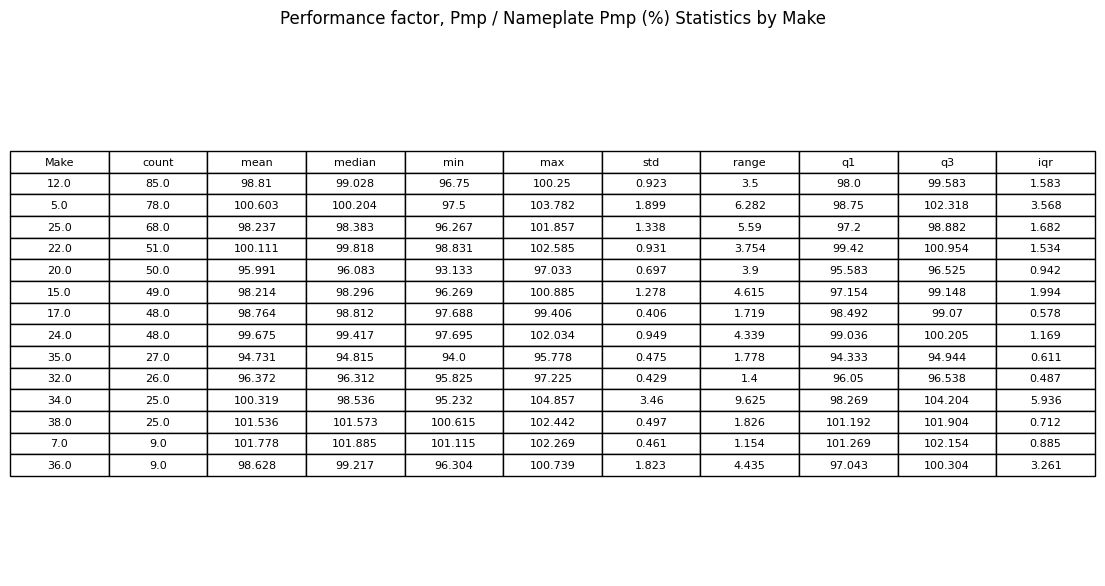

Statistics table image saved to: dataset_diversity_plots\performance_factor_make_model_statistics_table.png
Full statistics saved to: dataset_diversity_plots\voc_ratio_make_model_full_statistics.csv
Selected statistics saved to: dataset_diversity_plots\voc_ratio_make_model_selected_statistics.csv

Selected statistics:


,count,mean,median,min,max,std,q1,q3,range,iqr
Make,,,,,,,,,,
12.0,85,98.8225,98.9346,97.7439,99.4569,0.3439,98.6213,99.0391,1.7130,0.4178
5.0,78,100.2729,100.3430,99.2950,100.9138,0.3800,100.0528,100.5744,1.6188,0.5216
25.0,68,99.2299,99.2558,98.5915,100.0257,0.3975,98.8682,99.5008,1.4341,0.6326
22.0,51,100.2357,100.0144,99.3103,101.2912,0.6571,99.6839,100.9476,1.9809,1.2637
20.0,50,98.3664,98.3823,97.1628,98.7058,0.2670,98.2889,98.5316,1.5431,0.2427
15.0,49,97.3751,97.3491,96.4249,98.5827,0.5084,97.0103,97.5515,2.1578,0.5412
17.0,48,98.3277,98.3211,97.9167,98.9216,0.1930,98.2598,98.4069,1.0049,0.1471
24.0,48,99.4358,99.3657,98.4184,100.8955,0.5543,99.0561,99.8445,2.4772,0.7884
35.0,27,99.4213,99.4792,98.6979,99.6615,0.2713,99.4141,99.6094,0.9635,0.1953


C:\Users\Ghozy Abror\AppData\Local\Temp\ipykernel_36036\491252898.py:166: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


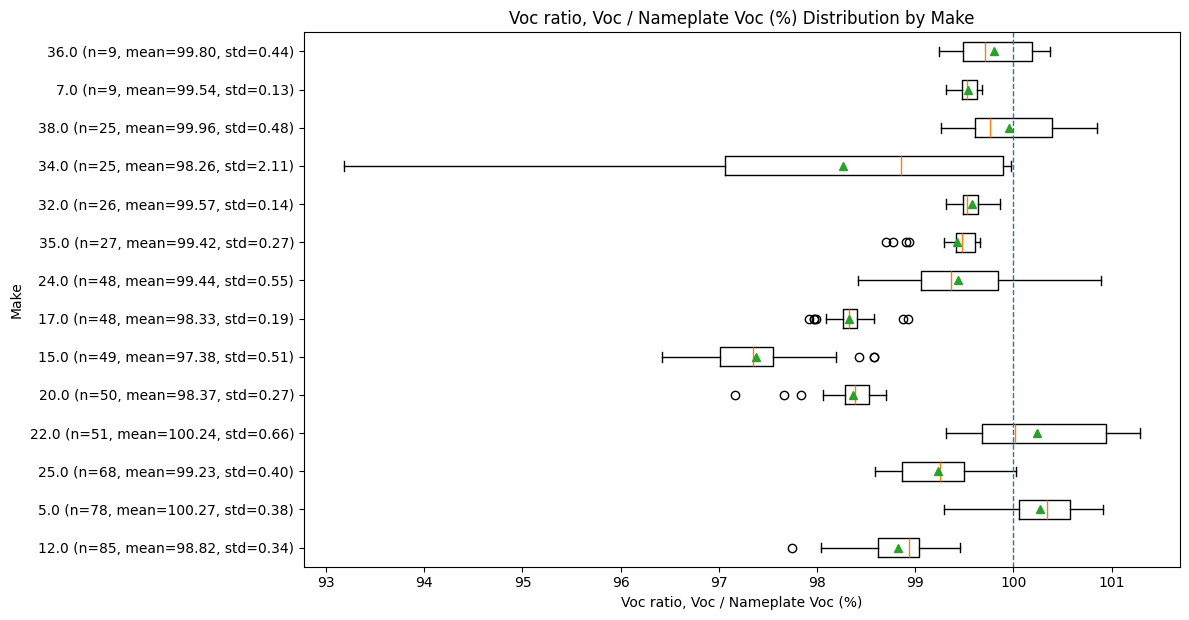

Extended boxplot saved to: dataset_diversity_plots\voc_ratio_make_model_extended_boxplot.png


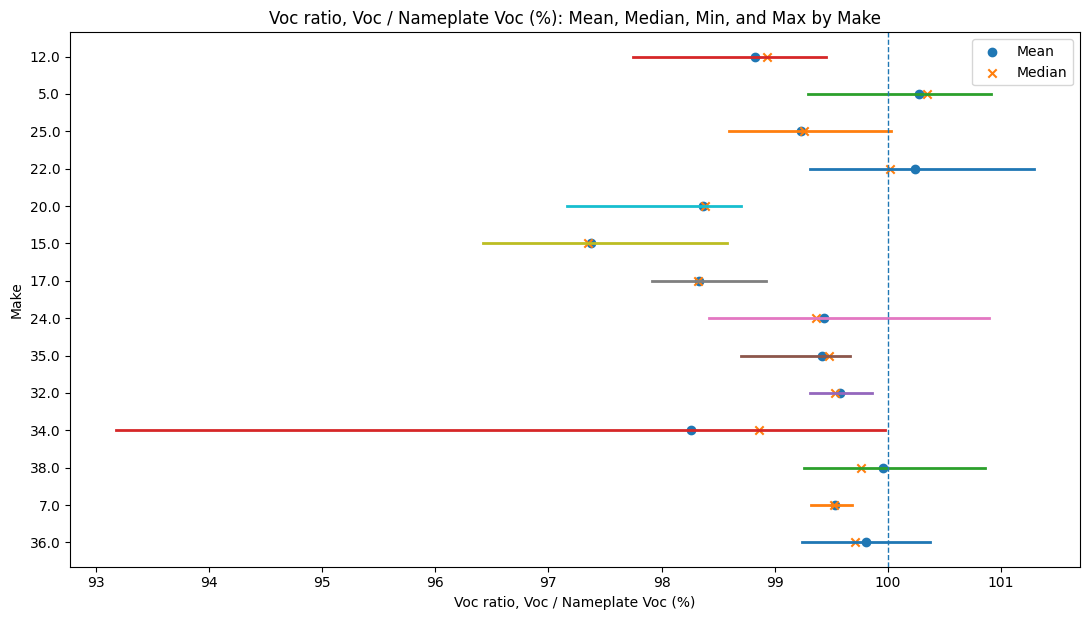

Mean/median/min/max plot saved to: dataset_diversity_plots\voc_ratio_make_model_mean_median_min_max.png


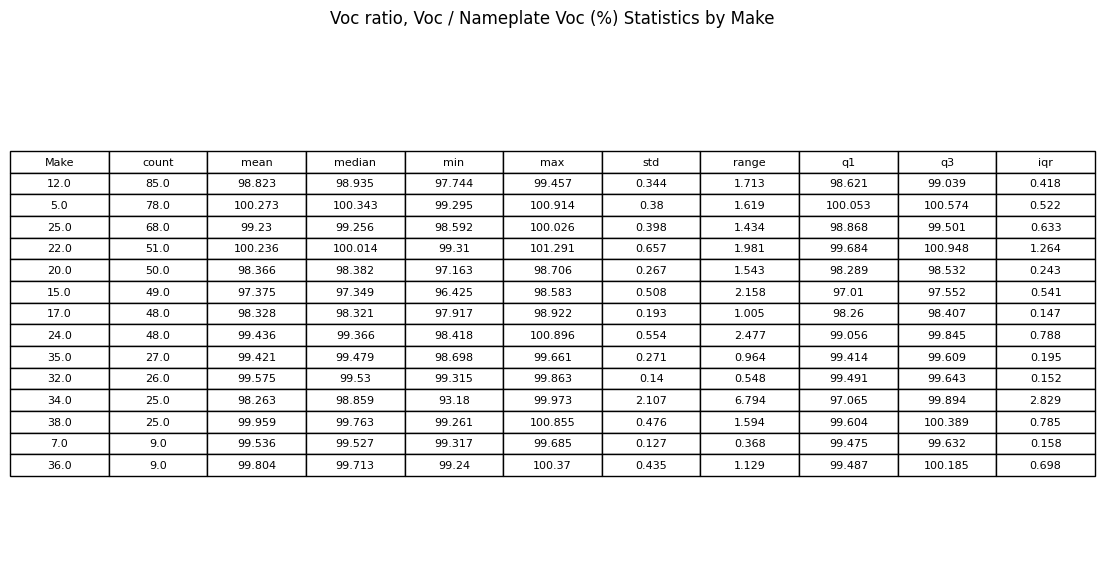

Statistics table image saved to: dataset_diversity_plots\voc_ratio_make_model_statistics_table.png


In [46]:
# Performance factor
perf_stats, selected_perf_stats = make_metric_distribution_report(
    df=df,
    metric_col="Performance_Factor_Percent",
    metric_name="Performance factor, Pmp / Nameplate Pmp (%)",
    group_col="Make",
    top_n=25,
    min_samples=3,
    sort_by="count",
    ascending=False,
    filename_prefix="performance_factor_make_model"
)

# Isc ratio
isc_stats, selected_isc_stats = make_metric_distribution_report(
    df=df,
    metric_col="Voc_Ratio_Percent",
    metric_name="Voc ratio, Voc / Nameplate Voc (%)",
    group_col="Make",
    top_n=25,
    min_samples=3,
    sort_by="count",
    ascending=False,
    filename_prefix="voc_ratio_make_model"
)

Valid samples for correlation: 602

Overall correlation:
Pearson correlation  : 0.4691
Spearman correlation : 0.5539
R-squared            : 0.2201


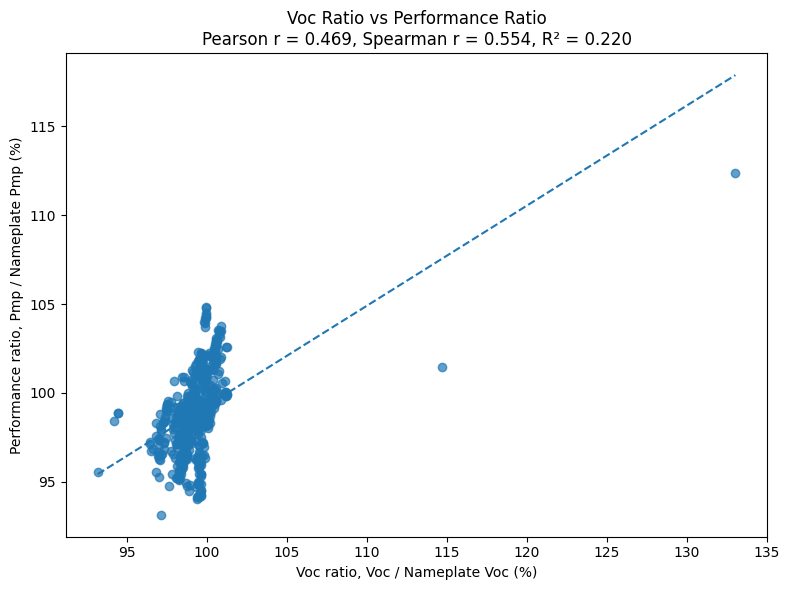


Correlation by Make-Model:


,Make_Model,count,voc_mean,voc_median,voc_min,voc_max,voc_std,performance_mean,performance_median,performance_min,performance_max,performance_std,pearson_corr,spearman_corr,r_squared,slope,intercept,abs_pearson_corr
3,Make 15 - Model 3,19,97.3494,97.3969,96.9845,97.6804,0.2129,98.5809,98.6296,97.3333,99.5556,0.7190,0.9619,0.9181,0.9252,3.2483,-217.6356,0.9619
1,Make 15 - Model 1,18,97.5824,97.3491,96.9554,98.5827,0.5880,97.8205,97.0769,96.2692,100.8846,1.6795,0.9299,0.8810,0.8646,2.6560,-161.3562,0.9299
12,Make 25 - Model 3,31,99.0199,98.8682,98.5915,99.9245,0.4417,97.4086,97.1667,96.2667,101.3667,1.2709,0.9208,0.9125,0.8479,2.6498,-164.9724,0.9208
7,Make 22 - Model 4,19,100.8012,100.9182,100.0430,101.2912,0.4012,99.6587,99.5758,98.8788,100.0303,0.3059,0.9204,0.8192,0.8470,0.7015,28.9421,0.9204
0,Make 12 - Model 1,85,98.8225,98.9346,97.7439,99.4569,0.3439,98.8098,99.0278,96.7500,100.2500,0.9228,0.9197,0.8770,0.8458,2.4678,-145.0612,0.9197
10,Make 24 - Model 4,14,100.0853,100.1741,99.4279,100.8955,0.3894,99.2446,99.0339,97.6949,102.0339,1.2075,0.9150,0.9117,0.8373,2.8374,-184.7419,0.9150
24,Make 7 - Model 1,9,99.5362,99.5274,99.3174,99.6850,0.1266,101.7778,101.8846,101.1154,102.2692,0.4610,0.9069,0.8782,0.8224,3.3028,-226.9717,0.9069
2,Make 15 - Model 2,12,97.1049,96.9430,96.4249,97.9793,0.6069,98.2233,98.2264,96.7170,100.6415,1.1991,0.8939,0.8947,0.7990,1.7662,-73.2838,0.8939
5,Make 20 - Model 1,50,98.3664,98.3823,97.1628,98.7058,0.2670,95.9913,96.0833,93.1333,97.0333,0.6971,0.8632,0.8309,0.7452,2.2540,-125.7298,0.8632
18,Make 36 - Model 1,9,99.8038,99.7125,99.2402,100.3696,0.4352,98.6280,99.2174,96.3043,100.7391,1.8234,0.8516,0.8333,0.7253,3.5678,-257.4499,0.8516



Group correlation table saved to: dataset_diversity_plots\25_voc_ratio_vs_performance_ratio_by_make_model.csv


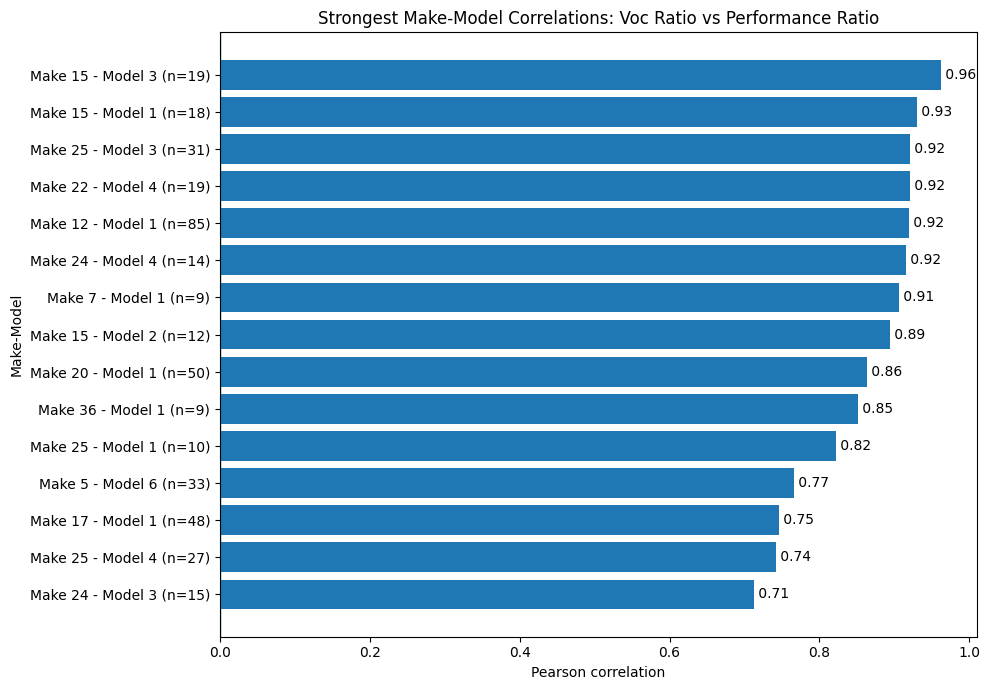

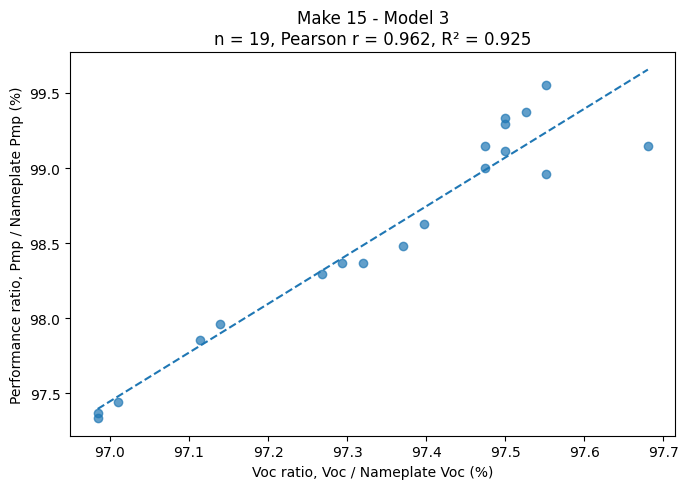

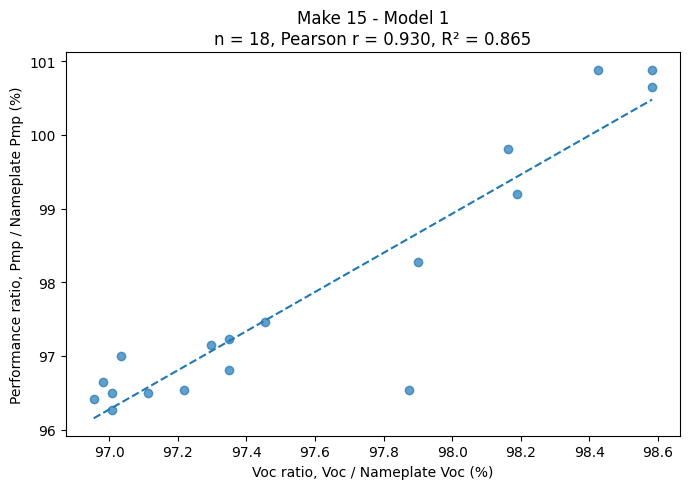

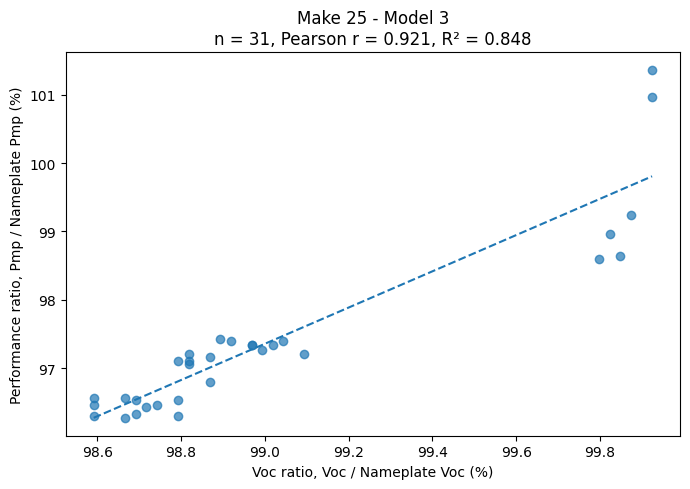

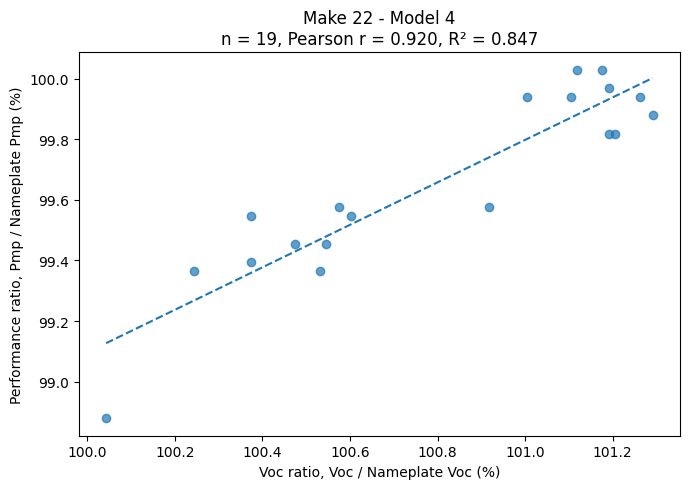

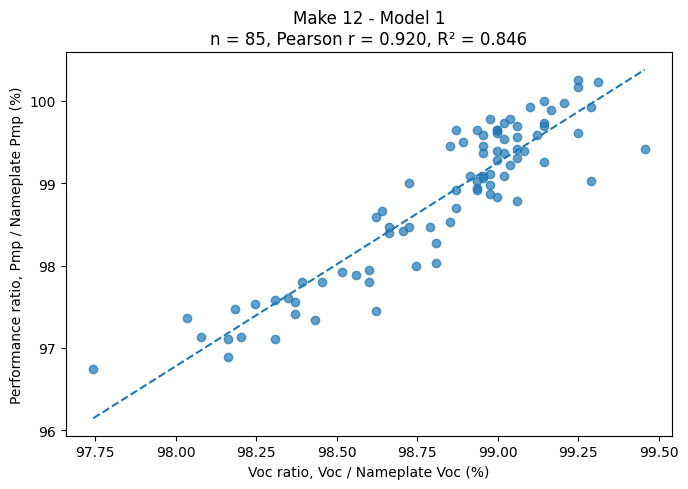

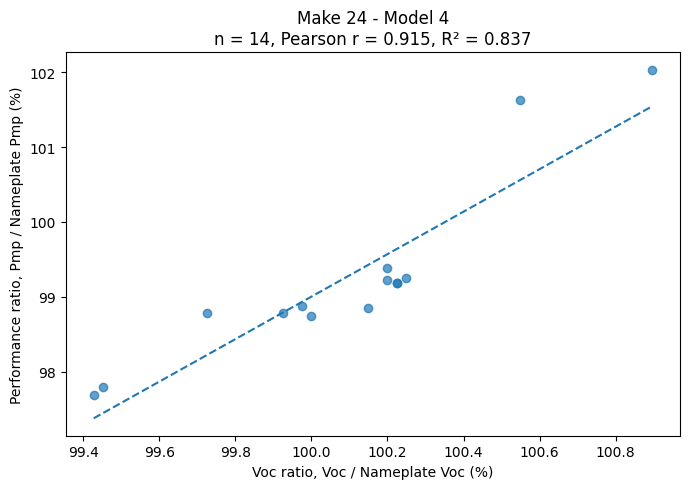


Voc ratio vs performance ratio analysis completed.
Saved in: C:\Users\Ghozy Abror\OneDrive - Institut Teknologi Bandung\Karirku\UNSW\Thesis\Coding\dataset_diversity_plots


In [41]:
# ============================================================
# VOC RATIO vs PERFORMANCE RATIO CORRELATION ANALYSIS
# Run this after the previous full code
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

out_dir = Path("dataset_diversity_plots")
out_dir.mkdir(exist_ok=True)


# ============================================================
# 1. Make sure both ratios exist
# ============================================================

# Voc ratio
if "Voc_Ratio_Percent" not in df.columns:
    df["Voc_(V)"] = pd.to_numeric(df["Voc_(V)"], errors="coerce")
    df["Nameplate_Voc_(V)"] = pd.to_numeric(df["Nameplate_Voc_(V)"], errors="coerce")

    df["Voc_Ratio_Percent"] = np.where(
        df["Nameplate_Voc_(V)"] > 0,
        df["Voc_(V)"] / df["Nameplate_Voc_(V)"] * 100,
        np.nan
    )

# Performance ratio
if "Performance_Factor_Percent" not in df.columns:
    df["Pmp_(W)"] = pd.to_numeric(df["Pmp_(W)"], errors="coerce")
    df["Nameplate_Pmp_(W)"] = pd.to_numeric(df["Nameplate_Pmp_(W)"], errors="coerce")

    df["Performance_Factor_Percent"] = np.where(
        df["Nameplate_Pmp_(W)"] > 0,
        df["Pmp_(W)"] / df["Nameplate_Pmp_(W)"] * 100,
        np.nan
    )


# ============================================================
# 2. Prepare clean data
# ============================================================

corr_df = df[
    [
        "Make_Model",
        "Voc_Ratio_Percent",
        "Performance_Factor_Percent"
    ]
].copy()

corr_df["Voc_Ratio_Percent"] = pd.to_numeric(
    corr_df["Voc_Ratio_Percent"],
    errors="coerce"
)

corr_df["Performance_Factor_Percent"] = pd.to_numeric(
    corr_df["Performance_Factor_Percent"],
    errors="coerce"
)

corr_df = corr_df.replace([np.inf, -np.inf], np.nan)
corr_df = corr_df.dropna(
    subset=[
        "Voc_Ratio_Percent",
        "Performance_Factor_Percent"
    ]
)

print("Valid samples for correlation:", len(corr_df))


# ============================================================
# 3. Overall correlation
# ============================================================

pearson_corr = corr_df["Voc_Ratio_Percent"].corr(
    corr_df["Performance_Factor_Percent"],
    method="pearson"
)

spearman_corr = corr_df["Voc_Ratio_Percent"].corr(
    corr_df["Performance_Factor_Percent"],
    method="spearman"
)

r_squared = pearson_corr ** 2

print("\nOverall correlation:")
print(f"Pearson correlation  : {pearson_corr:.4f}")
print(f"Spearman correlation : {spearman_corr:.4f}")
print(f"R-squared            : {r_squared:.4f}")


# ============================================================
# 4. Scatter plot: Voc ratio vs performance ratio
# ============================================================

x = corr_df["Voc_Ratio_Percent"].values
y = corr_df["Performance_Factor_Percent"].values

# Linear fit
slope, intercept = np.polyfit(x, y, 1)

x_line = np.linspace(x.min(), x.max(), 200)
y_line = slope * x_line + intercept

plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.7)
plt.plot(x_line, y_line, linestyle="--")

plt.xlabel("Voc ratio, Voc / Nameplate Voc (%)")
plt.ylabel("Performance ratio, Pmp / Nameplate Pmp (%)")
plt.title(
    "Voc Ratio vs Performance Ratio\n"
    f"Pearson r = {pearson_corr:.3f}, Spearman r = {spearman_corr:.3f}, R² = {r_squared:.3f}"
)

plt.tight_layout()
plt.savefig(out_dir / "25_voc_ratio_vs_performance_ratio_scatter.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


# ============================================================
# 5. Correlation by Make-Model
# ============================================================

min_samples = 5

records = []

for make_model, group in corr_df.groupby("Make_Model"):
    group = group.dropna(
        subset=[
            "Voc_Ratio_Percent",
            "Performance_Factor_Percent"
        ]
    )

    if len(group) < min_samples:
        continue

    if group["Voc_Ratio_Percent"].nunique() < 2:
        continue

    if group["Performance_Factor_Percent"].nunique() < 2:
        continue

    x_g = group["Voc_Ratio_Percent"].values
    y_g = group["Performance_Factor_Percent"].values

    pearson_g = group["Voc_Ratio_Percent"].corr(
        group["Performance_Factor_Percent"],
        method="pearson"
    )

    spearman_g = group["Voc_Ratio_Percent"].corr(
        group["Performance_Factor_Percent"],
        method="spearman"
    )

    slope_g, intercept_g = np.polyfit(x_g, y_g, 1)

    records.append({
        "Make_Model": make_model,
        "count": len(group),
        "voc_mean": group["Voc_Ratio_Percent"].mean(),
        "voc_median": group["Voc_Ratio_Percent"].median(),
        "voc_min": group["Voc_Ratio_Percent"].min(),
        "voc_max": group["Voc_Ratio_Percent"].max(),
        "voc_std": group["Voc_Ratio_Percent"].std(),
        "performance_mean": group["Performance_Factor_Percent"].mean(),
        "performance_median": group["Performance_Factor_Percent"].median(),
        "performance_min": group["Performance_Factor_Percent"].min(),
        "performance_max": group["Performance_Factor_Percent"].max(),
        "performance_std": group["Performance_Factor_Percent"].std(),
        "pearson_corr": pearson_g,
        "spearman_corr": spearman_g,
        "r_squared": pearson_g ** 2,
        "slope": slope_g,
        "intercept": intercept_g
    })

group_corr_df = pd.DataFrame(records)

if len(group_corr_df) > 0:
    group_corr_df["abs_pearson_corr"] = group_corr_df["pearson_corr"].abs()

    group_corr_df = group_corr_df.sort_values(
        "abs_pearson_corr",
        ascending=False
    )

    group_corr_path = out_dir / "25_voc_ratio_vs_performance_ratio_by_make_model.csv"
    group_corr_df.to_csv(group_corr_path, index=False)

    print("\nCorrelation by Make-Model:")
    display(group_corr_df.round(4))

    print(f"\nGroup correlation table saved to: {group_corr_path}")

else:
    print("No Make-Model group has enough samples for group-level correlation.")


# ============================================================
# 6. Bar chart: strongest correlations by Make-Model
# ============================================================

if len(group_corr_df) > 0:
    top_n = 15

    plot_df = group_corr_df.sort_values(
        "abs_pearson_corr",
        ascending=False
    ).head(top_n)

    plot_df = plot_df.sort_values("pearson_corr", ascending=True)

    labels = [
        f"{row['Make_Model']} (n={int(row['count'])})"
        for _, row in plot_df.iterrows()
    ]

    plt.figure(figsize=(10, 7))
    plt.barh(labels, plot_df["pearson_corr"])

    plt.axvline(0, linewidth=1)
    plt.xlabel("Pearson correlation")
    plt.ylabel("Make-Model")
    plt.title("Strongest Make-Model Correlations: Voc Ratio vs Performance Ratio")

    for i, v in enumerate(plot_df["pearson_corr"]):
        plt.text(v, i, f" {v:.2f}", va="center")

    plt.tight_layout()
    plt.savefig(out_dir / "26_make_model_correlation_voc_vs_performance.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


# ============================================================
# 7. Scatter plot for top correlated Make-Model groups
# ============================================================

if len(group_corr_df) > 0:
    top_groups = group_corr_df.head(6)["Make_Model"].tolist()

    for make_model in top_groups:
        group = corr_df[corr_df["Make_Model"] == make_model].copy()

        x_g = group["Voc_Ratio_Percent"].values
        y_g = group["Performance_Factor_Percent"].values

        if len(group) < min_samples:
            continue

        slope_g, intercept_g = np.polyfit(x_g, y_g, 1)

        x_line_g = np.linspace(x_g.min(), x_g.max(), 100)
        y_line_g = slope_g * x_line_g + intercept_g

        pearson_g = group["Voc_Ratio_Percent"].corr(
            group["Performance_Factor_Percent"],
            method="pearson"
        )

        r2_g = pearson_g ** 2

        safe_name = (
            make_model.replace(" ", "_")
            .replace("-", "")
            .replace("/", "_")
            .replace("\\", "_")
        )

        plt.figure(figsize=(7, 5))
        plt.scatter(x_g, y_g, alpha=0.7)
        plt.plot(x_line_g, y_line_g, linestyle="--")

        plt.xlabel("Voc ratio, Voc / Nameplate Voc (%)")
        plt.ylabel("Performance ratio, Pmp / Nameplate Pmp (%)")
        plt.title(
            f"{make_model}\n"
            f"n = {len(group)}, Pearson r = {pearson_g:.3f}, R² = {r2_g:.3f}"
        )

        plt.tight_layout()
        plt.savefig(
            out_dir / f"27_scatter_voc_vs_performance_{safe_name}.png",
            dpi=300,
            bbox_inches="tight"
        )
        plt.show()
        plt.close()


print("\nVoc ratio vs performance ratio analysis completed.")
print(f"Saved in: {out_dir.resolve()}")

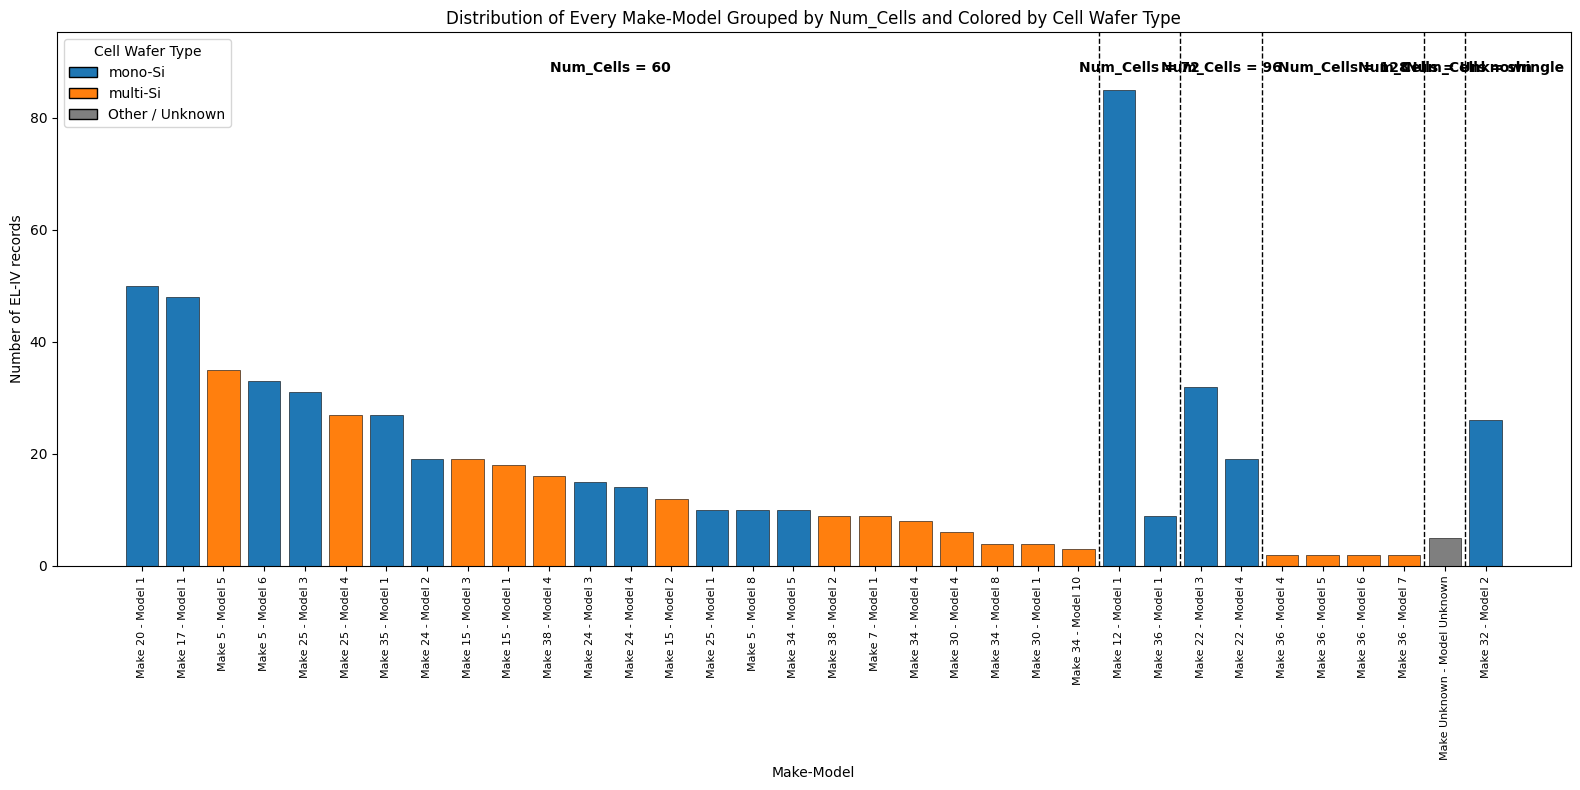

Saved to: dataset_diversity_plots\all_make_model_grouped_by_num_cells_wafer_type.png


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path

# ============================================================
# 1. Basic preparation
# ============================================================

out_dir = Path("dataset_diversity_plots")
out_dir.mkdir(exist_ok=True)

# Clean columns
df.columns = df.columns.astype(str).str.strip()

# ---------- helper functions ----------
def clean_label(series, prefix):
    def format_value(x):
        if pd.isna(x):
            return f"{prefix}Unknown"
        s = str(x).strip()
        if s == "" or s.lower() in ["nan", "none", "<na>"]:
            return f"{prefix}Unknown"
        try:
            val = float(s)
            if val.is_integer():
                return f"{prefix}{int(val)}"
            else:
                return f"{prefix}{val:g}"
        except:
            return f"{prefix}{s}"
    return series.apply(format_value)

def normalize_wafer_type(x):
    if pd.isna(x):
        return "Unknown"
    s = str(x).strip().lower()
    if "mono" in s:
        return "mono-Si"
    elif "multi" in s:
        return "multi-Si"
    else:
        return "Other / Unknown"

# ============================================================
# 2. Make Make_Model and Num_Cells_Label if not already made
# ============================================================

if "Make_Model" not in df.columns:
    df["Make_Label"] = clean_label(df["Make"], "Make ")
    df["Model_Label"] = clean_label(df["Model"], "Model ")
    df["Make_Model"] = df["Make_Label"] + " - " + df["Model_Label"]

if "Num_Cells_Label" not in df.columns:
    raw_num_cells = df["Num_Cells"].astype("string").str.strip()
    num_cells_numeric = pd.to_numeric(raw_num_cells, errors="coerce")
    df["Num_Cells_Label"] = raw_num_cells.fillna("Unknown")

    numeric_mask = num_cells_numeric.notna()
    df.loc[numeric_mask, "Num_Cells_Label"] = (
        num_cells_numeric[numeric_mask].astype("Int64").astype(str)
    )

    df["Num_Cells_Label"] = df["Num_Cells_Label"].replace({
        "": "Unknown",
        "<NA>": "Unknown",
        "nan": "Unknown",
        "None": "Unknown"
    })

# Normalize wafer type
df["Wafer_Type_Simple"] = df["Cell_Wafer_Type"].apply(normalize_wafer_type)

# ============================================================
# 3. Build summary table
# ============================================================
# Count each Make_Model inside each Num_Cells group
count_table = (
    df.groupby(["Num_Cells_Label", "Make_Model"])
      .size()
      .reset_index(name="Count")
)

# Determine dominant wafer type for each Make_Model
wafer_table = (
    df.groupby(["Make_Model", "Wafer_Type_Simple"])
      .size()
      .reset_index(name="n")
      .sort_values(["Make_Model", "n"], ascending=[True, False])
      .drop_duplicates("Make_Model")
      [["Make_Model", "Wafer_Type_Simple"]]
)

plot_df = count_table.merge(wafer_table, on="Make_Model", how="left")

# ============================================================
# 4. Sort Num_Cells groups
#    Numeric groups first, then text groups like shingle
# ============================================================

def numcell_sort_key(x):
    try:
        return (0, int(x))
    except:
        return (1, str(x))

num_cells_order = sorted(plot_df["Num_Cells_Label"].unique(), key=numcell_sort_key)

# Within each Num_Cells group, sort by count descending
ordered_rows = []
group_boundaries = []
group_centers = []

x_pos = 0

for nc in num_cells_order:
    group_data = plot_df[plot_df["Num_Cells_Label"] == nc].copy()
    group_data = group_data.sort_values("Count", ascending=False)

    start_x = x_pos
    for _, row in group_data.iterrows():
        ordered_rows.append({
            "x": x_pos,
            "Num_Cells_Label": row["Num_Cells_Label"],
            "Make_Model": row["Make_Model"],
            "Count": row["Count"],
            "Wafer_Type_Simple": row["Wafer_Type_Simple"]
        })
        x_pos += 1
    end_x = x_pos - 1

    if len(group_data) > 0:
        group_centers.append(((start_x + end_x) / 2, nc))
        group_boundaries.append(x_pos - 0.5)

plot_ordered = pd.DataFrame(ordered_rows)

# ============================================================
# 5. Color mapping
# ============================================================

color_map = {
    "mono-Si": "#1f77b4",          # blue
    "multi-Si": "#ff7f0e",         # orange
    "Other / Unknown": "#7f7f7f"   # grey
}

bar_colors = plot_ordered["Wafer_Type_Simple"].map(color_map).fillna("#7f7f7f")

# ============================================================
# 6. Plot
# ============================================================

fig_width = max(16, len(plot_ordered) * 0.28)
plt.figure(figsize=(fig_width, 8))

plt.bar(
    plot_ordered["x"],
    plot_ordered["Count"],
    color=bar_colors,
    edgecolor="black",
    linewidth=0.4
)

# X tick labels = every Make_Model
plt.xticks(
    plot_ordered["x"],
    plot_ordered["Make_Model"],
    rotation=90,
    fontsize=8
)

plt.ylabel("Number of EL-IV records")
plt.xlabel("Make-Model")
plt.title("Distribution of Every Make-Model Grouped by Num_Cells and Colored by Cell Wafer Type")

# Dashed separators between Num_Cells groups
for boundary in group_boundaries[:-1]:  # skip last outer boundary
    plt.axvline(boundary, color="black", linestyle="--", linewidth=1)

# Add Num_Cells labels above each group
ymax = plot_ordered["Count"].max()
for center, nc in group_centers:
    plt.text(
        center,
        ymax * 1.03,
        f"Num_Cells = {nc}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Legend
legend_elements = [
    Patch(facecolor=color_map["mono-Si"], edgecolor="black", label="mono-Si"),
    Patch(facecolor=color_map["multi-Si"], edgecolor="black", label="multi-Si"),
    Patch(facecolor=color_map["Other / Unknown"], edgecolor="black", label="Other / Unknown")
]

plt.legend(handles=legend_elements, title="Cell Wafer Type")

plt.ylim(0, ymax * 1.12)
plt.tight_layout()
plt.savefig(out_dir / "all_make_model_grouped_by_num_cells_wafer_type.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved to:", out_dir / "all_make_model_grouped_by_num_cells_wafer_type.png")

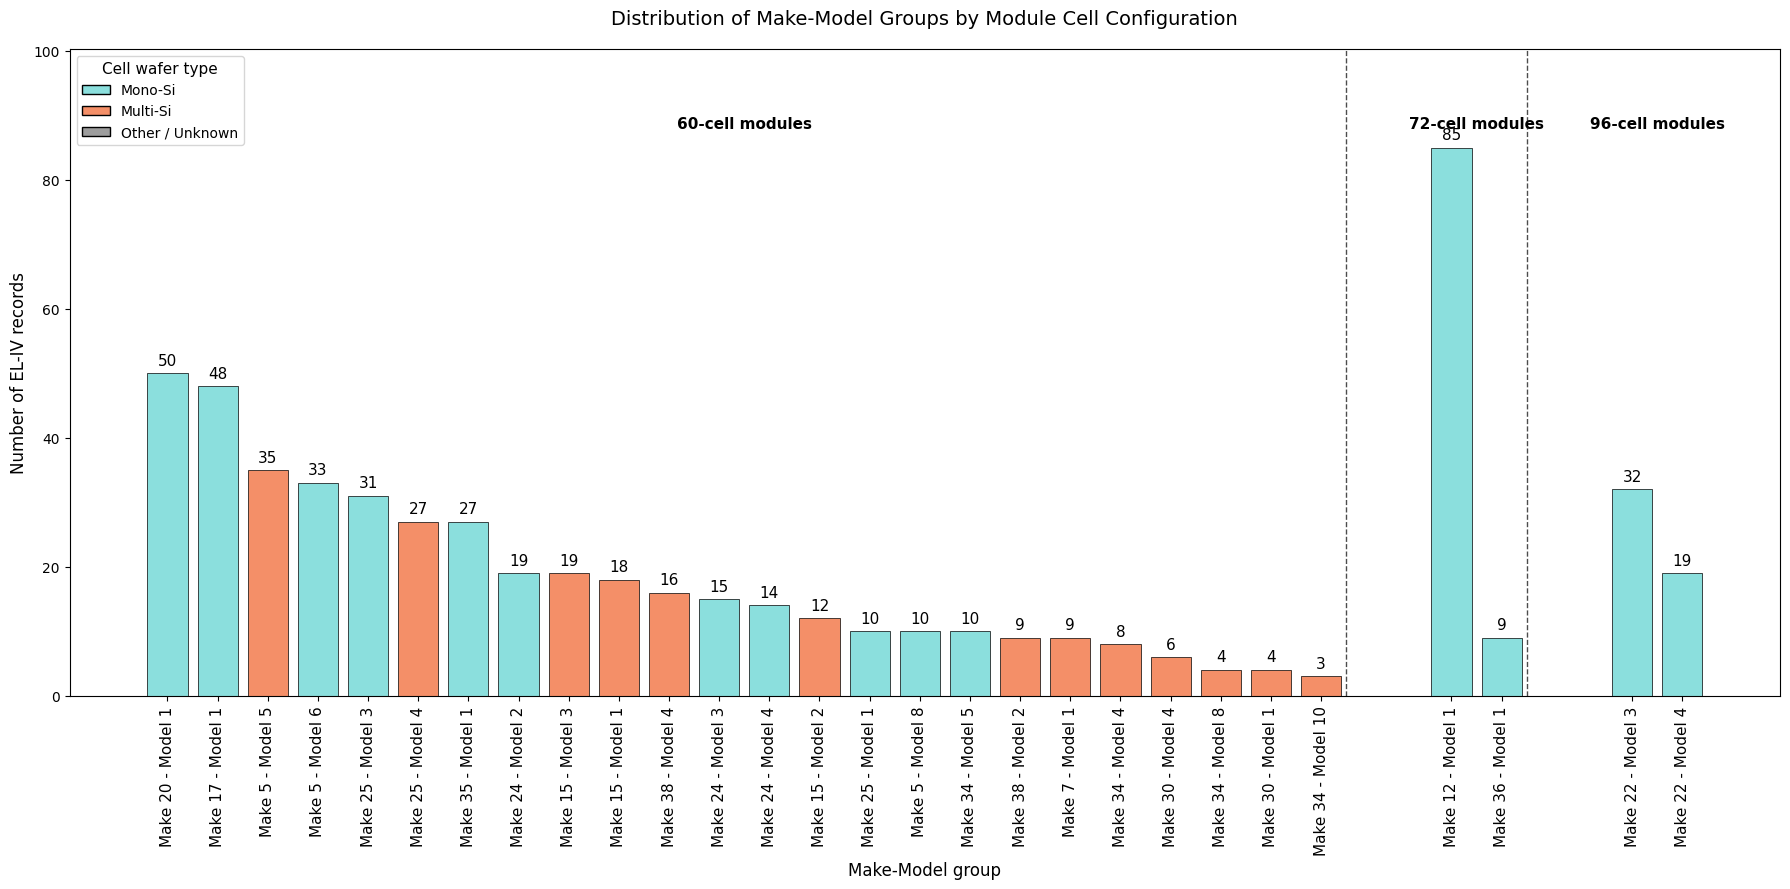

Saved to: dataset_diversity_plots\all_make_model_grouped_by_num_cells_wafer_type_improved.png


In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path

# ============================================================
# 1. Menyarink
# ============================================================

df.columns = df.columns.astype(str).str.strip()

# Create filtered df: remove shingle, unknown/missing, and 128-cell modules
num_cells_raw = df["Num_Cells"].astype("string").str.strip().str.lower()
num_cells_numeric = pd.to_numeric(num_cells_raw, errors="coerce")

df_filtered = df[
    ~(
        num_cells_raw.str.contains("shingle", na=False) |
        num_cells_raw.isna() |
        num_cells_raw.isin(["", "unknown", "nan", "none", "<na>"]) |
        (num_cells_numeric == 128)
    )
].copy()

df = df_filtered

# ============================================================
# 1. Output folder
# ============================================================

out_dir = Path("dataset_diversity_plots")
out_dir.mkdir(exist_ok=True)

# ============================================================
# 2. Helper functions
# ============================================================

def clean_label(series, prefix):
    def format_value(x):
        if pd.isna(x):
            return f"{prefix}Unknown"
        s = str(x).strip()
        if s == "" or s.lower() in ["nan", "none", "<na>"]:
            return f"{prefix}Unknown"
        try:
            val = float(s)
            if val.is_integer():
                return f"{prefix}{int(val)}"
            else:
                return f"{prefix}{val:g}"
        except:
            return f"{prefix}{s}"
    return series.apply(format_value)


def normalize_wafer_type(x):
    if pd.isna(x):
        return "Unknown"
    s = str(x).strip().lower()
    if "mono" in s:
        return "mono-Si"
    elif "multi" in s:
        return "multi-Si"
    else:
        return "Other / Unknown"


def nice_num_cells_label(x):
    """
    Make the group labels more human-friendly.
    """
    s = str(x).strip().lower()

    try:
        n = int(float(s))
        return f"{n}-cell modules"
    except:
        if "shingle" in s:
            return "Shingle modules"
        elif "unknown" in s:
            return "Unknown cell-count group"
        else:
            return f"{x} modules"


# ============================================================
# 3. Prepare key columns
# ============================================================

df.columns = df.columns.astype(str).str.strip()

if "Make_Model" not in df.columns:
    df["Make_Label"] = clean_label(df["Make"], "Make ")
    df["Model_Label"] = clean_label(df["Model"], "Model ")
    df["Make_Model"] = df["Make_Label"] + " - " + df["Model_Label"]

if "Num_Cells_Label" not in df.columns:
    raw_num_cells = df["Num_Cells"].astype("string").str.strip()
    num_cells_numeric = pd.to_numeric(raw_num_cells, errors="coerce")

    df["Num_Cells_Label"] = raw_num_cells.fillna("Unknown")
    numeric_mask = num_cells_numeric.notna()
    df.loc[numeric_mask, "Num_Cells_Label"] = (
        num_cells_numeric[numeric_mask].astype("Int64").astype(str)
    )

    df["Num_Cells_Label"] = df["Num_Cells_Label"].replace({
        "": "Unknown",
        "<NA>": "Unknown",
        "nan": "Unknown",
        "None": "Unknown"
    })

df["Wafer_Type_Simple"] = df["Cell_Wafer_Type"].apply(normalize_wafer_type)

# ============================================================
# 4. Build summary table
# ============================================================

count_table = (
    df.groupby(["Num_Cells_Label", "Make_Model"])
      .size()
      .reset_index(name="Count")
)

wafer_table = (
    df.groupby(["Make_Model", "Wafer_Type_Simple"])
      .size()
      .reset_index(name="n")
      .sort_values(["Make_Model", "n"], ascending=[True, False])
      .drop_duplicates("Make_Model")
      [["Make_Model", "Wafer_Type_Simple"]]
)

plot_df = count_table.merge(wafer_table, on="Make_Model", how="left")

# ============================================================
# 5. Sort Num_Cells groups
# ============================================================

def numcell_sort_key(x):
    try:
        return (0, int(float(x)))
    except:
        return (1, str(x))

num_cells_order = sorted(plot_df["Num_Cells_Label"].unique(), key=numcell_sort_key)

# ============================================================
# 6. Build bar positions with wider group spacing
# ============================================================

ordered_rows = []
group_centers = []
separator_positions = []

x_pos = 0
group_gap = 1.6   # increase spacing between groups

for nc in num_cells_order:
    group_data = plot_df[plot_df["Num_Cells_Label"] == nc].copy()
    group_data = group_data.sort_values("Count", ascending=False)

    if len(group_data) == 0:
        continue

    start_x = x_pos

    for _, row in group_data.iterrows():
        ordered_rows.append({
            "x": x_pos,
            "Num_Cells_Label": row["Num_Cells_Label"],
            "Group_Label": nice_num_cells_label(row["Num_Cells_Label"]),
            "Make_Model": row["Make_Model"],
            "Count": row["Count"],
            "Wafer_Type_Simple": row["Wafer_Type_Simple"]
        })
        x_pos += 1

    end_x = x_pos - 1
    center_x = (start_x + end_x) / 2
    group_centers.append((center_x, nice_num_cells_label(nc)))

    separator_positions.append(x_pos - 0.5)

    # add gap before next group
    x_pos += group_gap

plot_ordered = pd.DataFrame(ordered_rows)

# ============================================================
# 7. Better color palette
# ============================================================

# Softer, clearer, more publication-friendly palette
color_map = {
    "mono-Si": "#8BDFDD",          # muted blue
    "multi-Si": "#F48F68",         # warm orange
    "Other / Unknown": "#9D9D9D"   # soft gray
}

bar_colors = plot_ordered["Wafer_Type_Simple"].map(color_map).fillna("#9D9D9D")

# ============================================================
# 8. Plot
# ============================================================

fig_width = max(18, len(plot_ordered) * 0.35)
fig_height = 9

plt.figure(figsize=(fig_width, fig_height))

bars = plt.bar(
    plot_ordered["x"],
    plot_ordered["Count"],
    color=bar_colors,
    edgecolor="black",
    linewidth=0.5
)

# X-axis labels
plt.xticks(
    plot_ordered["x"],
    plot_ordered["Make_Model"],
    rotation=90,
    fontsize=11
)

plt.ylabel("Number of EL-IV records", fontsize=12)
plt.xlabel("Make-Model group", fontsize=12)
plt.title(
    "Distribution of Make-Model Groups by Module Cell Configuration",
    fontsize=14,
    pad=18
)

# ============================================================
# 9. Add dashed separators
# ============================================================

for sep in separator_positions[:-1]:
    plt.axvline(sep, color="black", linestyle="--", linewidth=1, alpha=0.7)

# ============================================================
# 10. Add group labels on top
# ============================================================

ymax = plot_ordered["Count"].max()
plt.ylim(0, ymax * 1.18)

for center, label in group_centers:
    plt.text(
        center,
        ymax * 1.03,
        label,
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# ============================================================
# 11. Add value labels above bars
# ============================================================

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + ymax * 0.01,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=11
    )

# ============================================================
# 12. Legend
# ============================================================

legend_elements = [
    Patch(facecolor=color_map["mono-Si"], edgecolor="black", label="Mono-Si"),
    Patch(facecolor=color_map["multi-Si"], edgecolor="black", label="Multi-Si"),
    Patch(facecolor=color_map["Other / Unknown"], edgecolor="black", label="Other / Unknown")
]

plt.legend(
    handles=legend_elements,
    title="Cell wafer type",
    loc="upper left",
    fontsize=10,
    title_fontsize=11
)

plt.tight_layout()
save_path = out_dir / "all_make_model_grouped_by_num_cells_wafer_type_improved.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved to:", save_path)

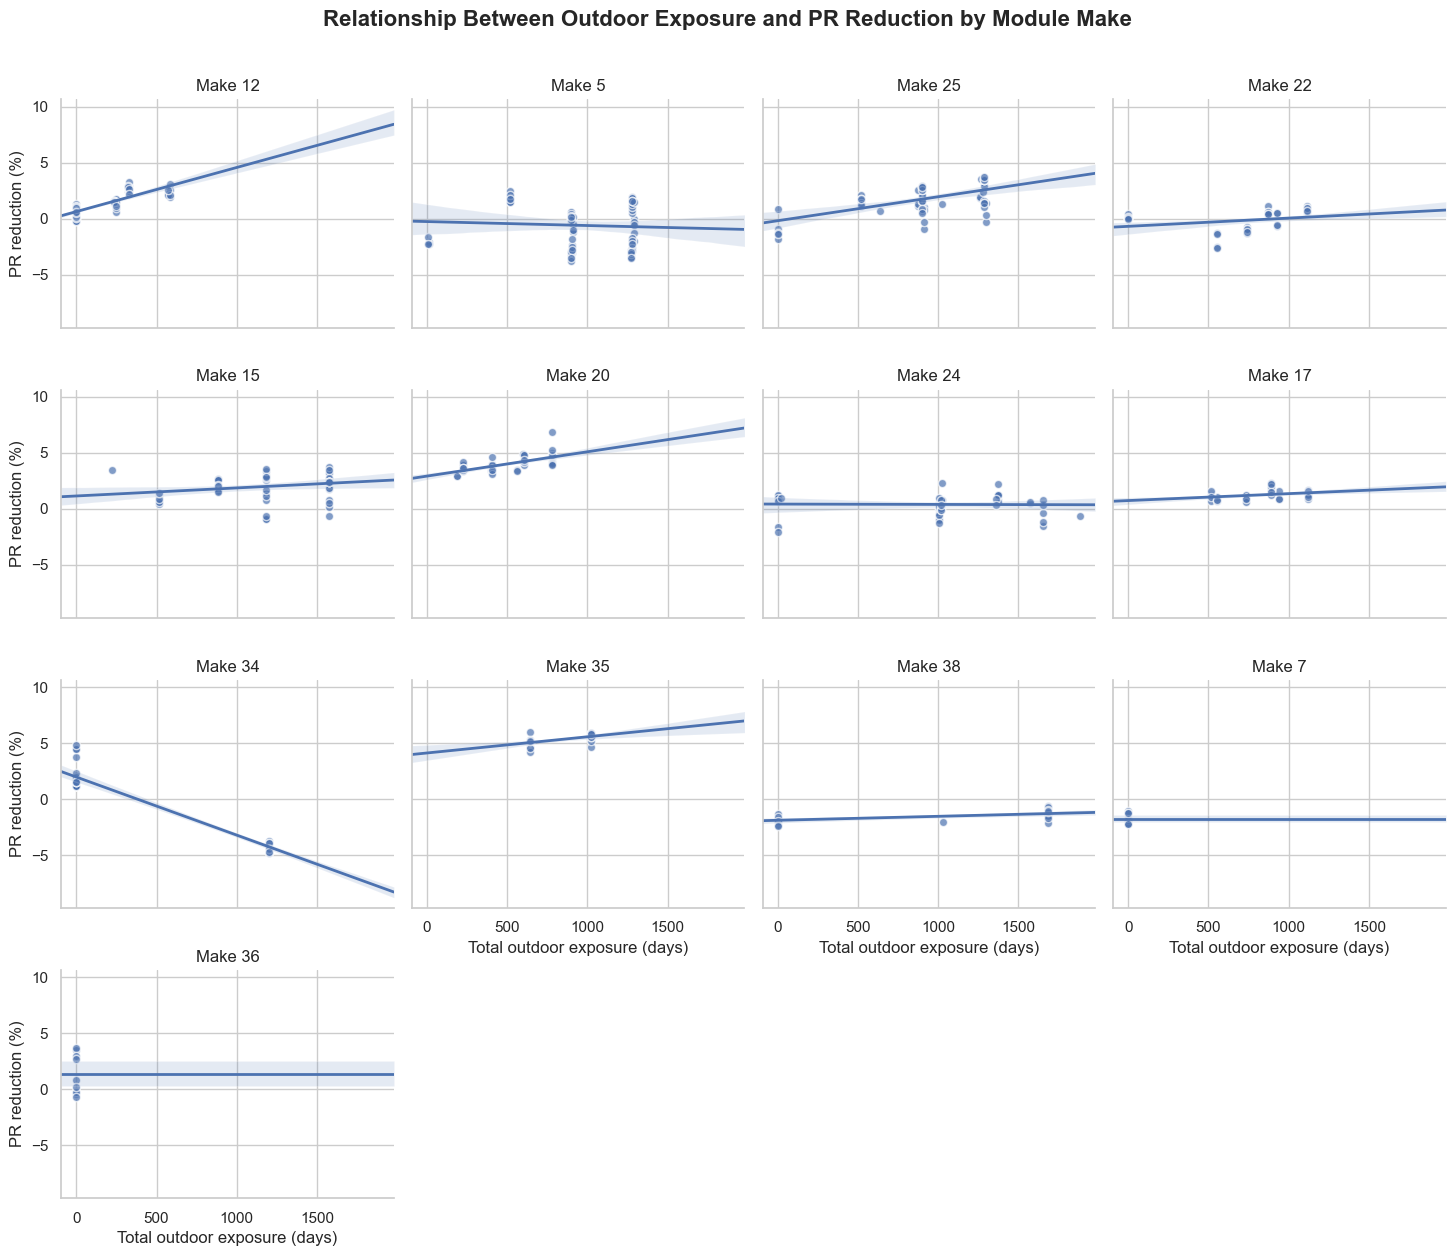

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# 1. Prepare data
# ============================================================

df_plot = df_final.copy()
df_plot.columns = df_plot.columns.astype(str).str.strip()

# Select the correct exposure column
exposure_col = "Total_Exposure_days"

# Convert necessary columns to numeric
df_plot[exposure_col] = pd.to_numeric(
    df_plot[exposure_col],
    errors="coerce"
)

df_plot["PR"] = pd.to_numeric(
    df_plot["PR"],
    errors="coerce"
)

# ============================================================
# 2. Filter Num_Cells
#    Remove shingle, unknown, missing, and 128-cell modules
# ============================================================

num_cells_raw = (
    df_plot["Num_Cells"]
    .astype("string")
    .str.strip()
    .str.lower()
)

num_cells_numeric = pd.to_numeric(
    num_cells_raw,
    errors="coerce"
)

valid_cells = (
    num_cells_numeric.notna() &
    (num_cells_numeric != 128)
)

df_plot = df_plot.loc[valid_cells].copy()

# ============================================================
# 3. Clean Make labels
# ============================================================

def clean_make(x):
    if pd.isna(x):
        return "Unknown"

    try:
        value = float(x)

        if value.is_integer():
            return f"Make {int(value)}"

        return f"Make {value:g}"

    except (ValueError, TypeError):
        return f"Make {str(x).strip()}"

df_plot["Make_Label"] = df_plot["Make"].apply(clean_make)

# Remove unknown makes
df_plot = df_plot[
    ~df_plot["Make_Label"].str.contains(
        "unknown|nan|none",
        case=False,
        na=False
    )
].copy()

# ============================================================
# 4. Calculate PR reduction
# ============================================================

# Check whether PR is stored as:
# 0.98 or 98
if df_plot["PR"].median() <= 2:
    df_plot["PR_Percent"] = df_plot["PR"] * 100
else:
    df_plot["PR_Percent"] = df_plot["PR"]

df_plot["PR_Reduction_Percent"] = 100 - df_plot["PR_Percent"]

# Remove invalid values
df_plot = df_plot.replace([np.inf, -np.inf], np.nan)

df_plot = df_plot.dropna(
    subset=[
        exposure_col,
        "PR_Reduction_Percent",
        "Make_Label"
    ]
)

# Optional reasonable limits
df_plot = df_plot[
    (df_plot[exposure_col] >= 0) &
    (df_plot["PR_Reduction_Percent"].between(-10, 20))
].copy()

# ============================================================
# 5. Order Make panels by sample count
# ============================================================

make_order = (
    df_plot["Make_Label"]
    .value_counts()
    .index
    .tolist()
)

df_plot["Make_Label"] = pd.Categorical(
    df_plot["Make_Label"],
    categories=make_order,
    ordered=True
)

# ============================================================
# 6. Faceted scatter plot with regression line
# ============================================================

sns.set_theme(style="whitegrid", context="notebook")

g = sns.lmplot(
    data=df_plot,
    x=exposure_col,
    y="PR_Reduction_Percent",
    col="Make_Label",
    col_wrap=4,
    col_order=make_order,
    height=3.2,
    aspect=1.15,

    scatter_kws={
        "s": 35,
        "alpha": 0.70,
        "edgecolor": "white"
    },

    line_kws={
        "linewidth": 2
    },

    ci=95,
    truncate=False
)

g.set_axis_labels(
    "Total outdoor exposure (days)",
    "PR reduction (%)"
)

g.set_titles("{col_name}")

g.fig.subplots_adjust(top=0.91)

g.fig.suptitle(
    "Relationship Between Outdoor Exposure and PR Reduction by Module Make",
    fontsize=16,
    fontweight="bold"
)

plt.show()

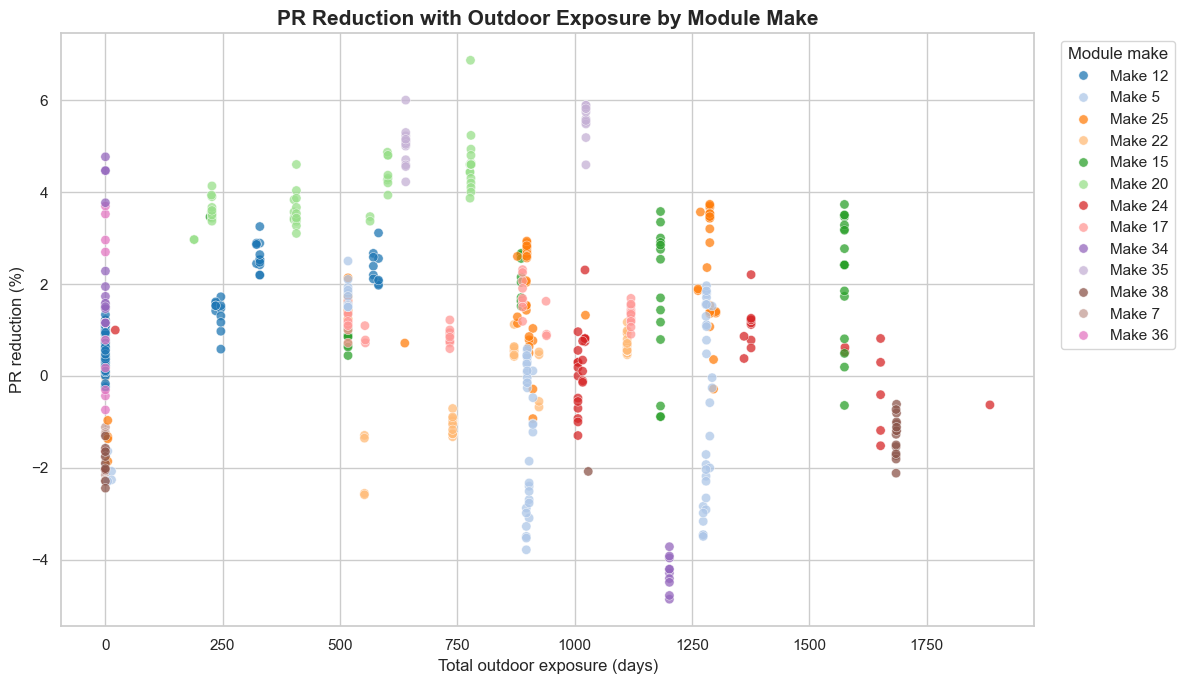

In [17]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df_plot,
    x=exposure_col,
    y="PR_Reduction_Percent",
    hue="Make_Label",
    palette="tab20",
    s=45,
    alpha=0.75,
    edgecolor="white",
    linewidth=0.4
)

plt.xlabel("Total outdoor exposure (days)")
plt.ylabel("PR reduction (%)")
plt.title(
    "PR Reduction with Outdoor Exposure by Module Make",
    fontsize=15,
    fontweight="bold"
)

plt.legend(
    title="Module make",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

,Make_Label,sample_count,mean_depreciation,median_depreciation,std_depreciation,min_depreciation,max_depreciation
3,Make 20,57,3.2901,2.9123,1.4411,1.8176,6.6507
8,Make 35,27,2.4765,2.5999,0.4829,1.6381,3.4242
0,Make 12,42,2.2912,2.4362,0.6921,0.8661,3.6081
1,Make 15,63,0.7275,0.6718,0.7216,-0.2731,5.6696
2,Make 17,48,0.5812,0.5036,0.2093,0.2955,1.1480
5,Make 24,47,0.4896,0.1802,2.5262,-0.4702,17.3542
4,Make 22,55,-0.1566,0.1779,0.4921,-1.7102,0.4702
9,Make 38,16,-0.3081,-0.2667,0.1459,-0.7372,-0.1333
7,Make 34,10,-1.3011,-1.2899,0.1112,-1.4759,-1.1287
6,Make 25,67,-5.2918,0.8435,24.8775,-135.6643,1.5072


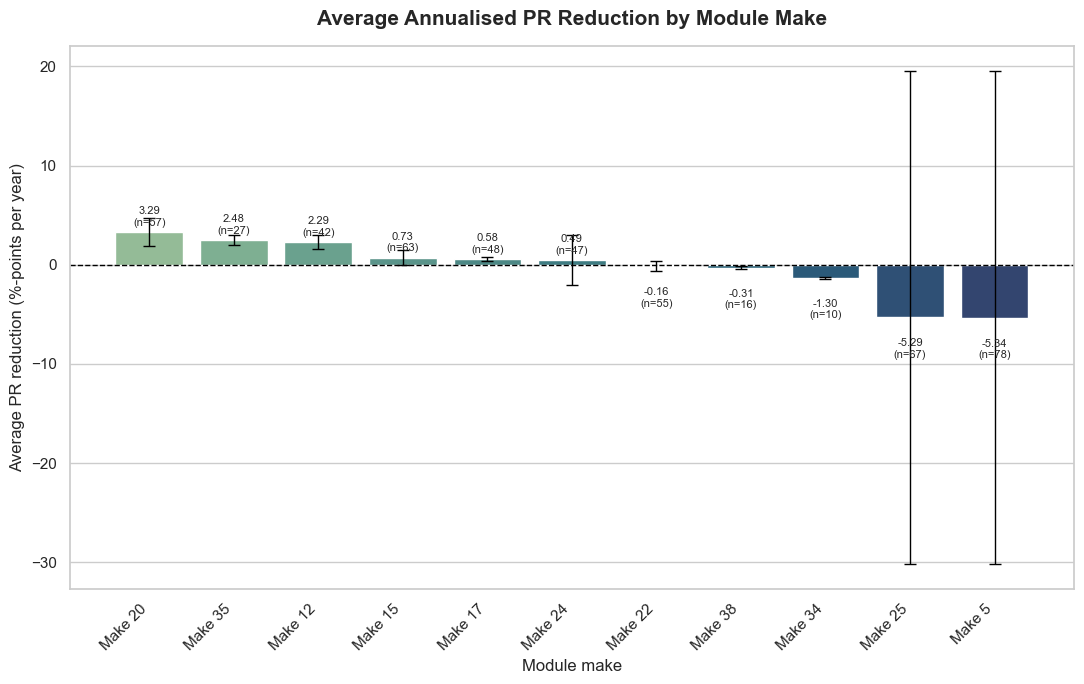

In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# 1. Prepare data
# ============================================================

df_dep = df_final.copy()
df_dep.columns = df_dep.columns.astype(str).str.strip()

exposure_col = "Total_Exposure_days"

# Convert columns to numeric
df_dep[exposure_col] = pd.to_numeric(
    df_dep[exposure_col],
    errors="coerce"
)

df_dep["PR"] = pd.to_numeric(
    df_dep["PR"],
    errors="coerce"
)

# ============================================================
# 2. Remove shingle, unknown, missing and 128-cell modules
# ============================================================

num_cells_raw = (
    df_dep["Num_Cells"]
    .astype("string")
    .str.strip()
    .str.lower()
)

num_cells_numeric = pd.to_numeric(
    num_cells_raw,
    errors="coerce"
)

df_dep = df_dep[
    num_cells_numeric.notna() &
    (num_cells_numeric != 128)
].copy()

# ============================================================
# 3. Clean Make labels
# ============================================================

def clean_make(x):
    if pd.isna(x):
        return "Unknown"

    try:
        value = float(x)

        if value.is_integer():
            return f"Make {int(value)}"

        return f"Make {value:g}"

    except (ValueError, TypeError):
        return f"Make {str(x).strip()}"


df_dep["Make_Label"] = df_dep["Make"].apply(clean_make)

df_dep = df_dep[
    ~df_dep["Make_Label"].str.contains(
        "unknown|nan|none",
        case=False,
        na=False
    )
].copy()

# ============================================================
# 4. Convert PR to percent and calculate reduction
# ============================================================

# Handle PR stored either as 0.98 or 98
if df_dep["PR"].median() <= 2:
    df_dep["PR_Percent"] = df_dep["PR"] * 100
else:
    df_dep["PR_Percent"] = df_dep["PR"]

df_dep["PR_Reduction_Percent"] = (
    100 - df_dep["PR_Percent"]
)

# Exposure must be greater than zero
df_dep = df_dep[
    df_dep[exposure_col] > 0
].copy()

df_dep["PR_Reduction_Per_Day"] = (
    df_dep["PR_Reduction_Percent"] /
    df_dep[exposure_col]
)

# Optional: annualised value, easier to interpret
df_dep["PR_Reduction_Per_Year"] = (
    df_dep["PR_Reduction_Per_Day"] * 365.25
)

df_dep = df_dep.replace([np.inf, -np.inf], np.nan)

df_dep = df_dep.dropna(
    subset=[
        "Make_Label",
        "PR_Reduction_Per_Year"
    ]
)

# ============================================================
# 5. Summary statistics by Make
# ============================================================

make_depreciation = (
    df_dep.groupby("Make_Label")
    .agg(
        sample_count=("PR_Reduction_Per_Year", "count"),
        mean_depreciation=("PR_Reduction_Per_Year", "mean"),
        median_depreciation=("PR_Reduction_Per_Year", "median"),
        std_depreciation=("PR_Reduction_Per_Year", "std"),
        min_depreciation=("PR_Reduction_Per_Year", "min"),
        max_depreciation=("PR_Reduction_Per_Year", "max")
    )
    .reset_index()
)

# Require a minimum number of observations
minimum_samples = 3

make_depreciation = make_depreciation[
    make_depreciation["sample_count"] >= minimum_samples
].copy()

make_depreciation = make_depreciation.sort_values(
    "mean_depreciation",
    ascending=False
)

display(make_depreciation.round(4))

# ============================================================
# 6. Bar chart
# ============================================================

sns.set_theme(style="whitegrid", context="notebook")

palette = sns.color_palette(
    "crest",
    n_colors=len(make_depreciation)
)

plt.figure(
    figsize=(max(11, len(make_depreciation) * 0.55), 7)
)

ax = sns.barplot(
    data=make_depreciation,
    x="Make_Label",
    y="mean_depreciation",
    hue="Make_Label",
    palette=palette,
    legend=False
)

# Error bars: mean ± standard deviation
x_positions = np.arange(len(make_depreciation))

ax.errorbar(
    x=x_positions,
    y=make_depreciation["mean_depreciation"],
    yerr=make_depreciation["std_depreciation"].fillna(0),
    fmt="none",
    ecolor="black",
    capsize=4,
    linewidth=1
)

# Zero reference line
ax.axhline(
    0,
    color="black",
    linewidth=1,
    linestyle="--"
)

# Add mean and sample count above each bar
for bar, (_, row) in zip(ax.patches, make_depreciation.iterrows()):
    height = bar.get_height()

    vertical_offset = 3 if height >= 0 else -15

    ax.annotate(
        f"{height:.2f}\n(n={int(row['sample_count'])})",
        xy=(
            bar.get_x() + bar.get_width() / 2,
            height
        ),
        xytext=(0, vertical_offset),
        textcoords="offset points",
        ha="center",
        va="bottom" if height >= 0 else "top",
        fontsize=8
    )

ax.set_xlabel("Module make")
ax.set_ylabel("Average PR reduction (%-points per year)")
ax.set_title(
    "Average Annualised PR Reduction by Module Make",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()